# DESeq2 with new reference genome
but with pre-filtering! 
# Phase 2 vs. Phase 2

focusing on pairwise comparisons of oysters that experienced both phase 1 and phase 2

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano) # for volcano plots
library(vegan) # for permanova
library(pheatmap)
library(RColorBrewer)
library(limma) # for removing batch effects

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [3]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts.df <- counts %>%
select(-Gene_ID, -Length)

head(counts.df)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [4]:
# number of genes with 0 counts for all samples
sum(rowSums(counts.df) == 0) # 4884 genes

# pre-filter those rows
counts.filtered <- counts.df[!rowSums(counts.df) == 0,]

# double check this worked
dim(counts.df) # 33903 total genes
dim(counts.filtered) # 29019 genes with at least 1 read

[1] 4884

[1] 33903   120

[1] 29019   120

### meta data
the meta data csv was already generated in [deseq_p1.v.p1](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/deseq_p1.v.p1.ipynb), so just reading in here

In [5]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl("Nu", Sample)) # filter out phase 1 samples - only want phase 2

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

head(meta)
dim(meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


[1] 96  8

creating new column for 'complete' treatment - so I can easily compare phase 1 to phase 2

In [6]:
meta$complete_trtmt <- paste(meta$Phase1_treatment, meta$Phase2_treatment)

# check
head(meta,2)
tail(meta,2)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm


,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
W6_W3_G36,warm,warm,normoxic,6,warm,warm,normoxic,3,warm warm
W6_W4_G48,warm,warm,normoxic,6,warm,warm,normoxic,4,warm warm


In [7]:
# setting the same order for counts matrix and meta data
counts.filtered <- counts.filtered[,rownames(meta)]
all(rownames(meta) == colnames(counts.filtered))

[1] TRUE

## 2. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [8]:
# tempature treatments
meta$Phase1_temp <- factor(meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

meta$Phase2_temp <- factor(meta$Phase2_temp,
                                   levels = c('ambient', 'warm'))

In [9]:
# DO treatments
meta$Phase1_DO <- factor(meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

meta$Phase2_DO <- factor(meta$Phase2_DO,
                                   levels = c('normoxic', 'hypoxic'))

### complete treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [10]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = counts.filtered,
                              colData = meta,
                              design = ~ complete_trtmt)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



class: DESeqDataSet 
dim: 29019 96 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

looks like there were 29019 genes pre-filter

for the filter, I want to make sure to filter out rows with just one strong signal from one sample (for example, I sometimes see a DEG but at closer look, it is driven by high expression of one sample) 

to do this, i'm going to only keep genes that have a consistent signal (at least 5 reads) in at least 5 samples in at least one treatment treatment combo 

### pre-filter genes 

In [11]:
# filter genes with inconsistent/low reads 
dds$group <- factor(dds$complete_trtmt)

keep <- apply(counts(dds), # raw counts matrix
              1, # apply across rows - for each row/gene, apply this function: 
              function(x) {
  any(tapply(x, dds$group, # split counts for this gene by treatment combo
             function(g) sum(g >= 10) >= 5)) # does this treatment combo have at least 6 samples with counts of 10 or more?
             # any = is at least one group true?
})
dds_filtered <- dds[keep, ]


In [12]:
dds_filtered

class: DESeqDataSet 
dim: 21663 96 
metadata(1): version
assays(4): counts mu H cooks
rownames(21663): LOC144621260 LOC144621269 ... LOC111112304
  LOC144621888
rowData names(78): baseMean baseVar ... deviance maxCooks
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

21,663 genes after filtering

In [13]:
21663 / 29019
# so maintaining about 74.65% of genes

[1] 0.7465109

Checking how strict this filtering was by looking at the control oysters and see how many genes have reasonable counts (not outliers/no counts) 

In [14]:
baseline_group <- "control control"  # match your actual level naming
baseline_samples <- dds_filtered$group == baseline_group
baseline_ok <- rowSums(counts(dds_filtered)[, baseline_samples] >= 10) >= 6
table(baseline_ok)

baseline_ok
FALSE  TRUE 
 4632 17031 

so only about 15% of the genes don't have reliable counts in the control oysters - but going to move forward with this cutoff

#### run DESeq again

In [15]:
# run DESeq on the filtered dds object
dds_filtered <- DESeq(dds_filtered)

# run vst on new dds object
vst_mat <- assay(vst(dds_filtered, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [16]:
dim(vst_mat)
head(vst_mat)

[1] 21663    96

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.540492,11.329103,11.31358,11.171433,10.877329,10.859527,11.269921,10.944710,11.053841,11.076714,⋯,11.762998,10.509583,10.993926,11.458209,11.317467,11.133643,11.274436,11.117802,11.736038,11.57536
LOC144621269,8.665779,11.053959,11.48073,10.405045,11.520655,10.557007,12.784012,10.950846,8.424073,8.263105,⋯,13.894461,8.188665,8.270518,10.083480,8.594585,8.937148,13.444925,8.401878,9.744383,13.42250
LOC111120925,8.746040,8.454651,9.79921,8.303928,8.398231,8.281751,8.027292,8.118006,8.027292,8.116506,⋯,9.662484,8.027292,8.199380,9.818135,8.797551,8.512048,8.241535,8.121185,8.335188,8.30371
LOC144621283,9.951839,10.382689,10.40627,10.229685,10.324898,10.609903,10.575500,9.810430,10.157050,10.258151,⋯,10.045462,10.525359,10.268448,10.408478,10.378871,10.294028,10.021841,10.891624,10.036314,10.06767
LOC144621276,13.447299,13.490683,13.66381,13.497065,13.775744,13.897521,13.711212,13.213348,13.754103,13.430331,⋯,14.022665,13.303759,13.847565,13.542749,13.090975,13.275820,13.932288,13.369687,13.415675,13.36612
LOC111115920,9.128721,9.198142,9.09695,8.938537,8.858496,8.806063,8.713981,9.678529,8.903779,9.540599,⋯,8.826267,8.919198,9.382810,9.041307,9.707308,9.710238,9.200176,9.362505,8.882269,8.99437


### explore results and fit

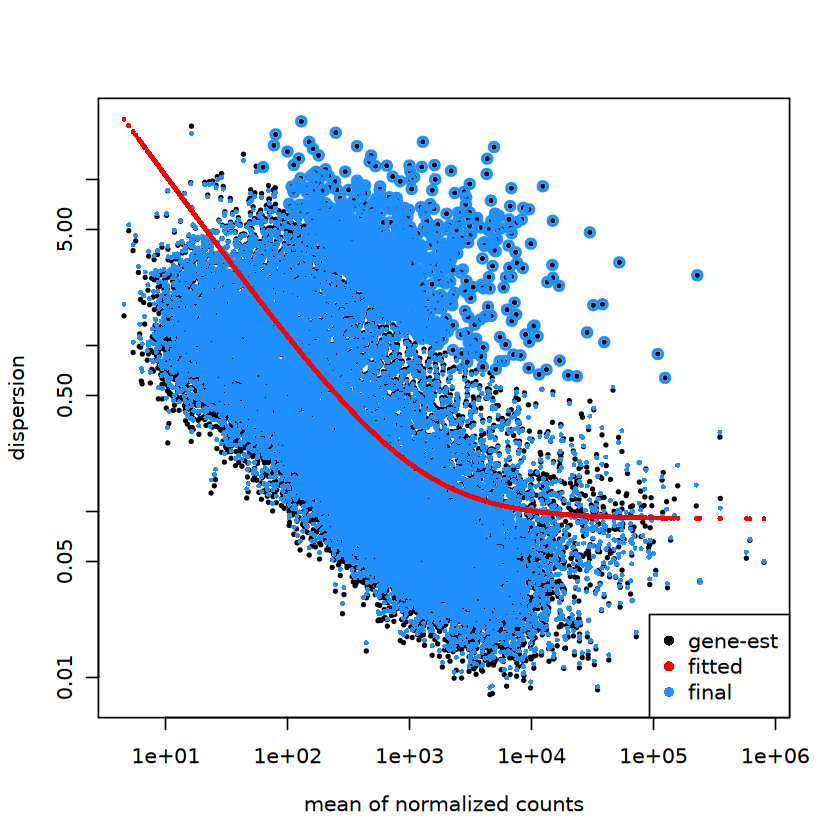

In [17]:
plotDispEsts(dds_filtered)

### nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [18]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,89.42877,90.80696,86.78648,91.74591,90.68817,99.63871,92.27276,91.47294,81.95938,⋯,105.93383,88.39810,77.08972,81.70211,78.41708,82.19212,101.54263,85.59058,83.41630,106.96923
B1_W5_O50,89.42877,0.00000,84.66878,75.10833,70.69194,77.33495,78.27464,90.84176,86.63306,86.37198,⋯,86.99708,95.28588,88.35551,87.96750,90.90699,87.54681,89.88743,89.91356,83.55957,86.30100
B2_B5_O51,90.80696,84.66878,0.00000,93.09084,86.80501,92.38447,88.17140,100.79607,104.23457,100.17703,⋯,92.71898,107.29093,97.68695,83.83068,95.69548,98.27610,93.17671,99.04447,94.08063,88.68665
B2_C4_O40,86.78648,75.10833,93.09084,0.00000,79.20930,77.65117,87.12353,89.07514,91.75679,81.49474,⋯,93.12107,90.52137,86.07959,85.65003,86.22572,84.52016,97.47018,83.76980,67.37247,94.54936
B3_B4_O41,91.74591,70.69194,86.80501,79.20930,0.00000,82.88130,84.61806,96.25981,83.32346,90.47688,⋯,86.03991,99.28959,89.40368,91.92100,95.79536,92.48698,86.59959,93.39167,87.30684,87.36172
B3_C3_O30,90.68817,77.33495,92.38447,77.65117,82.88130,0.00000,89.77154,95.46062,95.70643,90.67556,⋯,96.82051,97.84326,82.90597,92.80104,93.48110,89.67951,100.71186,87.19314,87.26955,99.16765


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,15.010712,11.2504670,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-8.748703,-16.9928759,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-21.572322,-0.4197209,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,3.037642,-11.2589001,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-13.583909,-14.1243494,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,3.074682,-9.8335151,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


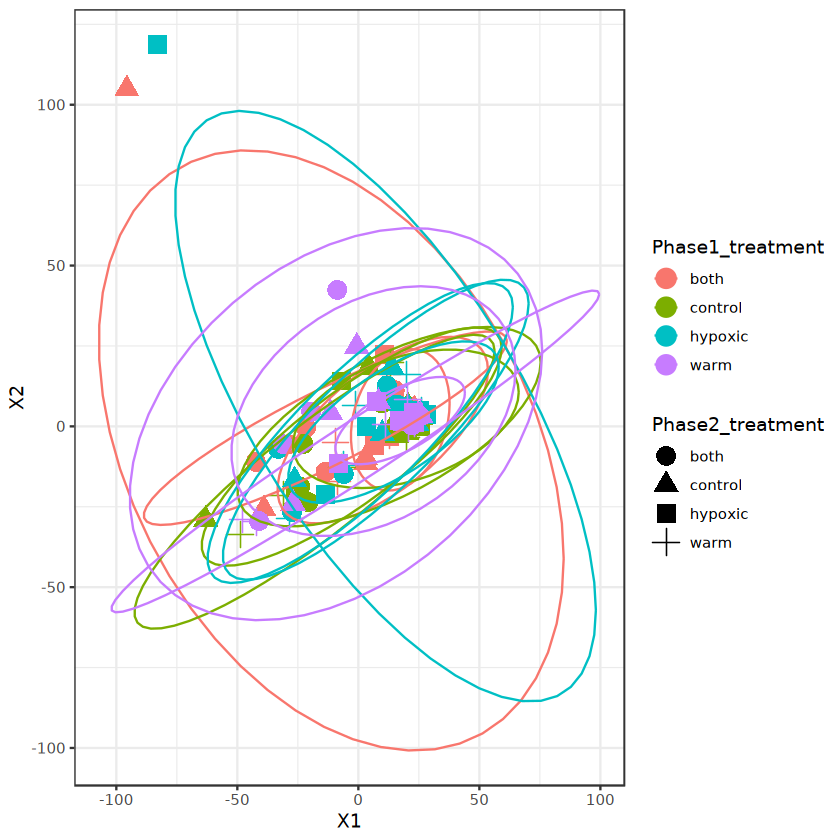

In [19]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

In [20]:
sample_dists <- dist(t(assay(vsd)))  # transpose so samples are rows
head(sample_dists)

meta <- as.data.frame(colData(vsd))
head(meta)

[1] 89.42877 90.80696 86.78648 91.74591 90.68817 99.63871

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [21]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3917.526,0.008715952,0.8340958,0.724
Phase1_DO,1,3881.369,0.008635508,0.8263974,0.772
Phase2_temp,1,10267.452,0.022843658,2.1860834,0.004
Phase2_DO,1,6967.083,0.015500793,1.4833888,0.053
Phase1_temp:Phase1_DO,1,3230.715,0.007187893,0.6878641,0.966
Phase1_temp:Phase2_temp,1,3242.430,0.007213958,0.6903585,0.960
Phase1_DO:Phase2_temp,1,4233.462,0.009418867,0.9013630,0.597
Phase1_temp:Phase2_DO,1,3609.751,0.008031196,0.7685662,0.878
Phase1_DO:Phase2_DO,1,4304.212,0.009576275,0.9164265,0.561


- Phase2_temp has a significant effect on GE (P = 0.004) and explains ~2.2% of the variation in GE
- Phase2_DO also has a significant effect on GE (P = 0.040) and explains ~1.5% of the variance
- The interaction of Phase2_temp and Phase2_DO is significant (P = 0.050) and explains ~1.5% of the variation in GE
    - this means the effect of phase 2 temp depends on the value of phase 2 DO (or vice versa)
- The majoirty of the variation in GE is not explained by the treatments (R2 = 0.84)

### heatmap of sample-to-sample distances using the variance stabilizing transformed values
following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [22]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- dist(t(assay(dds_filtered)))
head(sample_dists)

[1]  556919.4  657148.6  524002.4  550078.1  501121.4 1120029.3

In [23]:
head(vsd)

class: DESeqTransform 
dim: 6 96 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

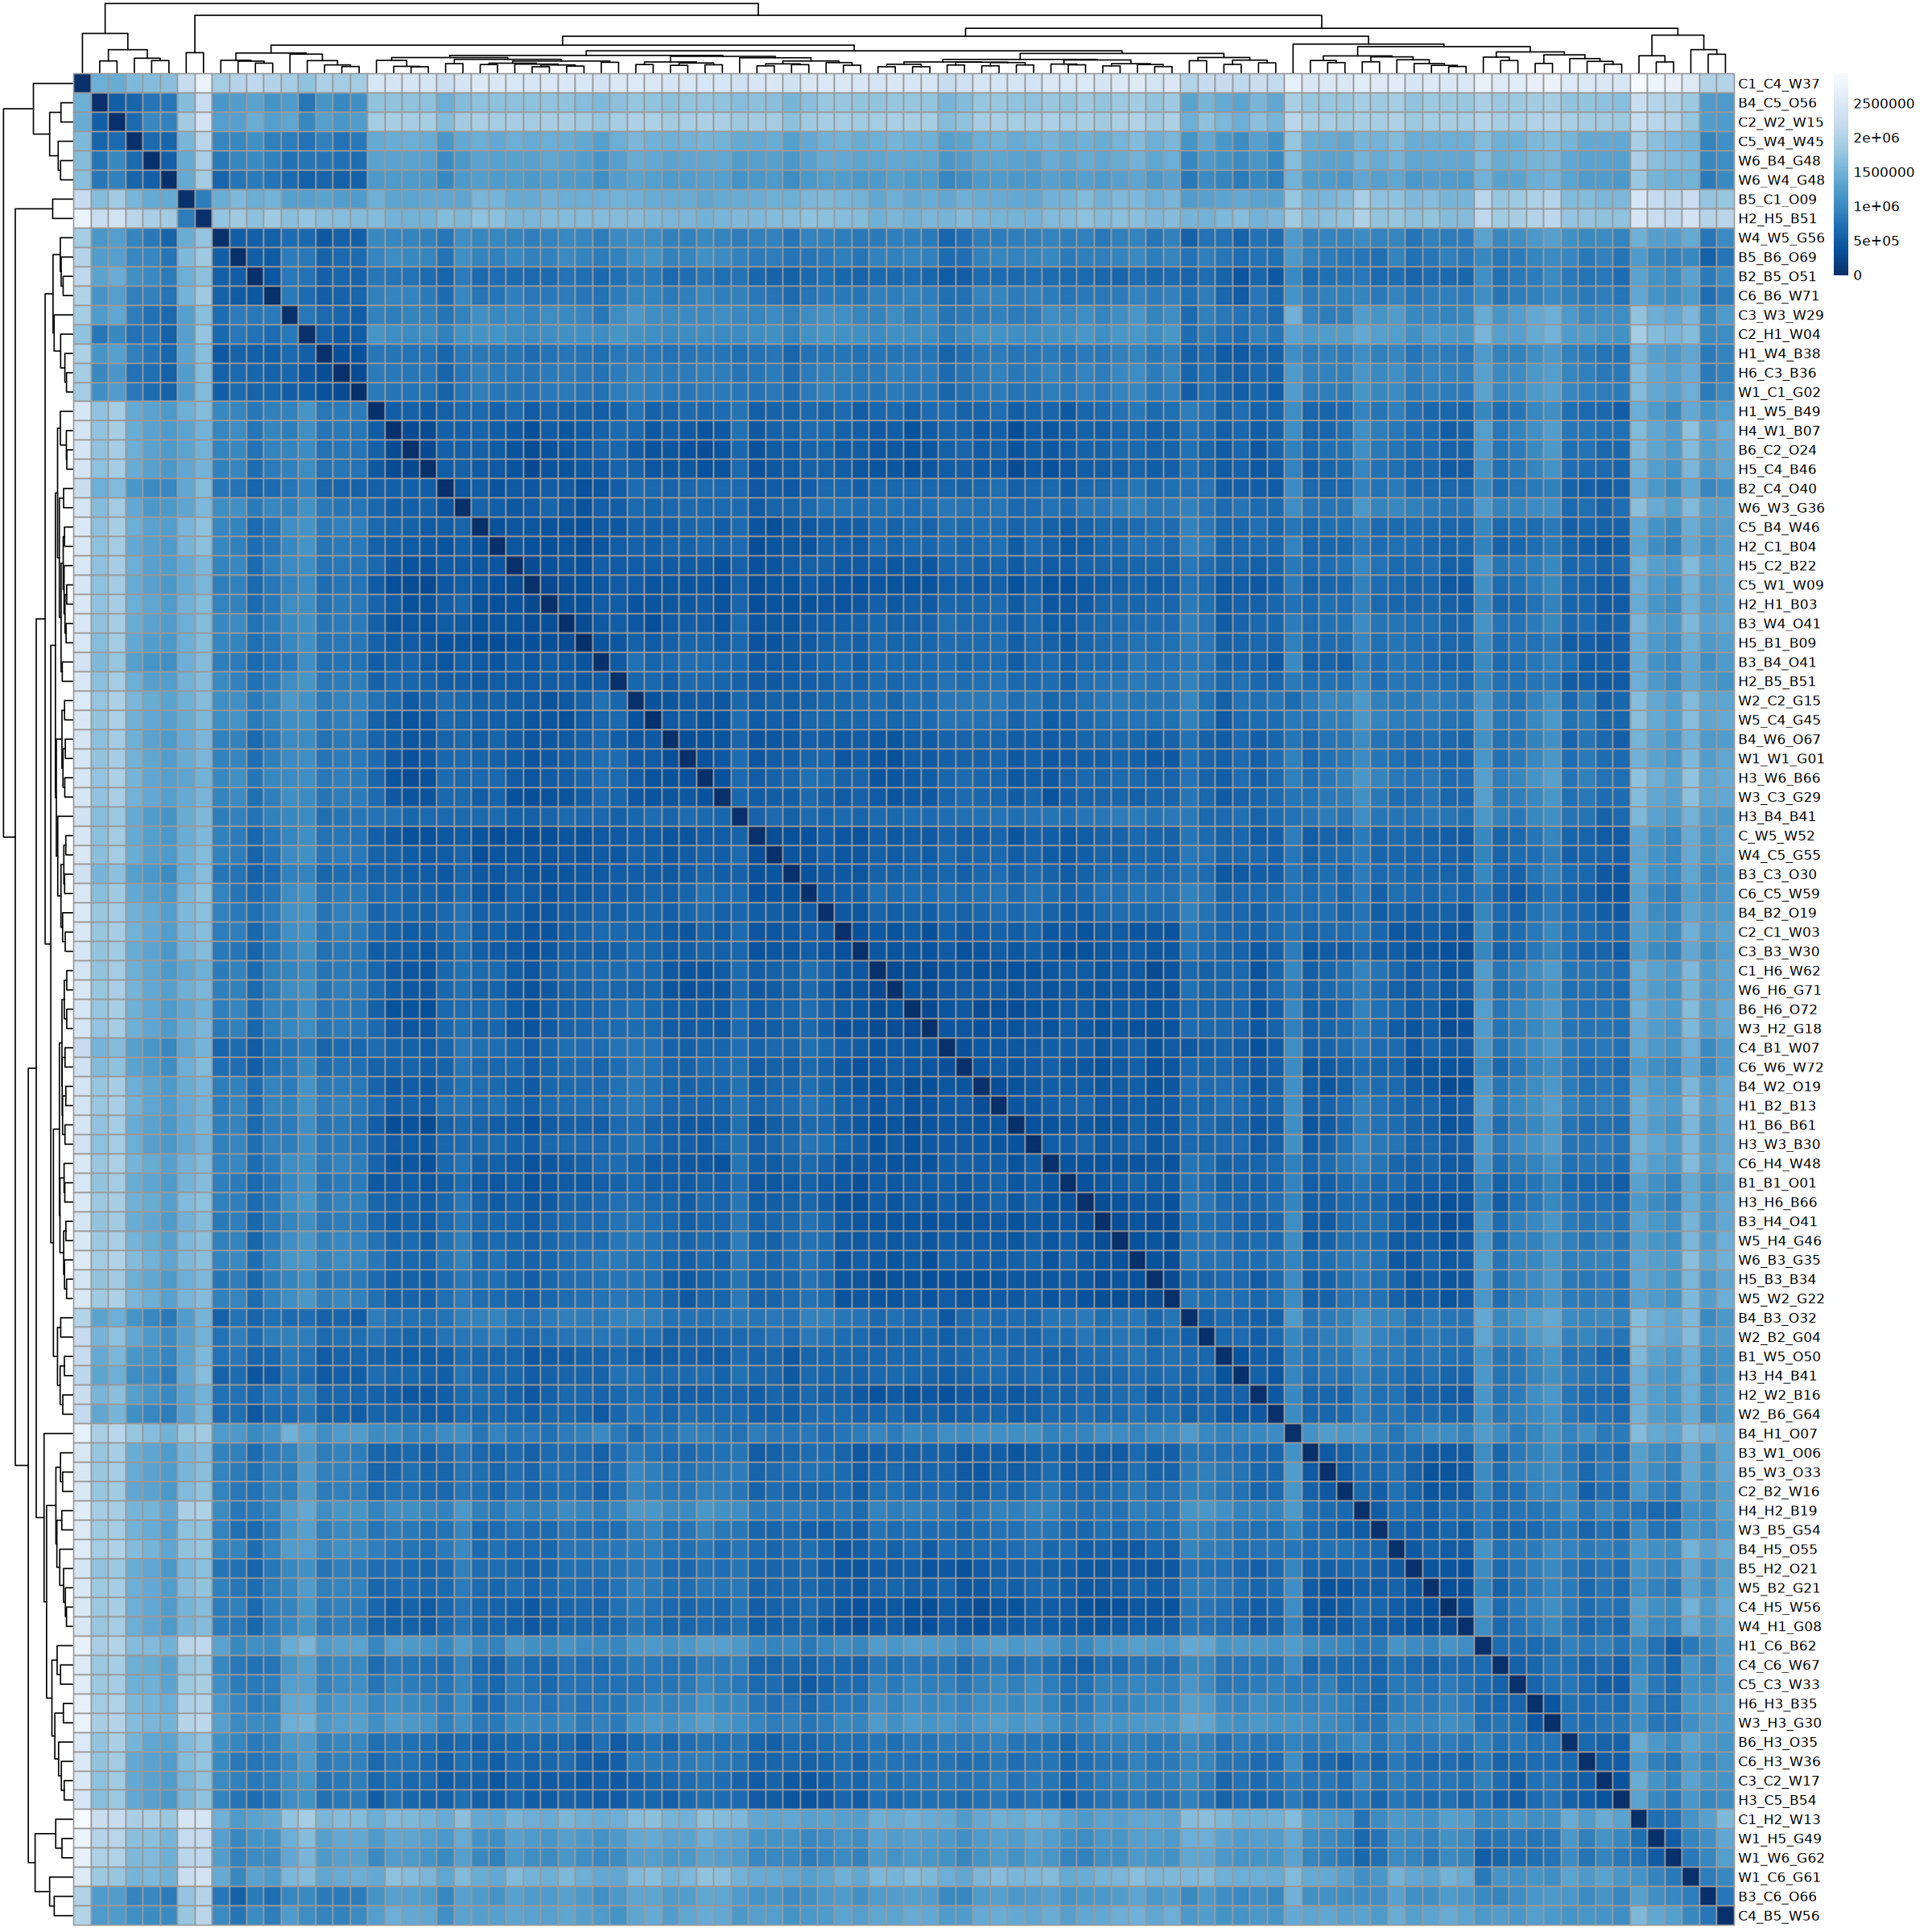

In [24]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

it's weird that there's two samples that are very dissimilar to every other sample, but appear closer together - (HH and BC) - if you look at the nMDS plots too, they look like outliers from their replicates so should consider removing those samples from analysis 

In [25]:
pcaData <- plotPCA(vsd, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-14.396131,6.258492,both:both,both,both,B1_B1_O01
B1_W5_O50,13.032466,-9.826466,both:warm,both,warm,B1_W5_O50
B2_B5_O51,18.056098,7.429512,both:both,both,both,B2_B5_O51
B2_C4_O40,3.186457,-6.755655,both:control,both,control,B2_C4_O40
B3_B4_O41,16.583472,-7.152395,both:both,both,both,B3_B4_O41
B3_C3_O30,1.844283,-6.467065,both:control,both,control,B3_C3_O30


### PCA

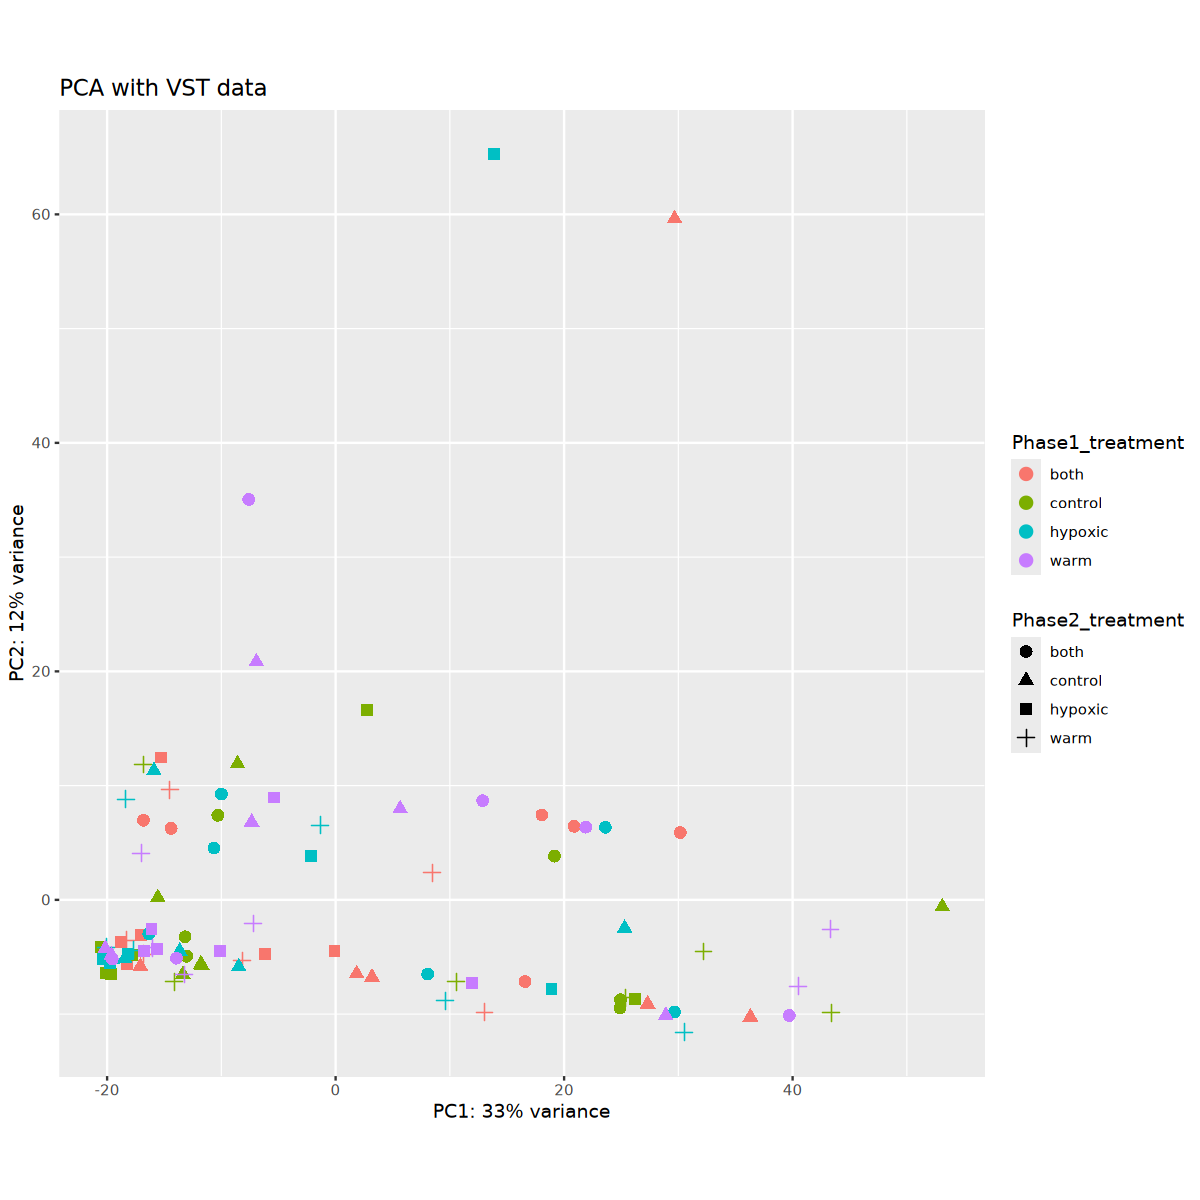

In [26]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData, "percentVar"))

ggplot(pcaData, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with VST data")

there's those two samples again in the bottom of the plot - B5_C1_O09 and H2_H5_B51 - that cluster away from everything else 

what do things look like if I remove those?

In [27]:
# remove two samples
dds_rm<- dds_filtered[, !colnames(dds_filtered) %in% c("B5_C1_O09", "H2_H5_B51")]

In [28]:
# normalization & transformation
vsd_filtered <- vst(dds_rm)

# calculate sample distances
sample_dists_filtered <- dist(t(assay(vsd_filtered)))
head(sample_dists_filtered)

[1] 83.57300 85.00560 81.17853 85.89723 84.96694 93.36499

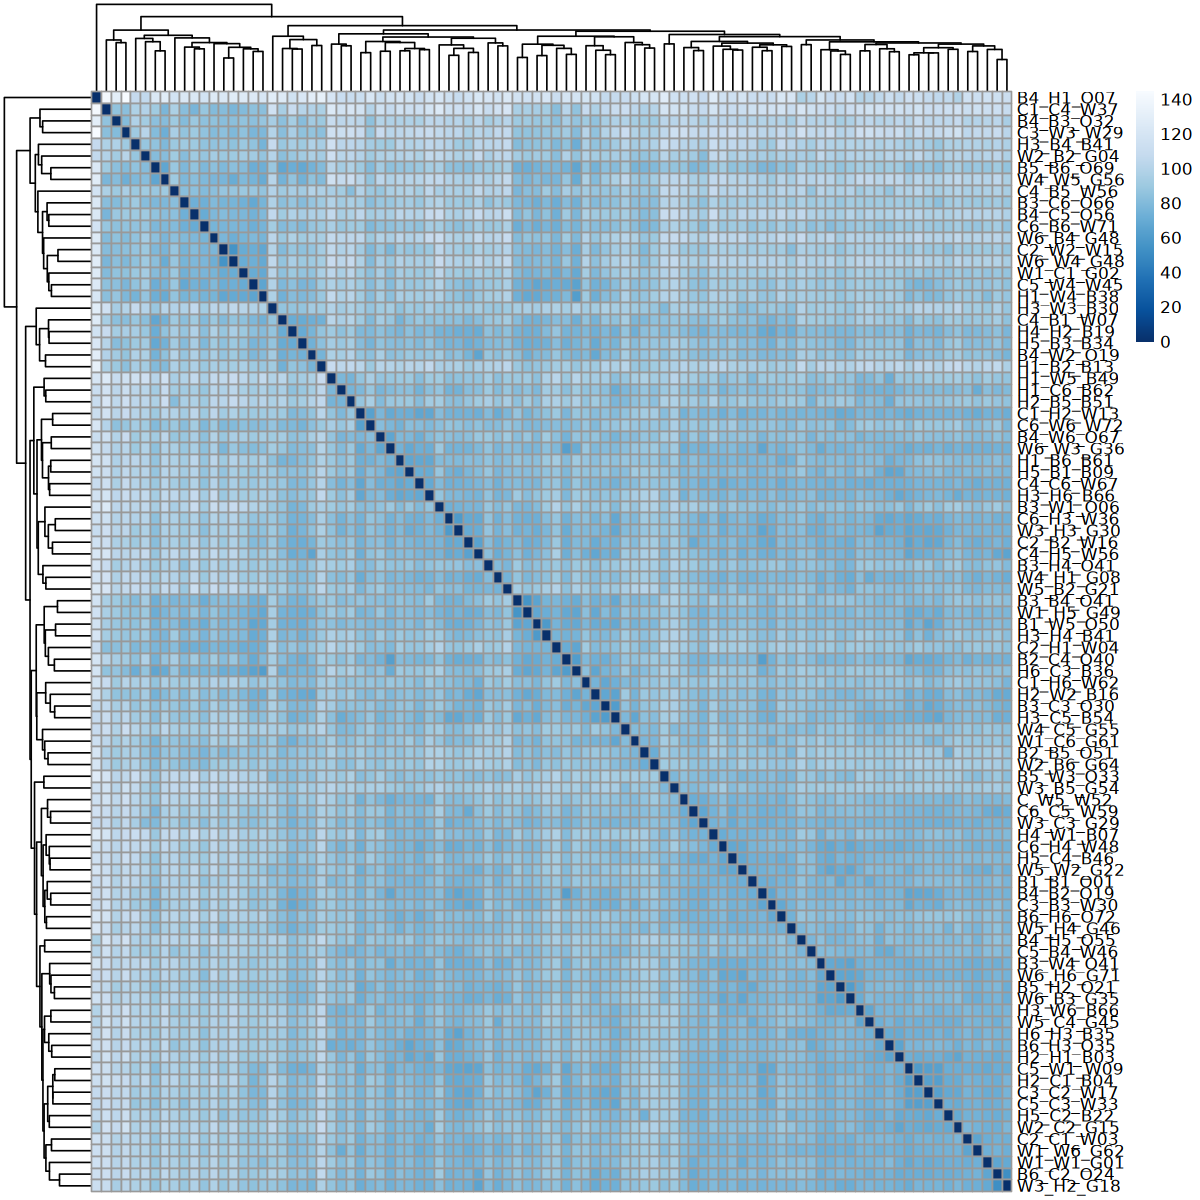

In [29]:
sampleDistMatrix <- as.matrix(sample_dists_filtered)
rownames(sampleDistMatrix) <- paste(colnames(vsd_filtered))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists_filtered,
         clustering_distance_cols = sample_dists_filtered,
         col = colors)

In [30]:
pcaData_filtered <- plotPCA(vsd_filtered, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData_filtered)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.850933,9.549141,both:both,both,both,B1_B1_O01
B1_W5_O50,13.459734,-5.230702,both:warm,both,warm,B1_W5_O50
B2_B5_O51,16.774422,13.986908,both:both,both,both,B2_B5_O51
B2_C4_O40,3.600465,-7.410534,both:control,both,control,B2_C4_O40
B3_B4_O41,16.505265,-6.486747,both:both,both,both,B3_B4_O41
B3_C3_O30,2.458575,-5.820249,both:control,both,control,B3_C3_O30


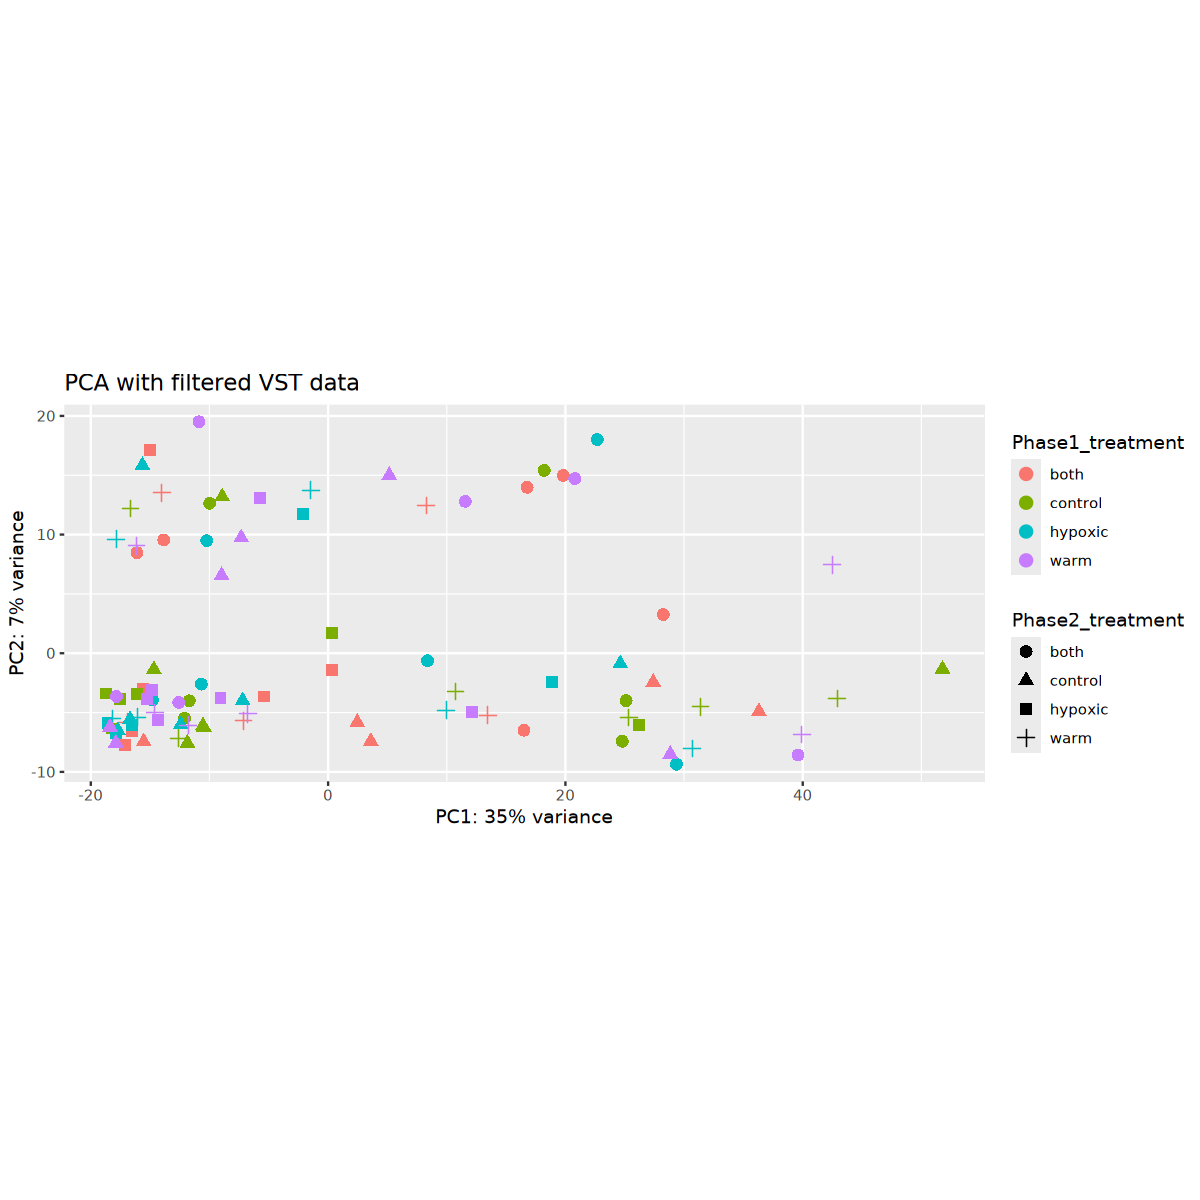

In [31]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData_filtered, "percentVar"))

ggplot(pcaData_filtered, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with filtered VST data")

In [32]:
# calculate MDS value from distance matrix
mdsData_filtered <- data.frame(cmdscale(sample_dists_filtered))
mds_filtered <- cbind(mdsData_filtered, as.data.frame(colData(vsd_filtered))) # combine with sample data
head(mds_filtered)

,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,16.213232,7.657561,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-14.539051,-5.325782,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-19.604045,-3.043449,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-1.928422,2.408078,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.600672,-8.919489,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,-1.731025,-16.065049,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


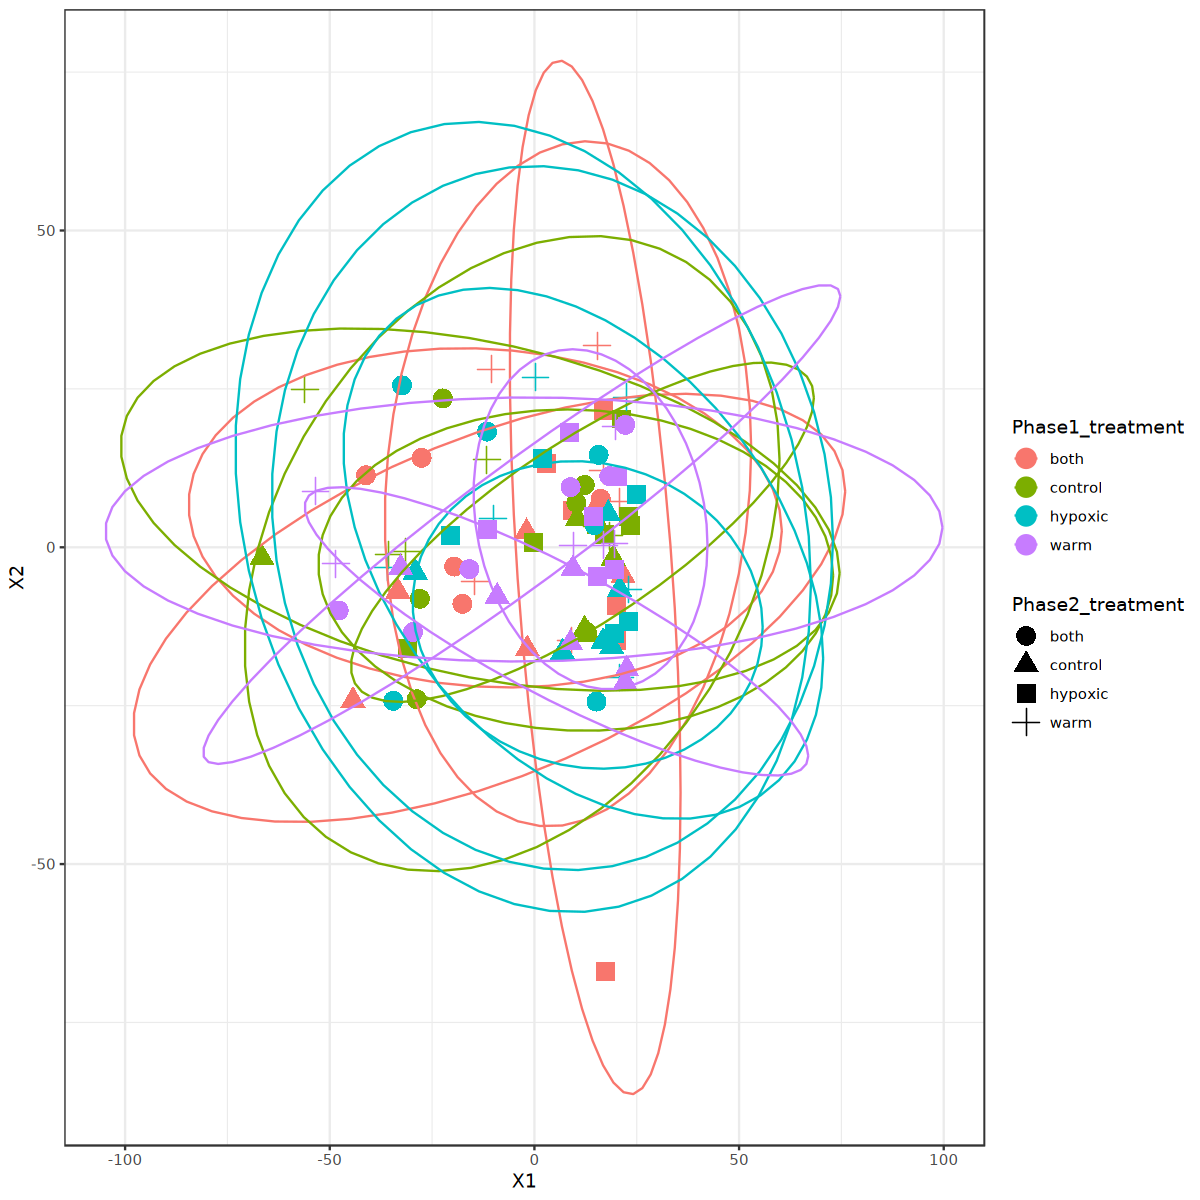

In [33]:
ggplot(mds_filtered, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

okay so it appears when we remove those two seemingly outlier samples, the data gets a little bit 'more clear' and replicates segregate a little better

let's remove those samples (**B5_C1_O09** and **H2_H5_B51**) and re-run DESeq2

## 2. remove outliers, run DESeq again

In [34]:
outlier_samples <- c('B5_C1_O09', 'H2_H5_B51')

dds_rm <- dds_filtered[, !colnames(dds_filtered) %in% outlier_samples]
dds_rm <- DESeq(dds_rm)
vst_mat <- assay(vst(dds_rm, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [35]:
#write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/vst_filtered.csv', row.names = FALSE)

In [36]:
meta_noOutliers <- meta[!rownames(meta) %in% outlier_samples, ]

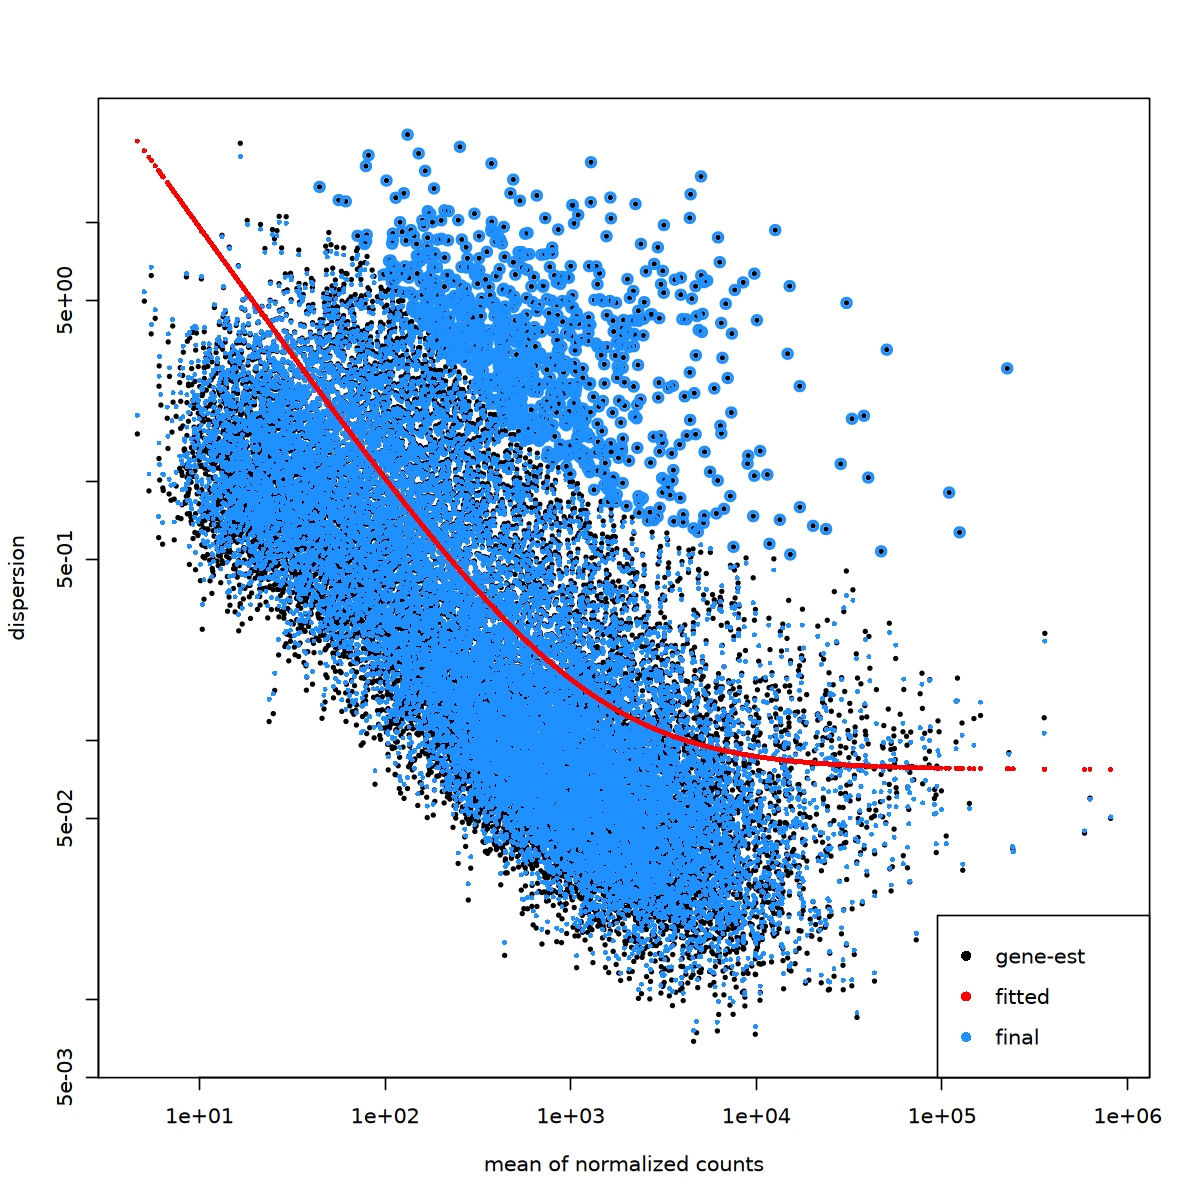

In [37]:
options(repr.plot.height = 10, repr.plot.width = 10)

plotDispEsts(dds_rm)

### PCA

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.423583,9.170181,both:both,both,both,B1_B1_O01
B1_W5_O50,12.986828,-5.082163,both:warm,both,warm,B1_W5_O50
B2_B5_O51,16.198514,13.610949,both:both,both,both,B2_B5_O51
B2_C4_O40,3.351833,-7.330330,both:control,both,control,B2_C4_O40
B3_B4_O41,16.015733,-6.358110,both:both,both,both,B3_B4_O41
B3_C3_O30,2.299876,-5.731781,both:control,both,control,B3_C3_O30


using ntop=500 top features by variance

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the DESeq2 package.
  Please report the issue to the authors.”


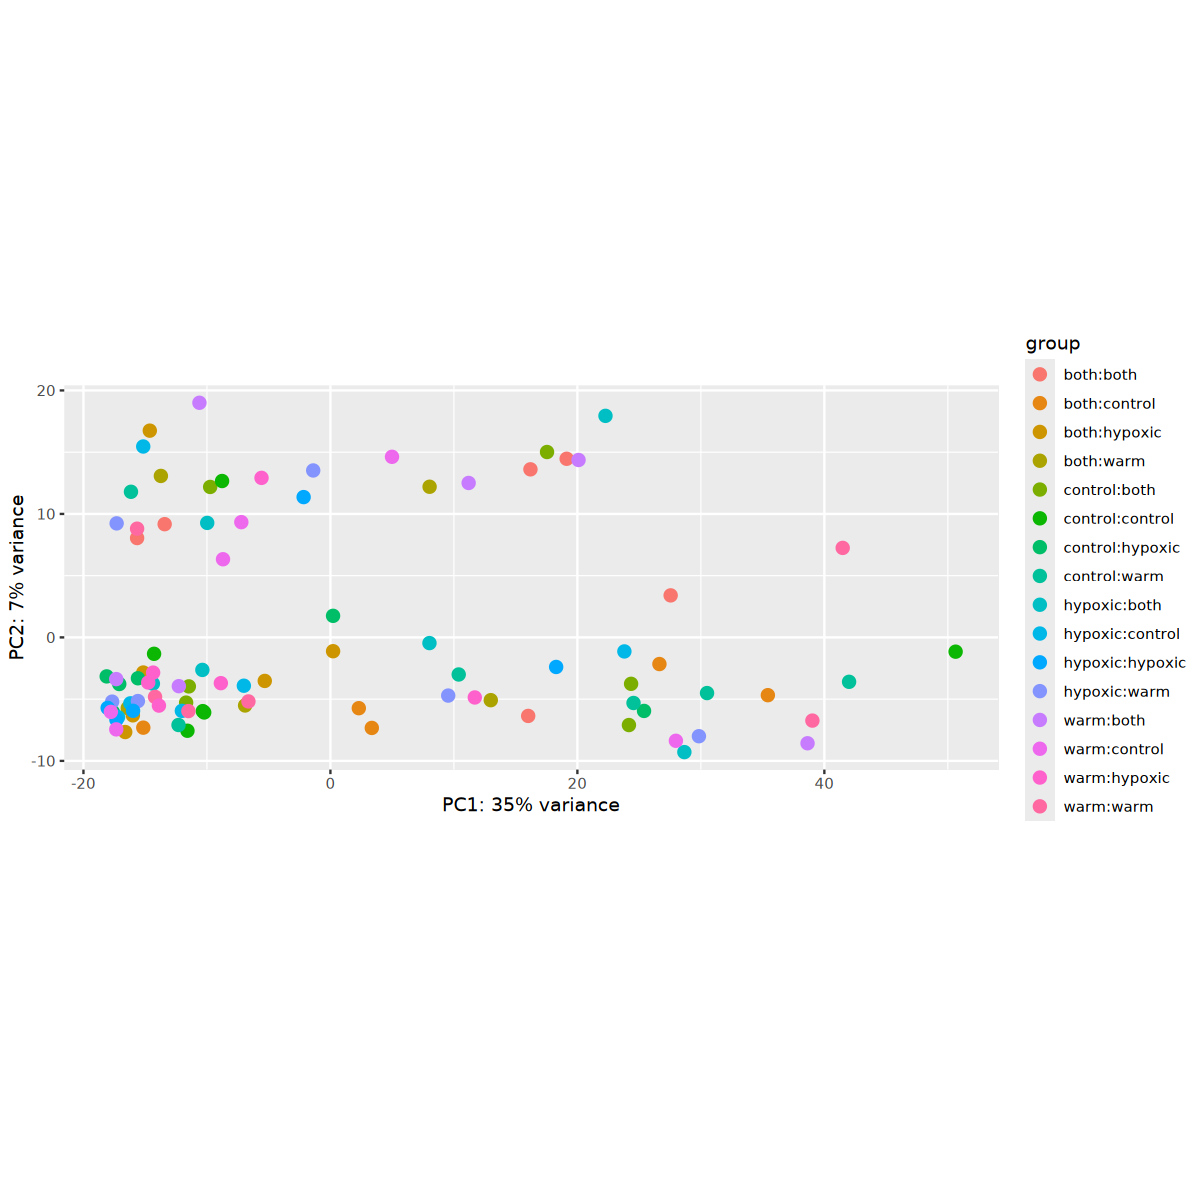

In [38]:
options(repr.plot.height = 10, repr.plot.width = 10)

vsd <- vst(dds_rm, blind=FALSE)
pca_data <- plotPCA(vsd, intgroup=c("Phase1_treatment", "Phase2_treatment"), returnData=TRUE)
head(pca_data)

plotPCA(vsd, intgroup=c("Phase1_treatment", "Phase2_treatment"))

two groups seperating on the y axis

also PC1 explains 34% of the variance

using ntop=500 top features by variance



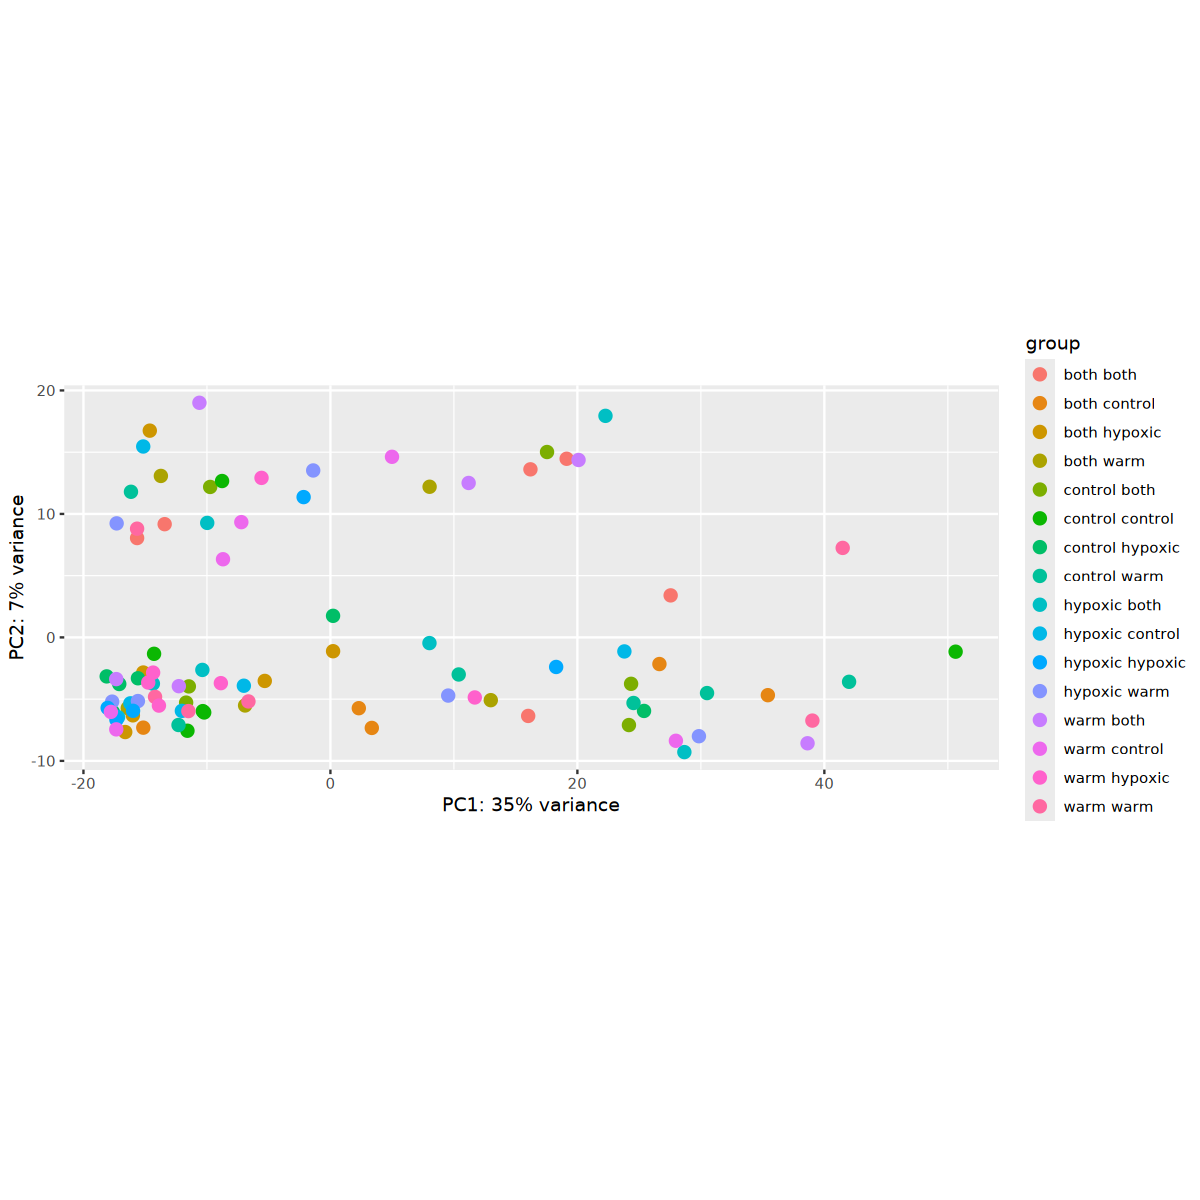

In [39]:
plotPCA(vsd, intgroup=c("complete_trtmt"))

### nMDS
normalize and transform DESeq object using vst (variance stabilized expression matrix)

In [40]:
# variance stabilizing transformation
vsd <- vst(dds_rm)
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.560664,11.352134,11.336837,11.196827,10.907699,10.890222,11.293816,10.973871,11.081133,11.103627,⋯,11.780509,10.547313,11.022230,11.479453,11.340666,11.159634,11.298263,11.144046,11.753854,11.595094
LOC144621269,8.761151,11.081248,11.501673,10.445114,11.541080,10.593712,12.792995,10.979899,8.529092,8.374672,⋯,13.898712,8.303282,8.381782,10.131463,8.692770,9.022081,13.450692,8.507795,9.801911,13.428352
LOC111120925,8.838275,8.558435,9.855111,8.413828,8.504295,8.392556,8.148543,8.235525,8.148543,8.234087,⋯,9.722500,8.148543,8.313558,9.873482,8.887793,8.613525,8.353985,8.238573,8.443813,8.413619
LOC144621283,10.003381,10.423273,10.446315,10.273935,10.366837,10.645492,10.611812,9.866002,10.203126,10.301700,⋯,10.094454,10.562745,10.311745,10.448469,10.419544,10.336706,10.071467,10.921733,10.085551,10.116075
LOC144621276,13.453056,13.496273,13.668784,13.502631,13.780353,13.901764,13.716028,13.220088,13.758780,13.436155,⋯,14.026562,13.310102,13.851955,13.548147,13.098292,13.282283,13.936432,13.375754,13.421556,13.372198
LOC111115920,9.206610,9.273554,9.175986,9.023418,8.946404,8.895978,8.807465,9.738052,8.989969,9.604449,⋯,8.915406,9.004806,9.451846,9.122374,9.765953,9.768795,9.275516,9.432226,8.969273,9.077169


In [41]:
# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,83.57300,85.00560,81.17853,85.89723,84.96694,93.36499,86.11212,85.87748,76.60241,⋯,99.50789,82.68700,72.29164,76.45714,73.35247,76.78986,95.52693,80.16005,78.05833,100.45719
B1_W5_O50,83.57300,0.00000,79.03440,70.34400,66.12562,72.41815,73.17783,84.98190,81.40680,80.70176,⋯,81.81444,89.24106,82.58574,82.30801,85.05317,81.94444,84.51311,84.18825,78.17530,80.97078
B2_B5_O51,85.00560,79.03440,0.00000,87.27676,81.21466,86.41233,82.48598,94.31609,97.77000,93.84019,⋯,87.13585,100.54270,91.34755,78.64404,89.70614,92.02841,87.55002,92.78569,88.20075,83.40653
B2_C4_O40,81.17853,70.34400,87.27676,0.00000,74.36733,72.82061,81.67108,83.31614,86.39551,76.02877,⋯,87.69104,84.75310,80.54947,80.18634,80.64127,79.14782,91.72372,78.42794,62.90276,88.81080
B3_B4_O41,85.89723,66.12562,81.21466,74.36733,0.00000,77.67575,79.29261,90.25259,78.47535,84.71563,⋯,80.92597,93.16505,83.67012,86.20043,89.87655,86.76156,81.23149,87.62121,81.86522,81.96380
B3_C3_O30,84.96694,72.41815,86.41233,72.82061,77.67575,0.00000,84.09097,89.45745,90.07101,84.90536,⋯,91.03928,91.85791,77.40643,87.02277,87.68069,84.08926,94.72719,81.61236,81.78075,93.18526


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,16.213232,7.657561,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-14.539051,-5.325782,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-19.604045,-3.043449,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-1.928422,2.408078,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.600672,-8.919489,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,-1.731025,-16.065049,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [42]:
mds$Phase1_treatment <- factor(mds$Phase1_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

mds$Phase2_treatment <- factor(mds$Phase2_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

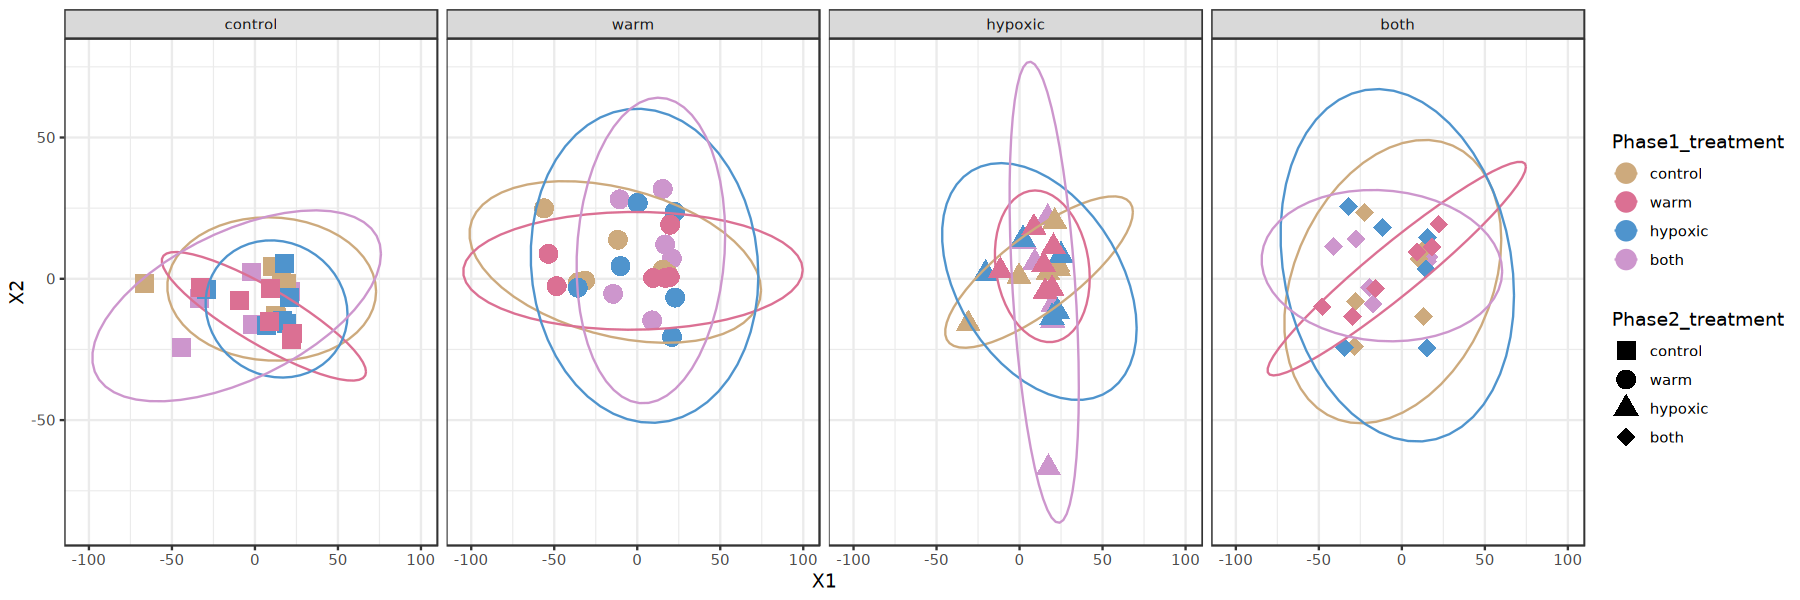

In [43]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
theme_bw()

nmds.plot

facet by phase 2 treatment

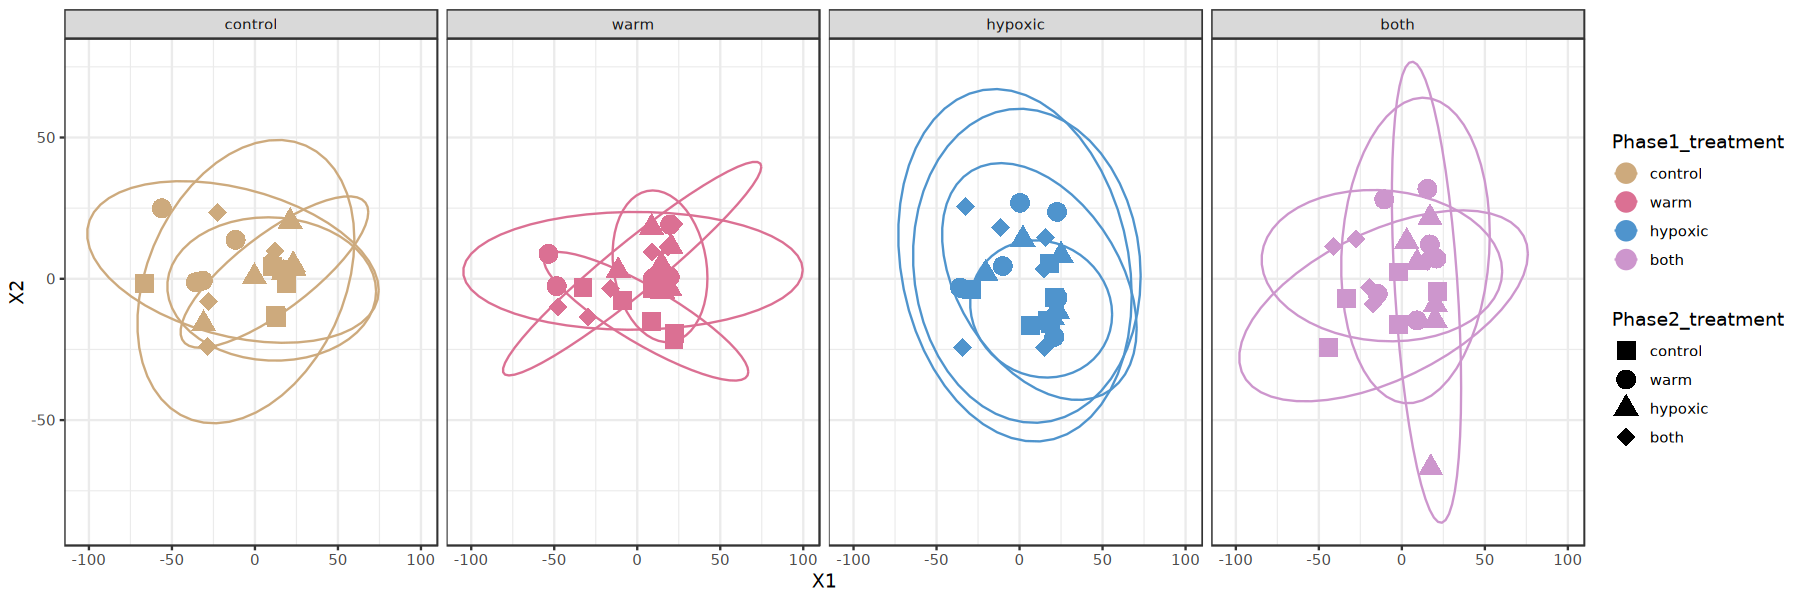

In [44]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
theme_bw()

nmds.plot

facet by phase 1 treatment

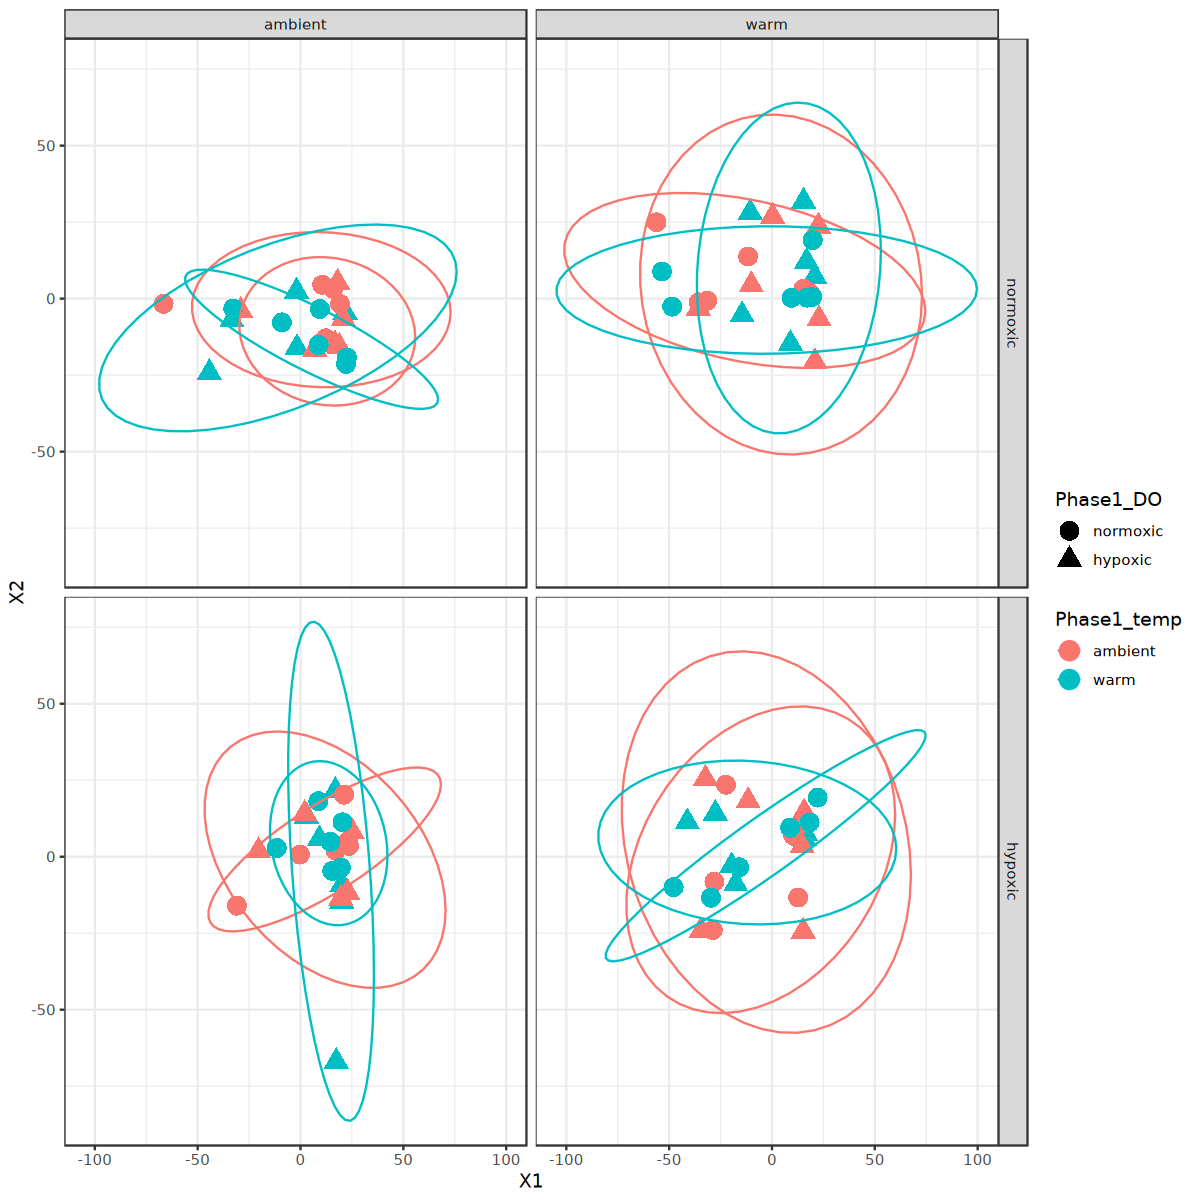

In [45]:
options(repr.plot.width = 10, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
facet_grid(Phase2_DO~Phase2_temp) + 
stat_ellipse() + 
theme_bw()

nmds.plot

facet by phase 2 temp (columns) and DO (rows) treatments, colored by phase 1 temp (colors) and DO (shape)

### permANOVA

differences in centroid location(position) between two groups

In [46]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3356.668,0.009455060,0.8910895,0.635
Phase1_DO,1,3115.927,0.008776940,0.8271803,0.784
Phase2_temp,1,9373.861,0.026404281,2.4884642,0.001
Phase2_DO,1,6080.817,0.017128438,1.6142650,0.016
Phase1_temp:Phase1_DO,1,2818.286,0.007938546,0.7481661,0.942
Phase1_temp:Phase2_temp,1,2828.331,0.007966841,0.7508327,0.919
Phase1_DO:Phase2_temp,1,3110.147,0.008760660,0.8256460,0.802
Phase1_temp:Phase2_DO,1,2902.305,0.008175209,0.7704703,0.889
Phase1_DO:Phase2_DO,1,3934.164,0.011081748,1.0443963,0.345


significant effects:
- phase2_temp (2.6% of variance)
- phase2_DO (1.7% of variance)
- phase2_temp:phase2_DO (1.7% of variance)

### heatmap 
of sample-to-sample distances using the variance stabilizing transformed values


following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [47]:
# normalization & transformation
vsd <- vst(dds_rm)

# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 83.57300 85.00560 81.17853 85.89723 84.96694 93.36499

In [48]:
head(vsd)

class: DESeqTransform 
dim: 6 94 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(94): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

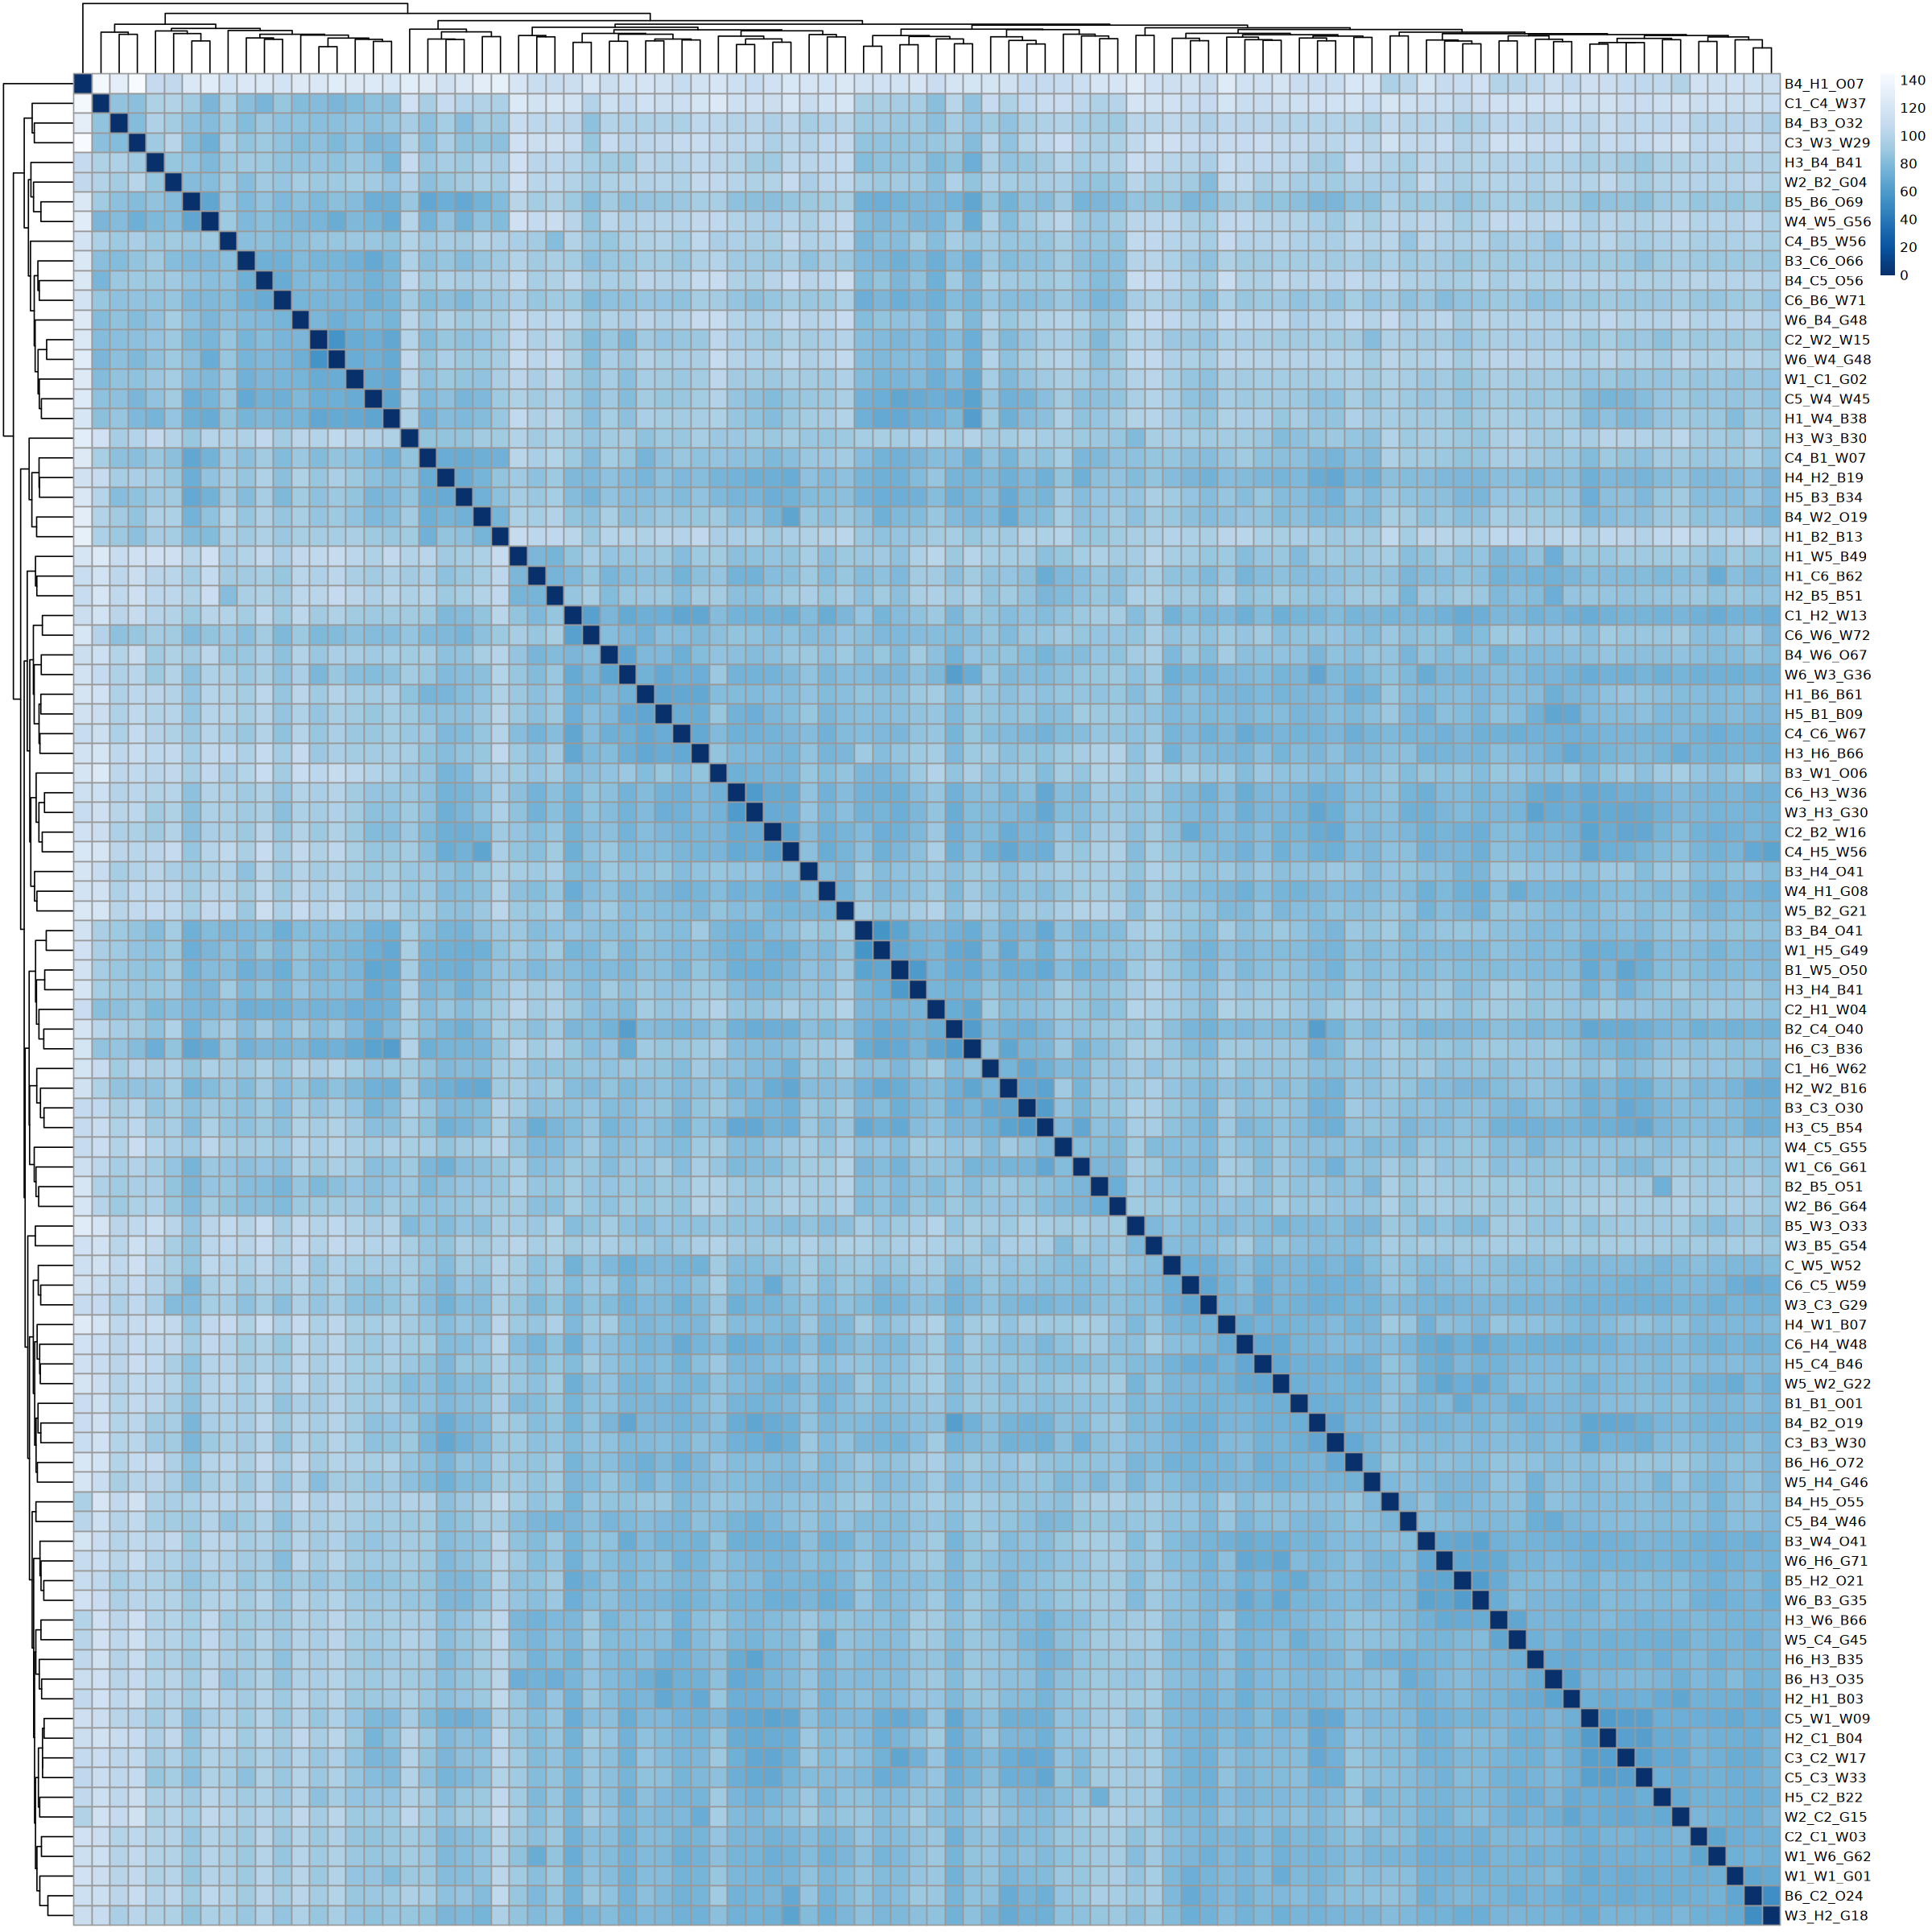

In [49]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

In [50]:
resultsNames(dds_rm)

[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

### MA plot
of one example comparison between HC and CC

In [51]:
# Unshrunken results for your contrast/interaction term
res <- results(dds, contrast = c("complete_trtmt", "hypoxic.control", "control.control"))
# or for an interaction/complex contrast:
# res <- results(dds, name = "phase1stressorA.phase2stressorB")

# Shrunken with ashr — works with contrast= or name= directly, no coef restriction
res_shrunk <- lfcShrink(dds, contrast = c("complete_trtmt", "hypoxic.control", "control.control"), type = "ashr")
# or: res_shrunk <- lfcShrink(dds, res = res, type = "ashr")

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



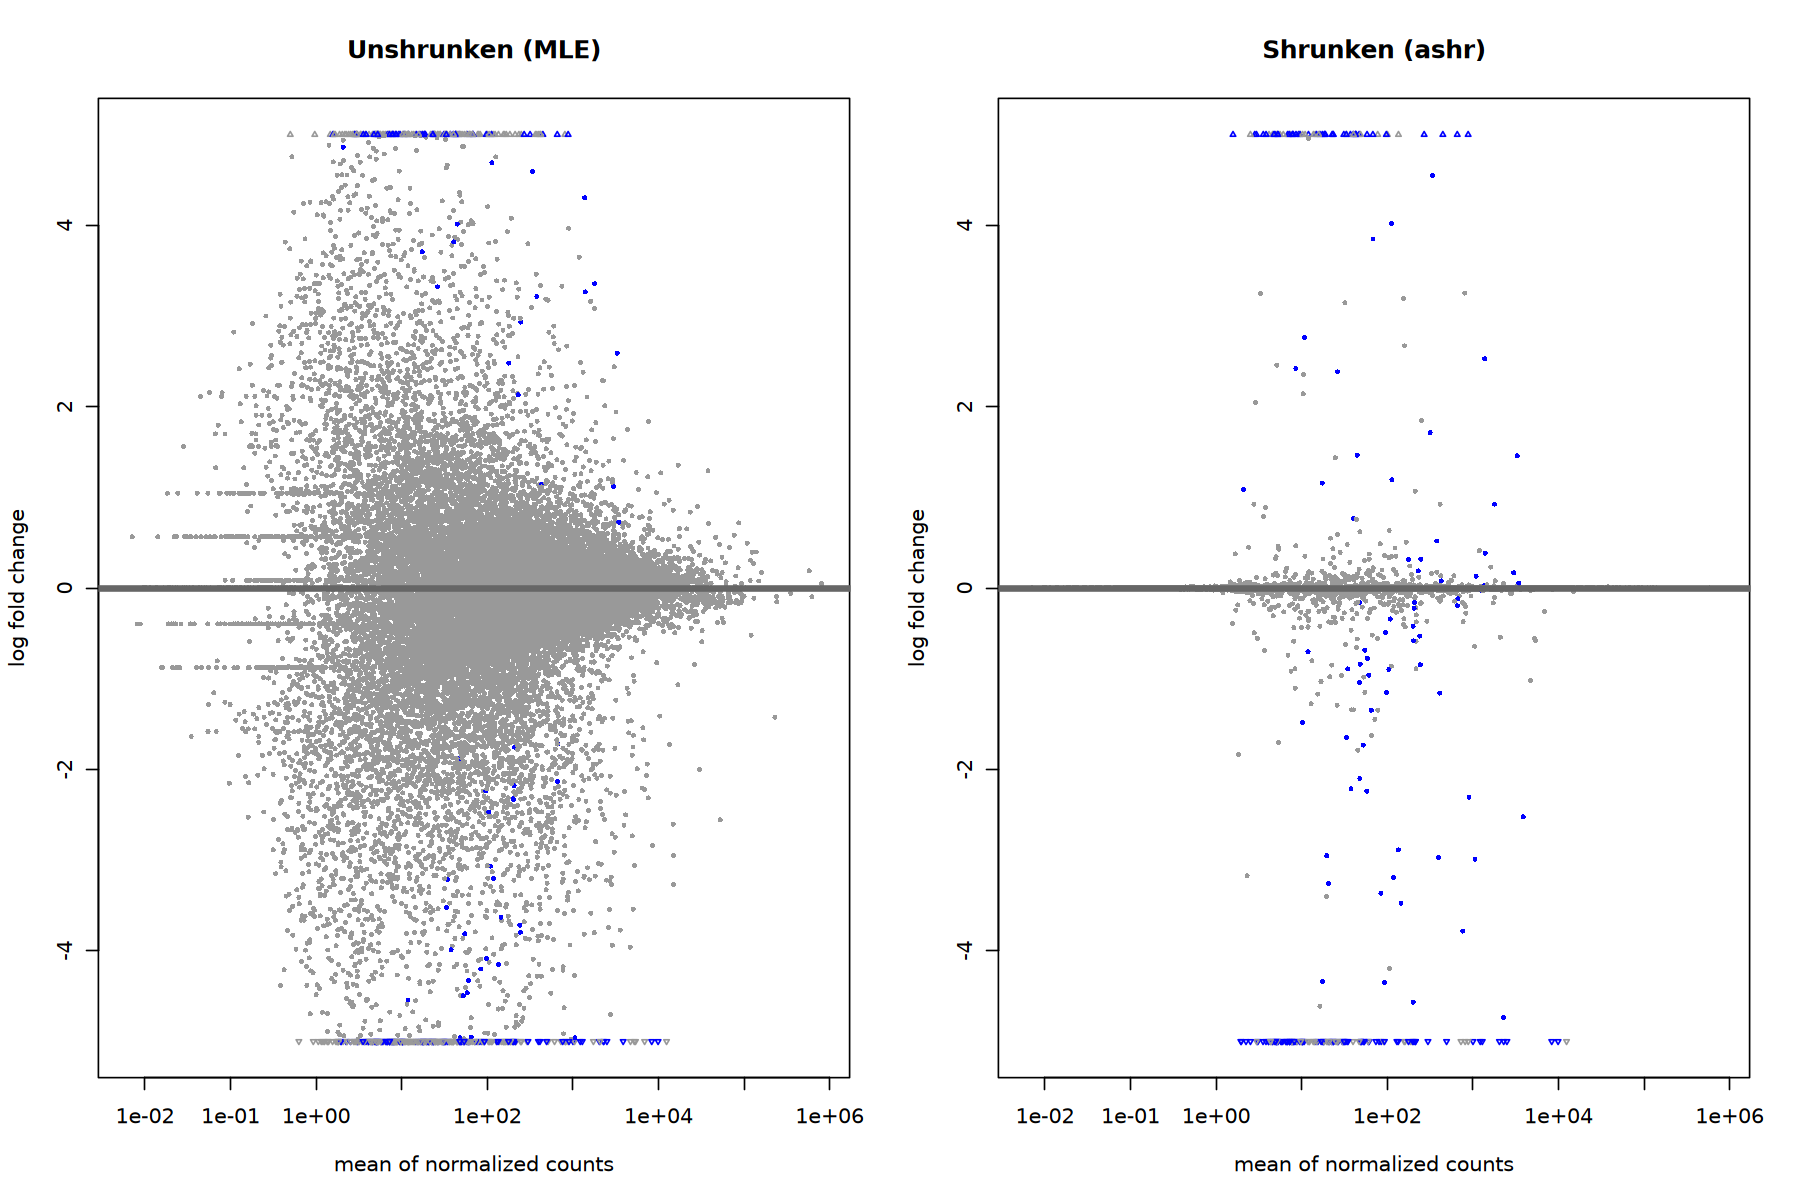

In [52]:
options(repr.plot.height = 10, repr.plot.width = 15)
par(mfrow = c(1, 2))
DESeq2::plotMA(res, ylim = c(-5, 5), main = "Unshrunken (MLE)")
DESeq2::plotMA(res_shrunk, ylim = c(-5, 5), main = "Shrunken (ashr)")

shrinking collapes the grey cloud to LFC = 0, so that genes with large LFC and low mean counts aren't showing up as DEGs (likely due to noise)

this shouldn't change the number of DEGs really - checking below:

In [53]:
sum(res$padj < 0.05, na.rm = TRUE)
sum(res_shrunk$padj < 0.05, na.rm = TRUE)  # should be ~identical to above

# now check with your actual FC cutoff
sum(res_shrunk$padj < 0.05 & abs(res_shrunk$log2FoldChange) > 1, na.rm = TRUE)
sum(res$padj < 0.05 & abs(res$log2FoldChange) > 1, na.rm = TRUE)  # unshrunken FC filter, for comparison

[1] 161

[1] 161

[1] 153

[1] 160

## Pairwise comparisons

### 1. Effect of single exposure on GE after a period of recovery
- CC vs. WC
- CC vs. HC
- CC vs. BC

**CC vs. WC**

In [54]:
options(repr.plot.width = 5, repr.plot.height = 10)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 9, 0.042%
LFC < 0 (down)     : 20, 0.092%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.284105e-04,0.006772468,0.4741091,0.9999322,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.521198e-03,0.068310222,0.1807687,0.9999322,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-2.319799e-05,0.030812832,0.9672640,0.9999322,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-5.662076e-05,0.006512205,0.7621260,0.9999322,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,6.389263e-05,0.006423771,0.7647931,0.9999322,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.744569e-04,0.010404134,0.2915175,0.9999322,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


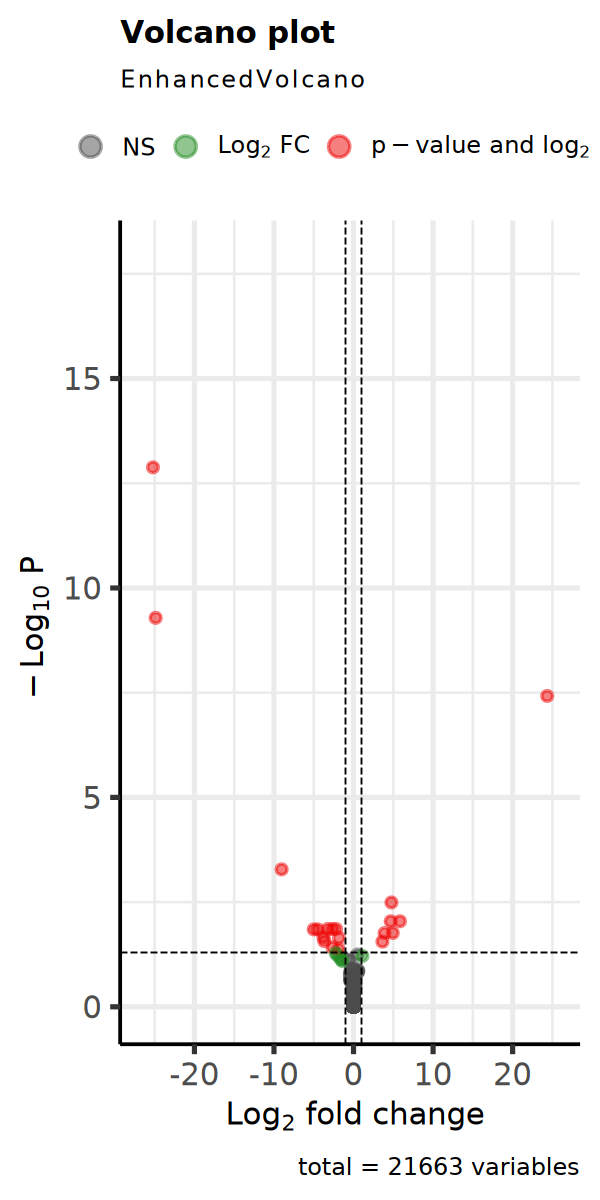

In [55]:
res.wc.cc <- lfcShrink(dds_rm, 
                       contrast= c('complete_trtmt', 'warm.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.wc.cc)

EnhancedVolcano(res.wc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.cc <- merge(res.wc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.cc)[1] <- 'Gene'

head(res.wc.cc)

In [56]:
write.csv(res.wc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_cc.csv', row.names = FALSE)

**CC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 8, 0.037%
LFC < 0 (down)     : 22, 0.1%
outliers [1]       : 21, 0.097%
low counts [2]     : 420, 1.9%
(mean count < 14)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): complete_trtmt hypoxic.control vs control.control 
Wald test p-value: complete_trtmt hypoxic.control vs control.control 
DataFrame with 6 rows and 5 columns
                  Gene log2FoldChange      lfcSE    pvalue      padj
             <numeric>      <numeric>  <numeric> <numeric> <numeric>
LOC144621260  1961.043   -3.44375e-04 0.00929308 0.0897458  0.999861
LOC144621269  2462.208   -6.86335e-03 0.16151343 0.0433205  0.999861
LOC111120925   129.322   -1.39433e-05 0.03072543 0.9802265  0.999861
LOC144621283   865.904    3.51893e-05 0.00625678 0.8391159  0.999861
LOC144621276 12437.026    2.43584e-05 0.00617345 0.9020136  0.999861
LOC111115920   171.624    1.39041e-05 0.00738113 0.9108714  0.999861

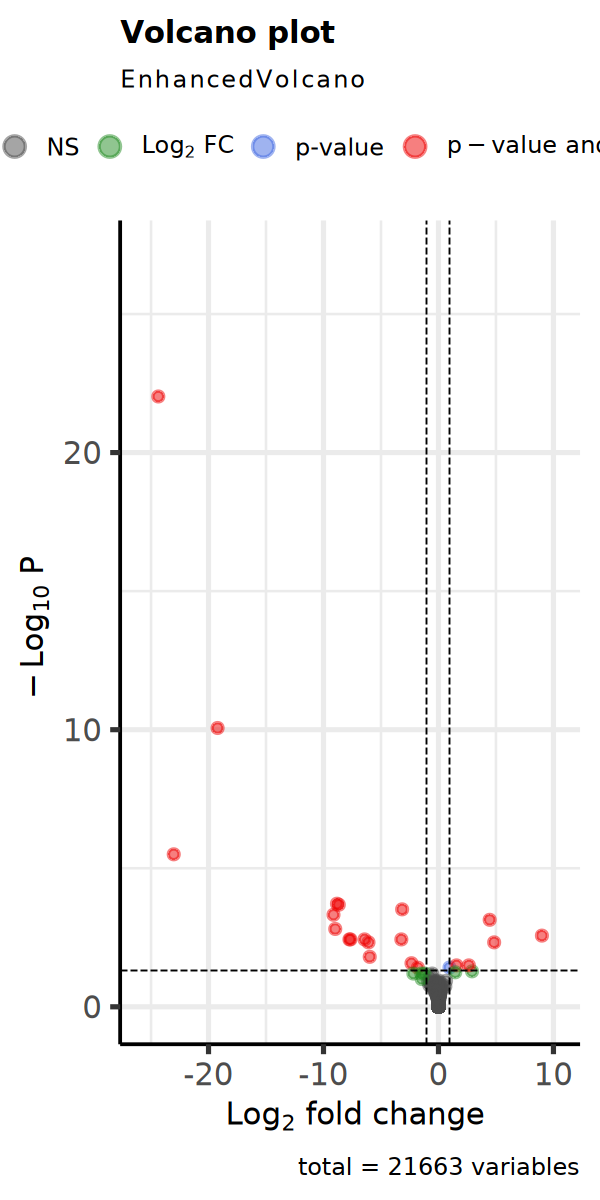

In [57]:
res.hc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.hc.cc)

EnhancedVolcano(res.hc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

names(res.hc.cc)[1] <- 'Gene'

head(res.hc.cc)

In [58]:
write.csv(res.hc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hc_cc.csv', row.names = FALSE)

**CC vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 9, 0.042%
LFC < 0 (down)     : 23, 0.11%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-3.068373e-04,0.007732340,0.11404859,0.9997639,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.151692e-04,0.022046568,0.63526456,0.9997639,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-2.207857e-03,0.095260822,0.06394161,0.9997639,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,1.923272e-05,0.006815646,0.92206295,0.9997639,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,5.428415e-05,0.006791711,0.81204649,0.9997639,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-5.024992e-06,0.007233573,0.96489135,0.9997639,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


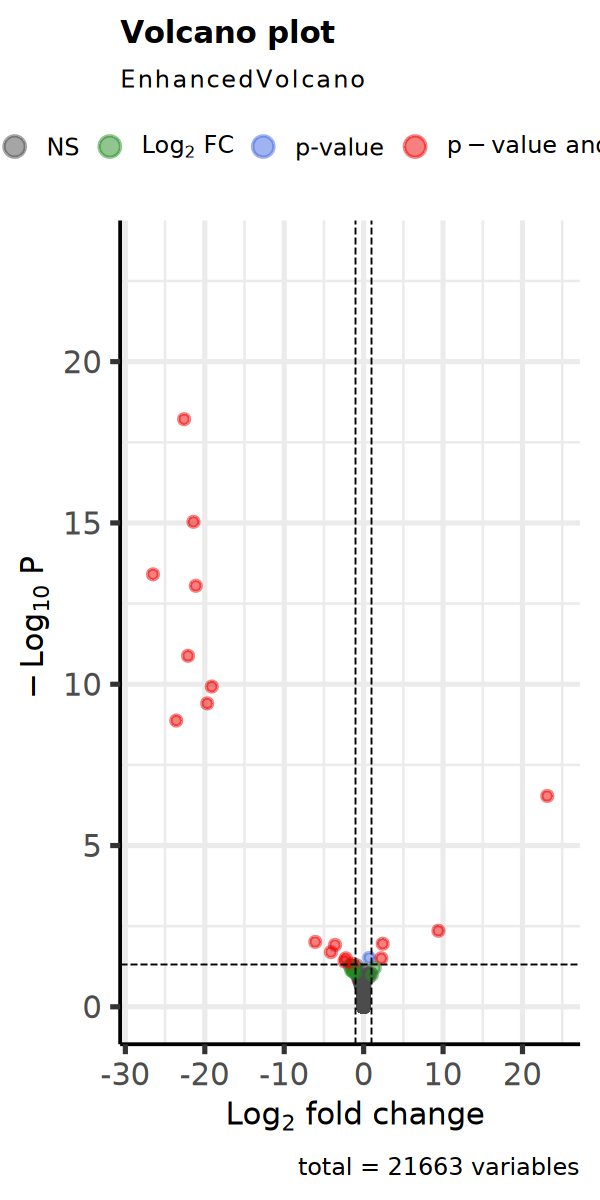

In [59]:
res.bc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.bc.cc)

EnhancedVolcano(res.bc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.cc <- merge(res.bc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.cc)[1] <- 'Gene'

head(res.bc.cc)

In [60]:
write.csv(res.bc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_cc.csv', row.names = FALSE)

### 2. Effect of single exposure experienced only later in life
- CC vs. CW
- CC vs. CH
- CC vs. CB

**CC vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 24, 0.11%
LFC < 0 (down)     : 24, 0.11%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0049676912,0.08080010,0.8529999,0.9890309,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0007241625,0.09613457,0.9003234,0.9938197,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0037908620,0.10279191,0.5160429,0.9502100,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0108052959,0.08006349,0.7039259,0.9755325,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0174686131,0.07824303,0.5826732,0.9609947,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0042172500,0.08435384,0.7955686,0.9859341,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


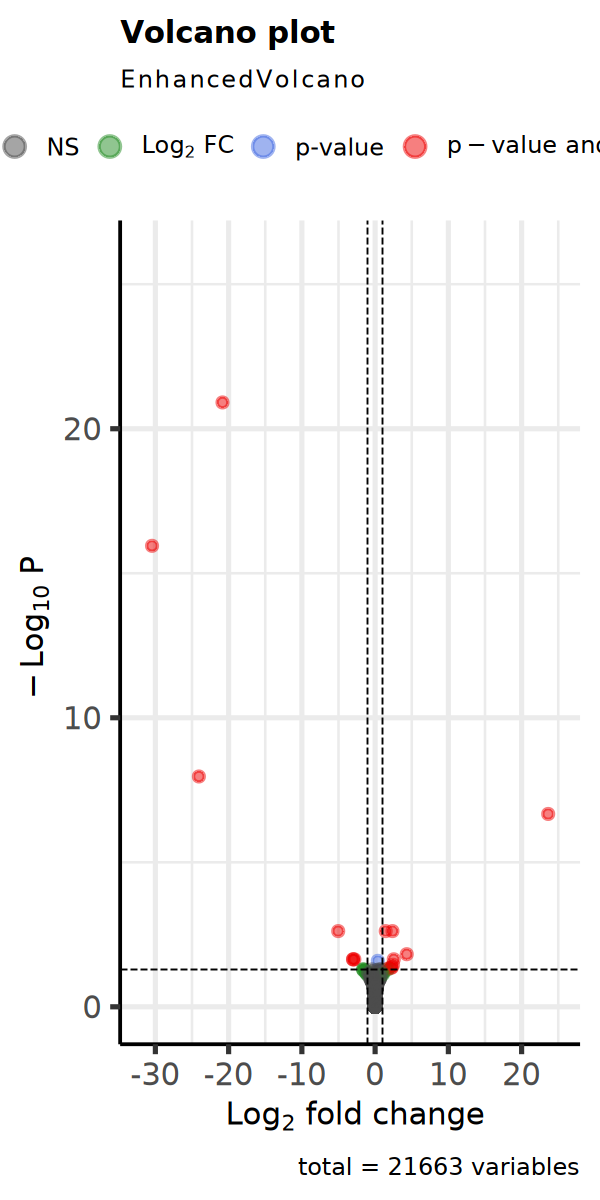

In [61]:
res.cw.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cw.cc)

EnhancedVolcano(res.cw.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.cc <- merge(res.cw.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.cc)[1] <- 'Gene'

head(res.cw.cc)

In [62]:
write.csv(res.cw.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_cc.csv', row.names = FALSE)

**CC vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 34, 0.16%
LFC < 0 (down)     : 25, 0.12%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.068950122,0.09619825,0.04971029,0.6156574,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.016605866,0.16911543,0.10165263,0.7100661,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.015508666,0.16881335,0.11268318,0.7374325,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.024961220,0.09050232,0.49083672,0.9093581,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.068057838,0.08922308,0.09094781,0.7012086,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.002937741,0.09722335,0.89199947,0.9895104,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


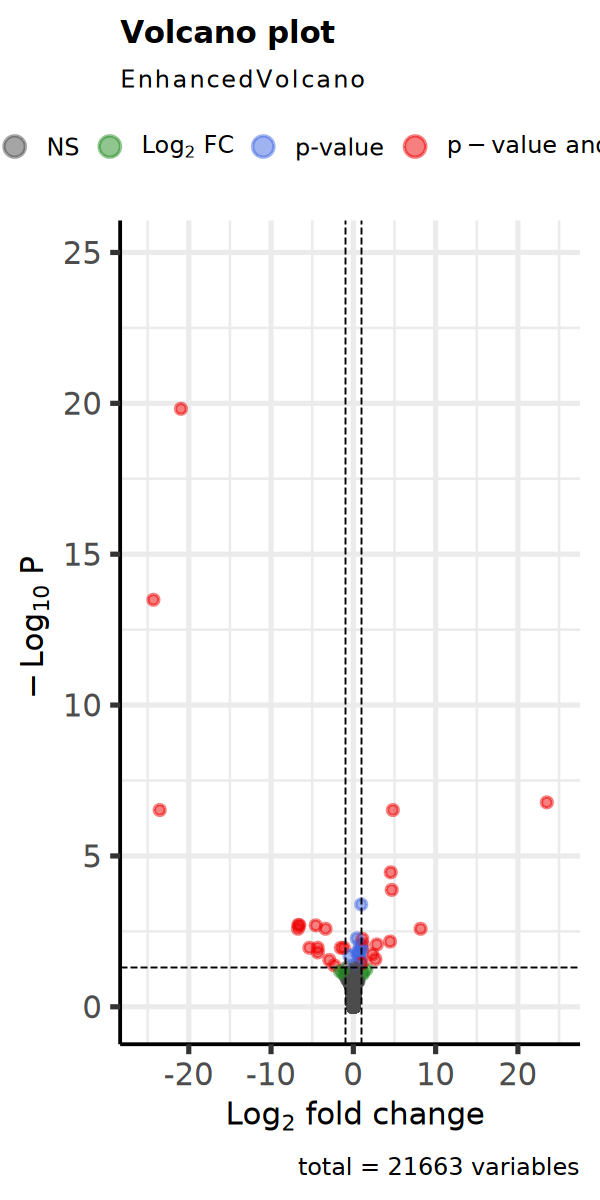

In [63]:
res.ch.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.ch.cc)

EnhancedVolcano(res.ch.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.cc <- merge(res.ch.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.cc)[1] <- 'Gene'

head(res.ch.cc)

In [64]:
write.csv(res.ch.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ch_cc.csv', row.names = FALSE)

**CC vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 150, 0.69%
LFC < 0 (down)     : 83, 0.38%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.057631558,0.1282724,0.3596998,0.8457311,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.021655536,0.1898777,0.2811688,0.8016278,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.018823435,0.1883219,0.3268789,0.8260207,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.004588077,0.1178909,0.9406725,0.9922309,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.068769255,0.1182568,0.2980517,0.8107010,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.010572489,0.1445240,0.8243531,0.9742714,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


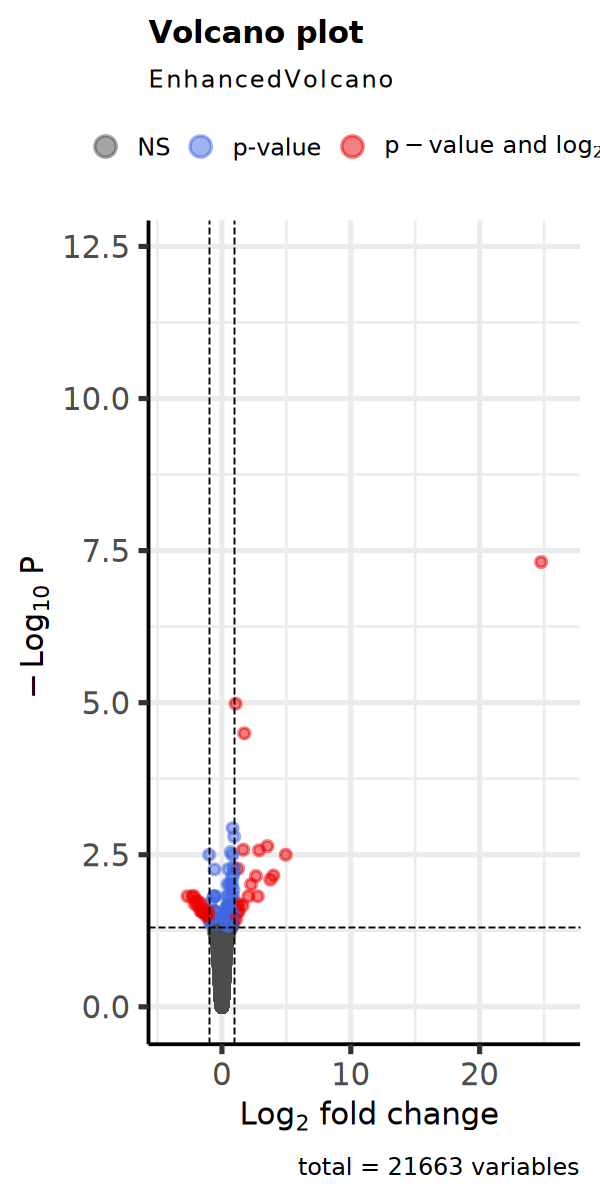

In [65]:
res.cb.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cb.cc)

EnhancedVolcano(res.cb.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cc <- merge(res.cb.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cc)[1] <- 'Gene'

head(res.cb.cc)

In [66]:
write.csv(res.cb.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_cc.csv', row.names = FALSE)

### 3. Timing of Stress Exposure
How does GE change depending on when stress is experienced (when all oysters only experience stress once)?
- CH vs. HC
- CW vs. WC
- CB vs. BC

**CH vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 16, 0.074%
LFC < 0 (down)     : 11, 0.051%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.371943e-03,0.03548721,0.79055953,0.9930523,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,6.968527e-04,0.05559889,0.70116255,0.9930523,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-5.484660e-03,0.12255375,0.11841703,0.8790303,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-4.967492e-03,0.03552417,0.37247957,0.9705166,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-1.180436e-02,0.03617808,0.06975495,0.8419645,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,7.143641e-05,0.03620993,0.98101357,0.9996604,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


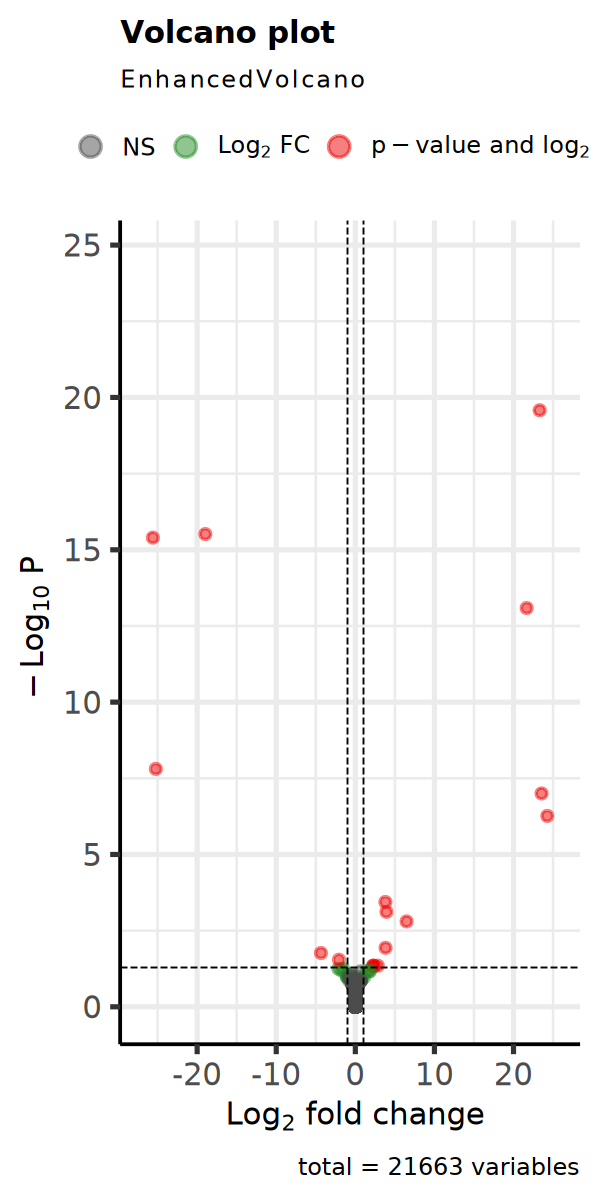

In [67]:
res.ch.hc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.ch.hc)

EnhancedVolcano(res.ch.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.hc <- merge(res.ch.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.hc)[1] <- 'Gene'

head(res.ch.hc)

In [68]:
write.csv(res.ch.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ch_hc.csv', row.names = FALSE)

**CW vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 74, 0.34%
LFC < 0 (down)     : 48, 0.22%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.041901638,0.1387295,0.5958181,0.8800570,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.025222474,0.1963412,0.2250764,0.6689855,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.011566215,0.1813827,0.5429298,0.8583598,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.006259228,0.1350992,0.9383492,0.9875576,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.070966112,0.1269095,0.3960810,0.7877215,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.045316909,0.1579202,0.4265680,0.8034130,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


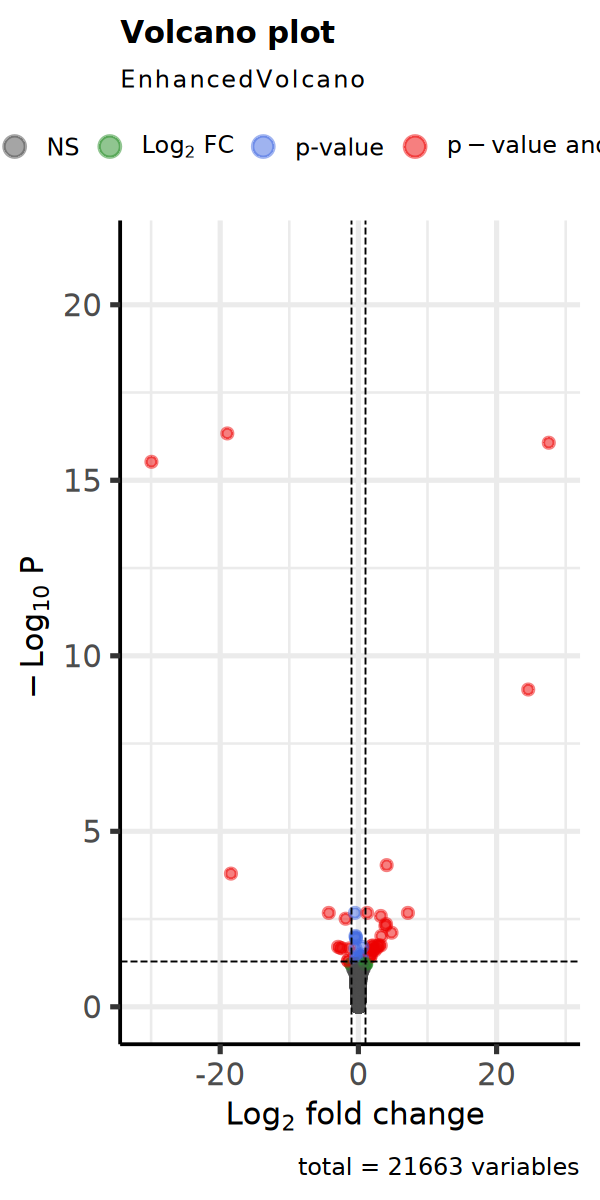

In [69]:
res.cw.wc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.cw.wc)

EnhancedVolcano(res.cw.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.wc <- merge(res.cw.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.wc)[1] <- 'Gene'

head(res.cw.wc)

In [70]:
write.csv(res.cw.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_wc.csv', row.names = FALSE)

**CB vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 192, 0.89%
LFC < 0 (down)     : 100, 0.46%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.040475385,0.1247434,0.479690606,0.8887479,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.010654989,0.1827611,0.580113316,0.9206694,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.163368811,0.7180511,0.005393764,0.1913637,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.001511341,0.1153595,0.978585166,0.9963483,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.044779162,0.1129283,0.450606467,0.8758446,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.011639461,0.1449489,0.798282737,0.9648944,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


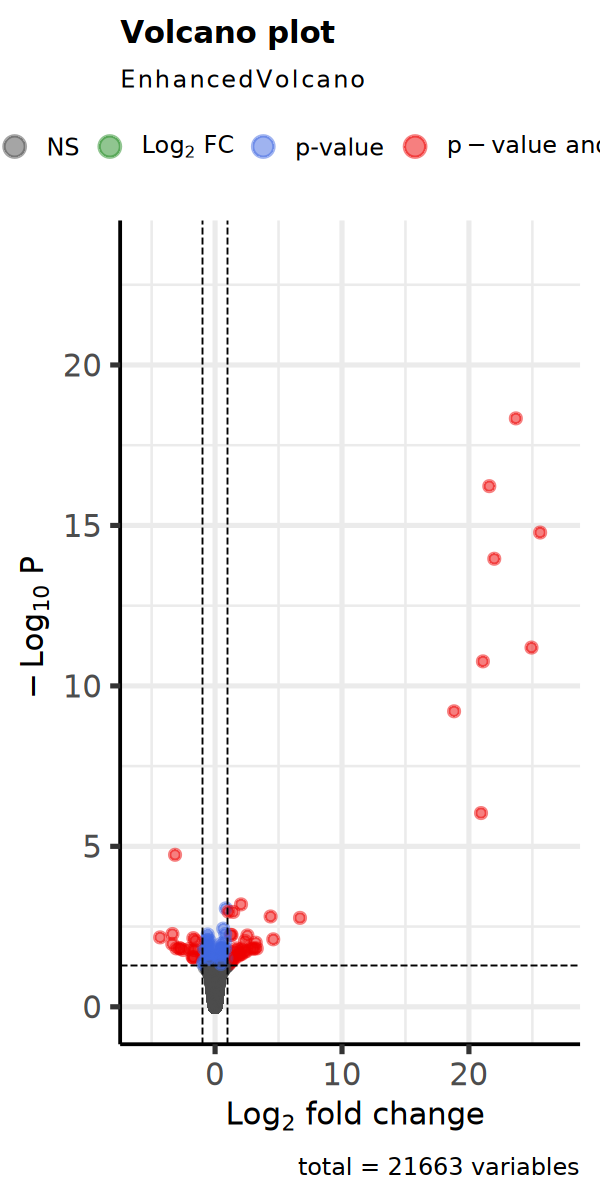

In [71]:
res.cb.bc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'both.control'), # BC is the "control"
                     type = 'ashr')

summary(res.cb.bc)

EnhancedVolcano(res.cb.bc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bc <- merge(res.cb.bc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bc)[1] <- 'Gene'

head(res.cb.bc)

In [72]:
write.csv(res.cb.bc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_bc.csv', row.names = FALSE)

### 4. No stress vs. most stress
- CC vs. WW
- CC vs. HH
- CC vs. BB

**CC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 18, 0.083%
LFC < 0 (down)     : 8, 0.037%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0010880040,0.03218257,0.7980691,0.999244,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0004828235,0.04623064,0.7021257,0.999244,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0001736228,0.04591147,0.8891953,0.999244,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0057591413,0.03234870,0.2097992,0.999244,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0038142220,0.03200963,0.4728583,0.999244,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0016684056,0.03293548,0.4970442,0.999244,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


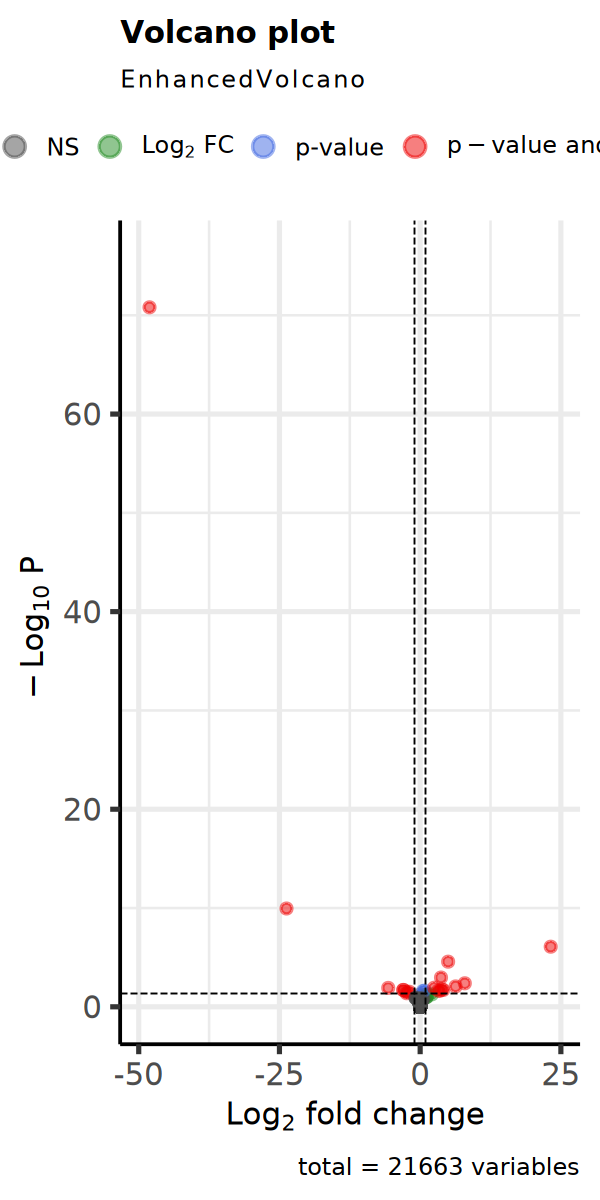

In [73]:
res.cc.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.ww)

EnhancedVolcano(res.cc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.ww <- merge(res.cc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.ww)[1] <- 'Gene'

head(res.cc.ww)

In [74]:
write.csv(res.cc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ww_cc.csv', row.names = FALSE)

**CC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 28, 0.13%
LFC < 0 (down)     : 28, 0.13%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0430523475,0.08863835,0.1313344,0.7577549,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0132675188,0.16288693,0.1085330,0.7268541,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0007979111,0.10172227,0.8917740,0.9895282,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0060855400,0.08264981,0.8330069,0.9830109,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0011591416,0.07984143,0.9707103,0.9986941,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0062713047,0.08903940,0.7166194,0.9693277,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


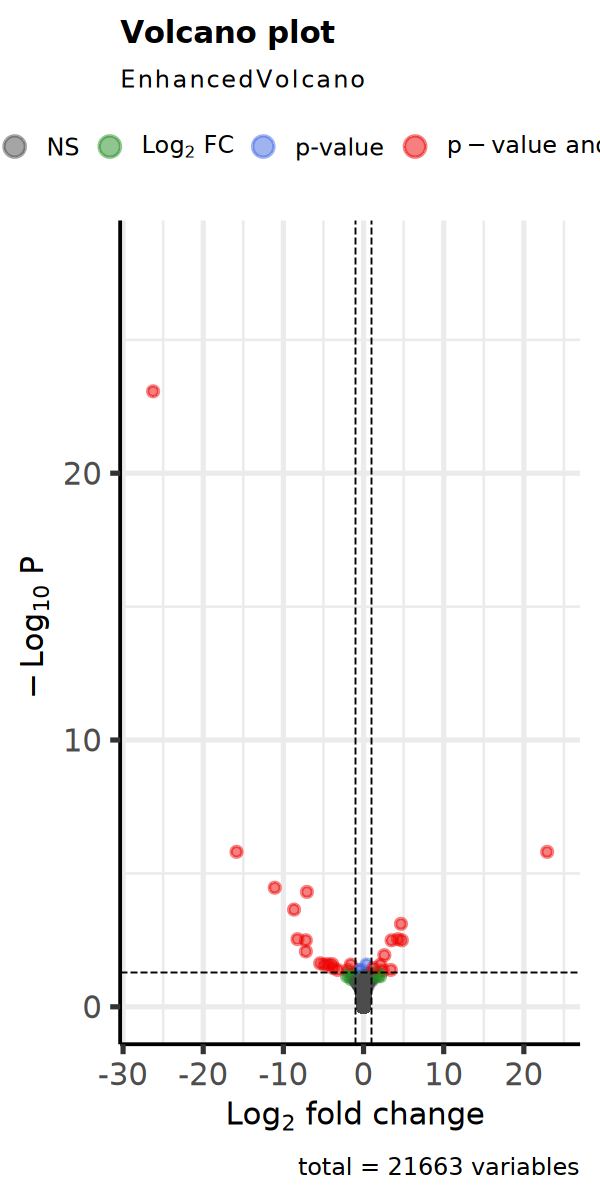

In [75]:
res.cc.hh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.hh)

EnhancedVolcano(res.cc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.hh <- merge(res.cc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.hh)[1] <- 'Gene'

head(res.cc.hh)

In [76]:
write.csv(res.cc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hh_cc.csv', row.names = FALSE)

**CC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 33, 0.15%
LFC < 0 (down)     : 76, 0.35%
outliers [1]       : 21, 0.097%
low counts [2]     : 420, 1.9%
(mean count < 14)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.032879005,0.09924328,0.4060885,0.8814575,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.007467688,0.14248935,0.5347197,0.9203878,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.008004434,0.14533174,0.4962622,0.9083412,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.003703244,0.09610745,0.9280033,0.9939524,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.004053870,0.09255085,0.9273900,0.9939524,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.007278349,0.10792291,0.7837454,0.9730234,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


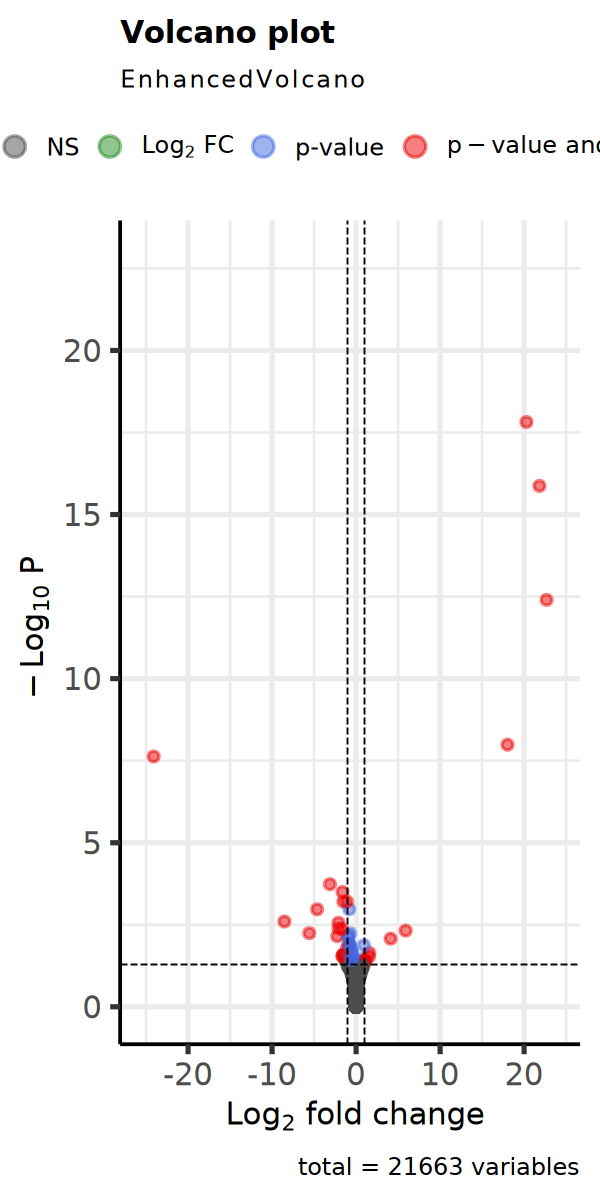

In [77]:
res.cc.bb <- lfcShrink(dds_rm, coef='complete_trtmt_control.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.cc.bb)

EnhancedVolcano(res.cc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.bb <- merge(res.cc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.bb)[1] <- 'Gene'

head(res.cc.bb)

switch LFC direction so CC is the baseline (deseq recognizes as bb as the baseline rn)

In [78]:
cc.bb.df <- as.data.frame(res.cc.bb) %>% # create df
mutate(log2FoldChange = log2FoldChange * -1) # multiple by -1 to make pos to neg and vice versa 

# validate
head(res.cc.bb)
head(cc.bb.df)

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.032879005,0.09924328,0.4060885,0.8814575,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.007467688,0.14248935,0.5347197,0.9203878,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.008004434,0.14533174,0.4962622,0.9083412,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.003703244,0.09610745,0.9280033,0.9939524,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.004053870,0.09255085,0.9273900,0.9939524,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.007278349,0.10792291,0.7837454,0.9730234,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.032879005,0.09924328,0.4060885,0.8814575,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.007467688,0.14248935,0.5347197,0.9203878,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.008004434,0.14533174,0.4962622,0.9083412,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.003703244,0.09610745,0.9280033,0.9939524,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.004053870,0.09255085,0.9273900,0.9939524,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.007278349,0.10792291,0.7837454,0.9730234,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


In [79]:
write.csv(cc.bb.df, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bb_cc.csv', row.names = FALSE)

### 5. Effect of initial exposure on response in later exposure
(also gets at the effect of priming to stress)

#### 5A. Matched stressors
Oyster is primed with a stress, and experiences the *same* stressor again
- HH vs. CH
- WW vs. CW
- BB vs. CB

**HH vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 26, 0.12%
LFC < 0 (down)     : 49, 0.23%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,9.467480e-05,0.008377616,0.71718121,0.9990084,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.334354e-04,0.071183420,0.96481311,0.9990084,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,1.571898e-02,0.230257127,0.09921588,0.9990084,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,2.527411e-04,0.009478362,0.38553616,0.9990084,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,6.411490e-04,0.013580872,0.11524800,0.9990084,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,9.288876e-05,0.013772291,0.81537771,0.9990084,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


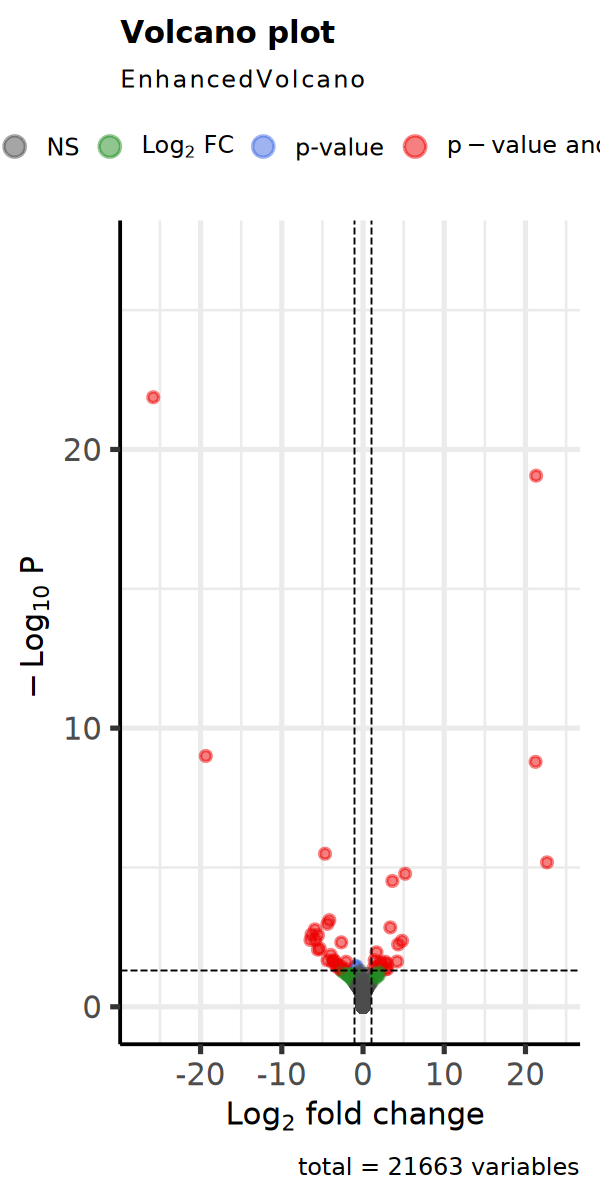

In [80]:
res.hh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.hh.ch)

EnhancedVolcano(res.hh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.ch <- merge(res.hh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.ch)[1] <- 'Gene'

head(res.hh.ch)

In [81]:
write.csv(res.hh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hh_ch.csv', row.names = FALSE)

**WW vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 15, 0.069%
LFC < 0 (down)     : 15, 0.069%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.184725e-05,0.006398102,0.9437759,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.762728e-04,0.033894562,0.7970248,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,4.024028e-04,0.039839586,0.6099402,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.615555e-04,0.006799025,0.3823576,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-3.352792e-05,0.006198607,0.8663260,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,6.460581e-05,0.008522761,0.6747521,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


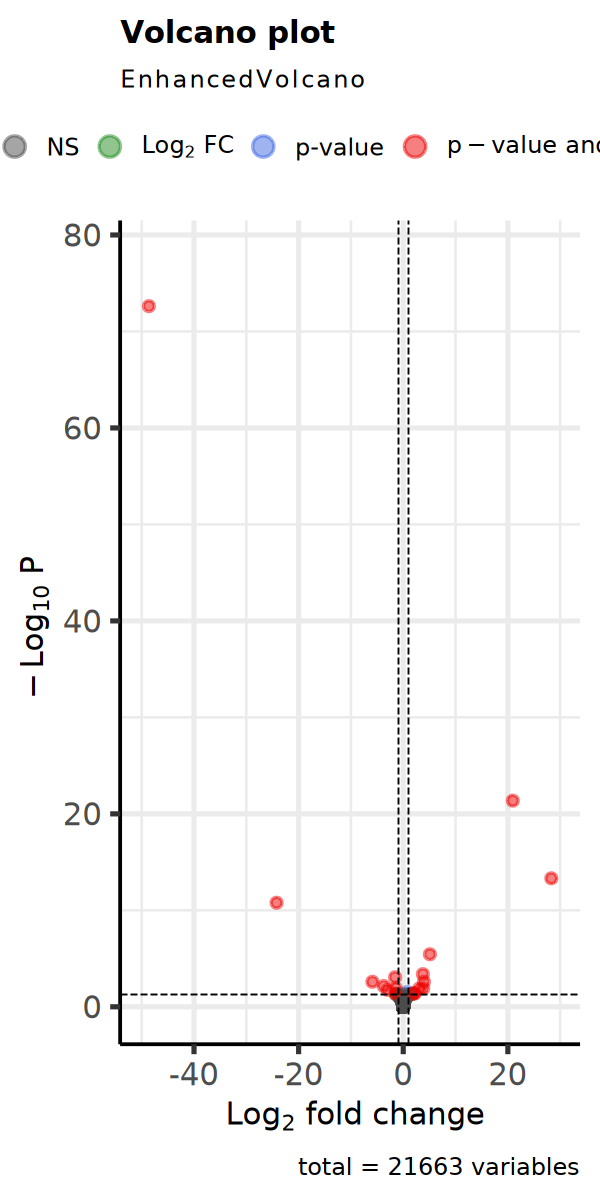

In [82]:
res.ww.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.ww.cw)

EnhancedVolcano(res.ww.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ww.cw <- merge(res.ww.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ww.cw)[1] <- 'Gene'

head(res.ww.cw)

In [83]:
write.csv(res.ww.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ww_cw.csv', row.names = FALSE)

**BB vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 17, 0.078%
LFC < 0 (down)     : 25, 0.12%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.271752e-05,0.006035214,0.9321180,0.9992642,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-5.254443e-04,0.046468523,0.6477461,0.9992642,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,3.539670e-04,0.046111227,0.7641106,0.9992642,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,2.551141e-05,0.005921843,0.8691614,0.9992642,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,2.108702e-04,0.006677427,0.2577534,0.9992642,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,8.635795e-05,0.009358012,0.6198315,0.9992642,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


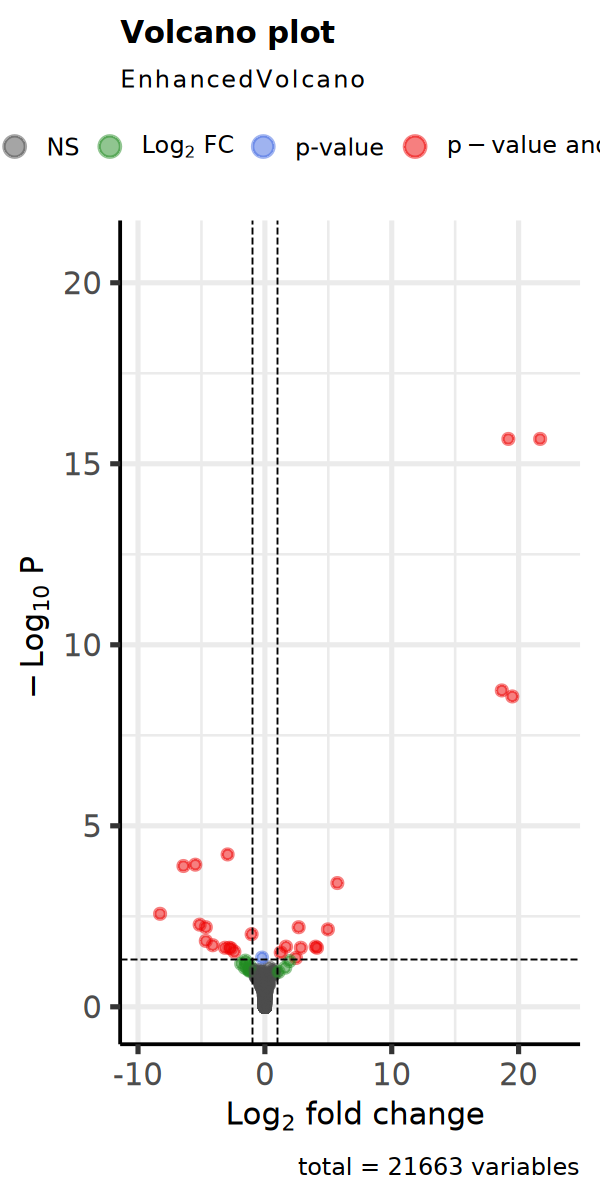

In [84]:
res.cb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_control.both_vs_both.both', # BB is the "control"
                       type = 'ashr')

summary(res.cb.bb)

EnhancedVolcano(res.cb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bb <- merge(res.cb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bb)[1] <- 'Gene'

head(res.cb.bb)

In [85]:
write.csv(res.cb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_bb.csv', row.names = FALSE)

#### 5B. Semi-matched priming: in context of later *single* stress
- CH vs. BH
- CW vs. BW

**CH vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 523, 2.4%
LFC < 0 (down)     : 300, 1.4%
outliers [1]       : 21, 0.097%
low counts [2]     : 420, 1.9%
(mean count < 14)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.02676810,0.1539703,0.781263377,0.9385414,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.03226182,0.2552781,0.392760412,0.7441444,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.04340572,0.2756597,0.252492977,0.6327082,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.11721285,0.1612510,0.250114790,0.6299473,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.32932870,0.1658054,0.005396708,0.1165895,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.07486430,0.2015620,0.402474945,0.7506216,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


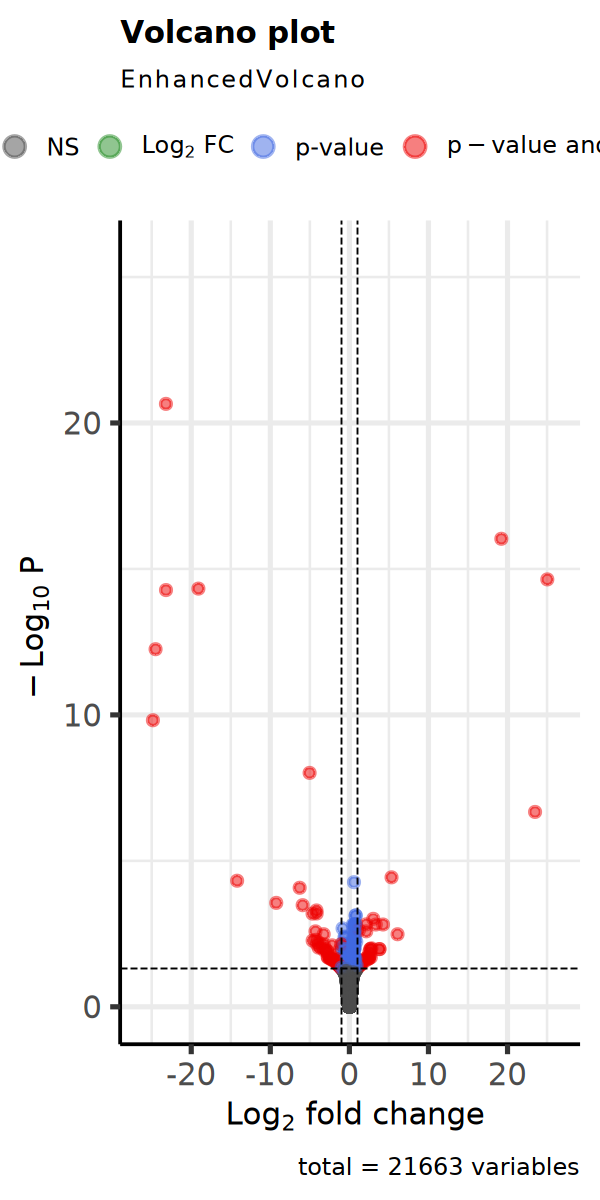

In [86]:
res.bh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.bh.ch)

EnhancedVolcano(res.bh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bh.ch <- merge(res.bh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bh.ch)[1] <- 'Gene'

head(res.bh.ch)

In [87]:
write.csv(res.bh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_ch.csv', row.names = FALSE)

**CW vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 17, 0.078%
LFC < 0 (down)     : 30, 0.14%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0024490762,0.04046132,0.7149696,0.9884170,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0044676302,0.10426790,0.2015291,0.8948327,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0027581738,0.08519144,0.3457300,0.9405225,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0046165846,0.04044669,0.5211910,0.9710091,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0049422256,0.04003069,0.5497389,0.9724459,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0002071788,0.04154250,0.9581520,0.9985754,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


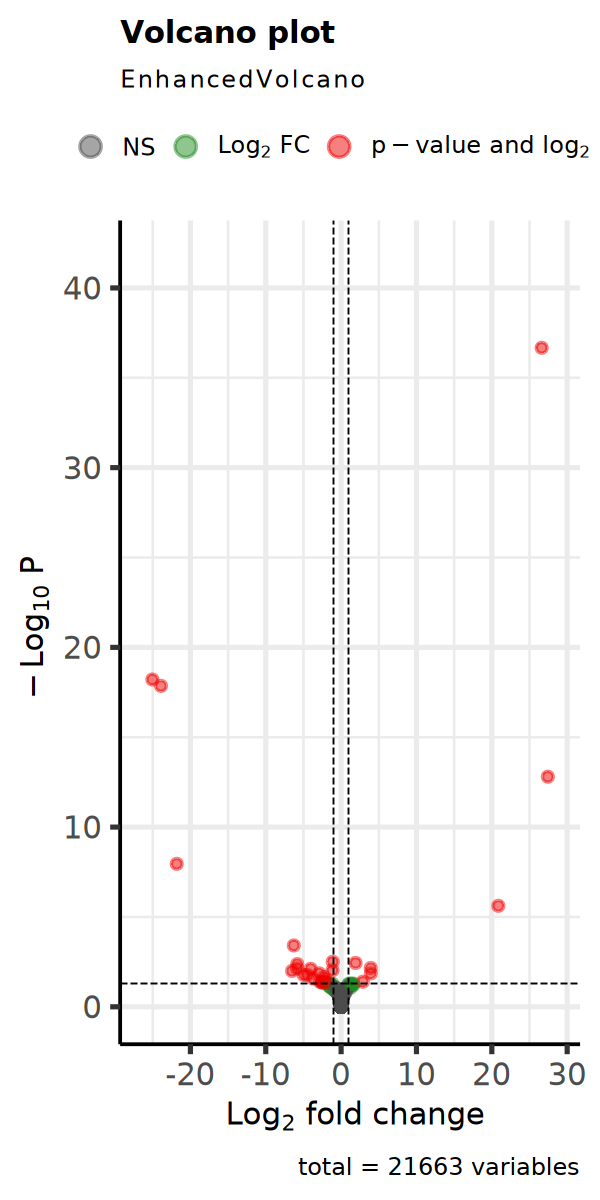

In [88]:
res.bw.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.bw.cw)

EnhancedVolcano(res.bw.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.cw <- merge(res.bw.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.cw)[1] <- 'Gene'

head(res.bw.cw)

In [89]:
write.csv(res.bw.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bw_cw.csv', row.names = FALSE)

#### 5C. Semi-matched priming: in context of later *multiple* stress
- CB vs. WB
- CB vs. HB

**CB vs. WB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 111, 0.51%
LFC < 0 (down)     : 39, 0.18%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,6.507197e-05,0.009557456,0.8598445,0.9975586,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,1.732938e-03,0.104789207,0.7903716,0.9952399,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,1.841029e-03,0.110993866,0.7917421,0.9952399,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-6.292859e-04,0.015219203,0.2336301,0.9142240,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-2.910044e-04,0.009597432,0.4393411,0.9737531,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,6.518025e-04,0.024045648,0.4755846,0.9801418,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


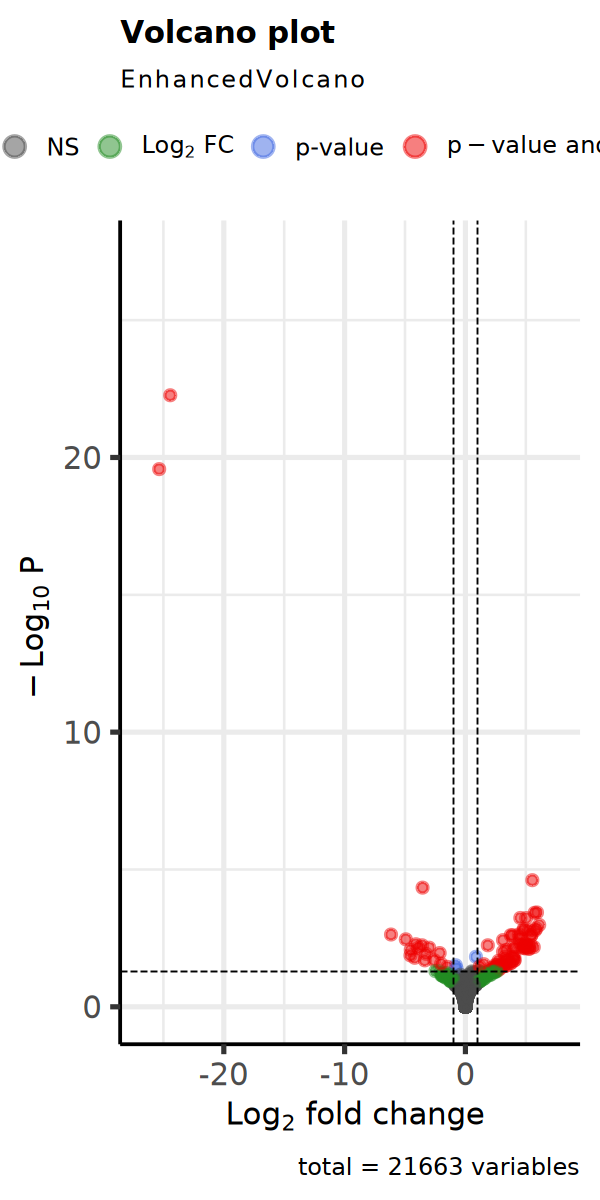

In [90]:
res.wb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.wb.cb)

EnhancedVolcano(res.wb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.cb <- merge(res.wb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.cb)[1] <- 'Gene'

head(res.wb.cb)

In [91]:
write.csv(res.wb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_cb.csv', row.names = FALSE)

**CB vs. HB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 22, 0.1%
LFC < 0 (down)     : 10, 0.046%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.108428e-04,0.006779683,0.5386494,0.9999089,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,2.668823e-04,0.035308366,0.7015719,0.9999089,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-6.344973e-05,0.034552759,0.9285605,0.9999089,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-8.734585e-05,0.006582763,0.6428004,0.9999089,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,3.212414e-05,0.006388600,0.8794101,0.9999089,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-4.679871e-05,0.008243952,0.7540099,0.9999089,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


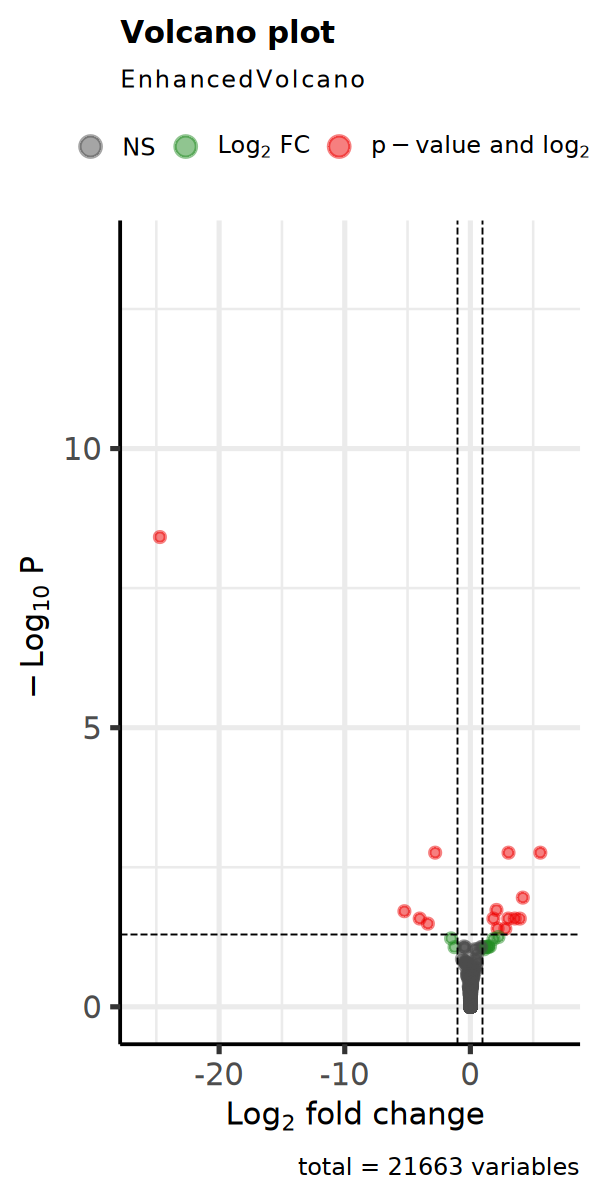

In [92]:
res.hb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.hb.cb)

EnhancedVolcano(res.hb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.cb <- merge(res.hb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.cb)[1] <- 'Gene'

head(res.hb.cb)

In [93]:
write.csv(res.hb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_cb.csv', row.names = FALSE)

### 6. Effect of initial exposure on subsequent response to stress
Oysters all experience the same early stressor, but either return to that stressor or experience control conditions
- HC vs. HH
- WC vs. WW
- BB vs. BC

**HC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 41, 0.19%
LFC < 0 (down)     : 44, 0.2%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0019703867,0.06797721,0.9132210,0.9939848,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0017393982,0.09673985,0.7476196,0.9836089,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0008529260,0.09735192,0.8731280,0.9898967,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0003326499,0.06752327,0.9862476,0.9989056,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0033702528,0.06645559,0.8775273,0.9908154,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0027788384,0.07053907,0.7978484,0.9862840,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


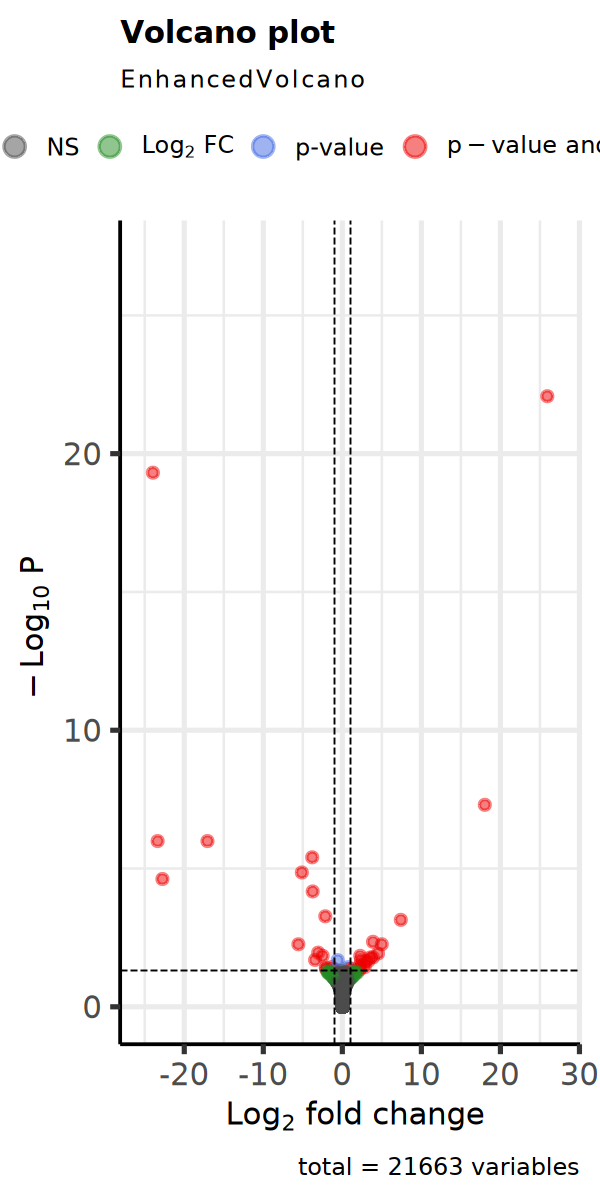

In [94]:
res.hc.hh <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.control', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hc.hh)

EnhancedVolcano(res.hc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.hh <- merge(res.hc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.hh)[1] <- 'Gene'

head(res.hc.hh)

In [95]:
write.csv(res.hc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hc_hh.csv', row.names = FALSE)

**WC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 30, 0.14%
LFC < 0 (down)     : 39, 0.18%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.030370171,0.1270494,0.6455527,0.9099161,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.015689745,0.1693039,0.3390998,0.7791807,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.001492036,0.1596513,0.9217141,0.9833517,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.065033784,0.1252054,0.3415874,0.7808561,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.072760557,0.1184259,0.3091554,0.7623659,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.017517447,0.1426958,0.7071202,0.9308038,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


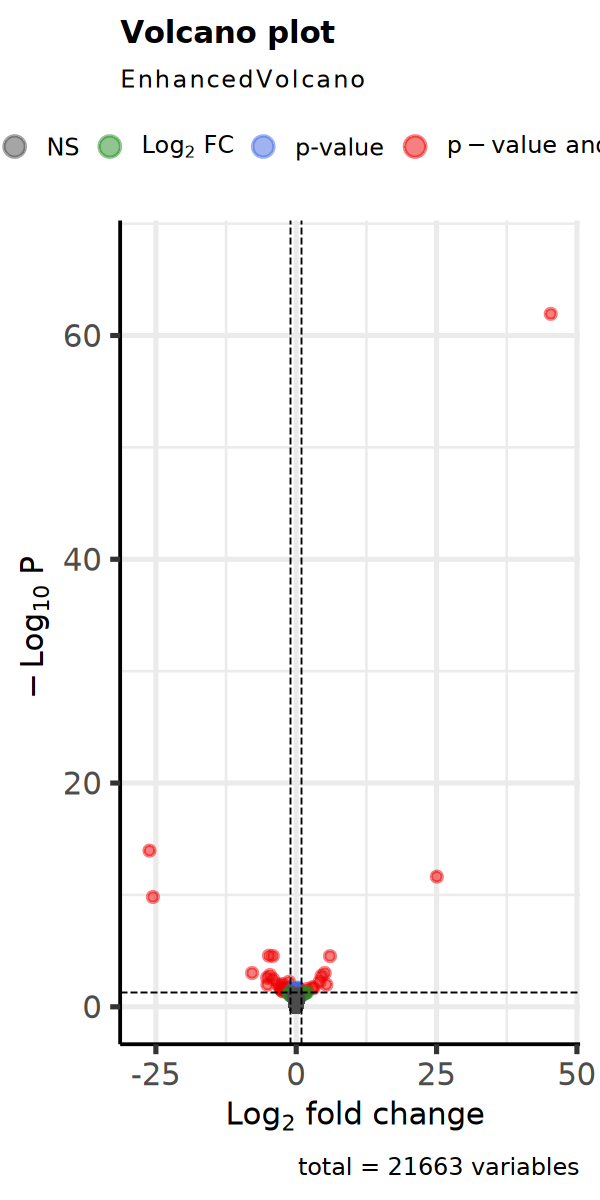

In [96]:
res.wc.ww <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.control', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.wc.ww)

EnhancedVolcano(res.wc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.ww <- merge(res.wc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.ww)[1] <- 'Gene'

head(res.wc.ww)

In [97]:
write.csv(res.wc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_ww.csv', row.names = FALSE)

**BC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 36, 0.17%
LFC < 0 (down)     : 150, 0.69%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.020602168,0.08461414,0.43066177,0.9342893,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.001126622,0.12689261,0.90639129,0.9933237,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.143845477,0.74105624,0.01248869,0.3353332,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.004818391,0.07883174,0.85404777,0.9911830,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.009090167,0.07567411,0.74543211,0.9839833,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.003890225,0.09070840,0.82770819,0.9902237,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


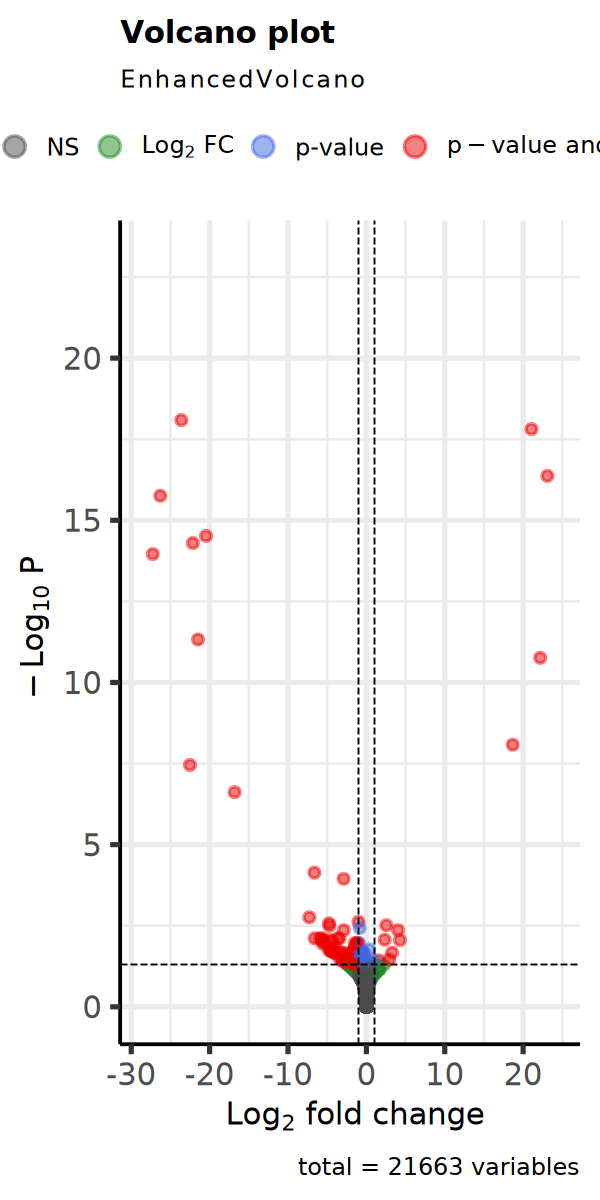

In [98]:
res.bc.bb <- lfcShrink(dds_rm, coef = 'complete_trtmt_both.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.bc.bb)

EnhancedVolcano(res.bc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.bb <- merge(res.bc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.bb)[1] <- 'Gene'

head(res.bc.bb)

In [99]:
write.csv(res.bc.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_bb.csv', row.names = FALSE)

### 7. Effect of initial single/multiple stress on response in ...
Is it better to be primed with a single stressor or multiple stressor, depending on the context of the future enviornment (single/multiple stressor)?

#### 7A. ...later *single* stress
Oyster is primed with either multiple or a single stressors, and then experiences only a sinlge stressor later
- BH vs. HH
- BW vs. WW

**BH vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 247, 1.1%
LFC < 0 (down)     : 143, 0.66%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.008540724,0.1498499,0.92248230,0.9846136,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.021432125,0.2216403,0.44085577,0.8222215,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.014770832,0.2190047,0.57707208,0.8784238,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.196031478,0.1674521,0.04959775,0.3920217,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.098739505,0.1424583,0.28103121,0.7174649,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.040968237,0.1833380,0.57199076,0.8771481,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


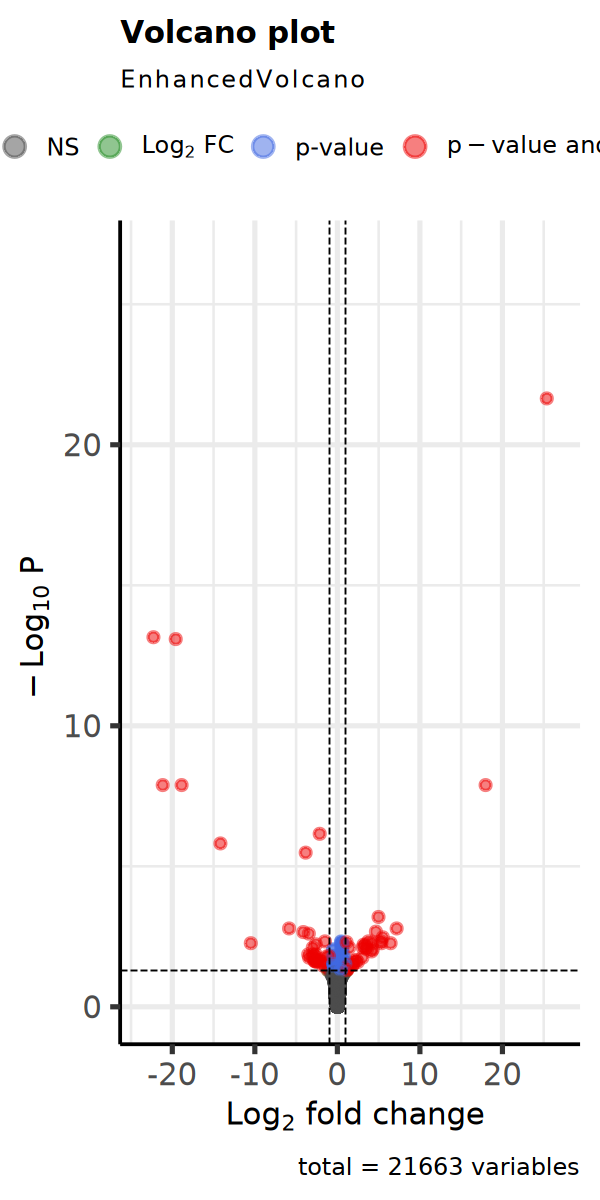

In [100]:
res.hh.bh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hh.bh)

EnhancedVolcano(res.hh.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.bh <- merge(res.hh.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.bh)[1] <- 'Gene'

head(res.hh.bh)

In [101]:
write.csv(res.hh.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_hh.csv', row.names = FALSE)

**BW vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 22, 0.1%
LFC < 0 (down)     : 39, 0.18%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.006081607,0.07092404,0.7682231,0.9805343,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.005589381,0.10795567,0.3077219,0.8870822,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.002078158,0.09196699,0.6650751,0.9667890,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.005081106,0.07034150,0.8166084,0.9834956,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.010607727,0.06900595,0.6673107,0.9675196,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.005876818,0.07381820,0.6368031,0.9615485,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


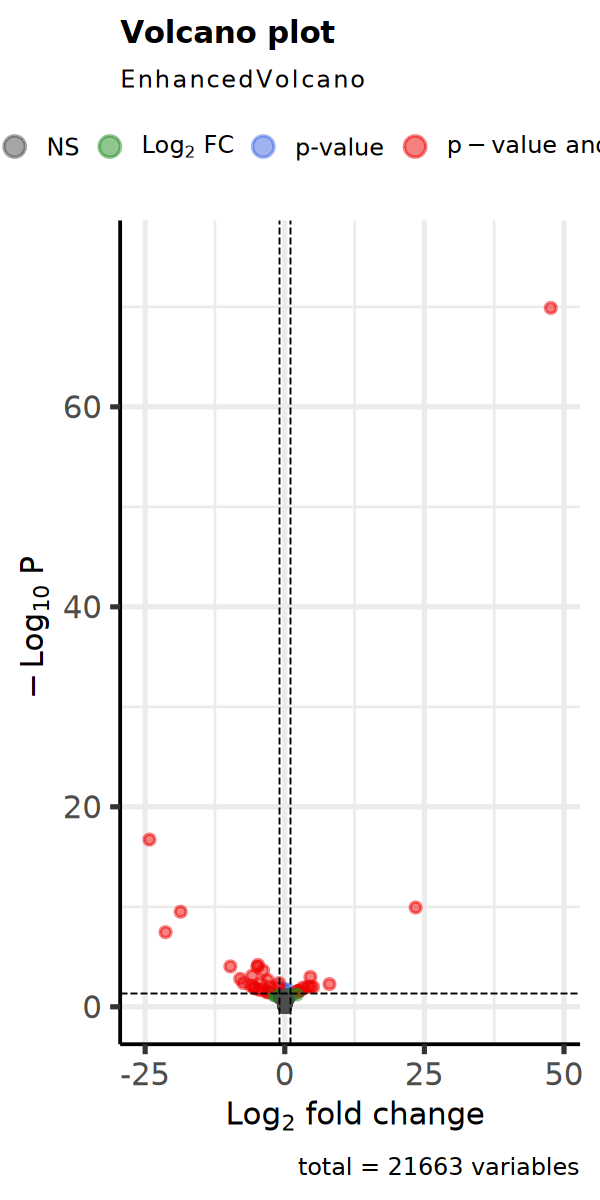

In [102]:
res.bw.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.bw.ww)

EnhancedVolcano(res.bw.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.ww <- merge(res.bw.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.ww)[1] <- 'Gene'

head(res.bw.ww)

In [103]:
write.csv(res.bw.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bw_ww.csv', row.names = FALSE)

#### 7B. ...later *multiple* stressors
Oyster is primed with either multiple or a single stressors, and then experiences multiple stressors later
- HB vs. BB
- WB vs. BB

**HB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 25, 0.12%
LFC < 0 (down)     : 23, 0.11%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.354749e-04,0.007461226,0.4838953,0.9999581,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.206224e-04,0.051194365,0.9412566,0.9999581,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,3.715461e-04,0.055279708,0.8333396,0.9999581,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-5.445562e-05,0.006486102,0.7647736,0.9999581,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,3.003761e-04,0.008384417,0.1993566,0.9999581,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,4.522505e-05,0.010547830,0.8554029,0.9999581,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


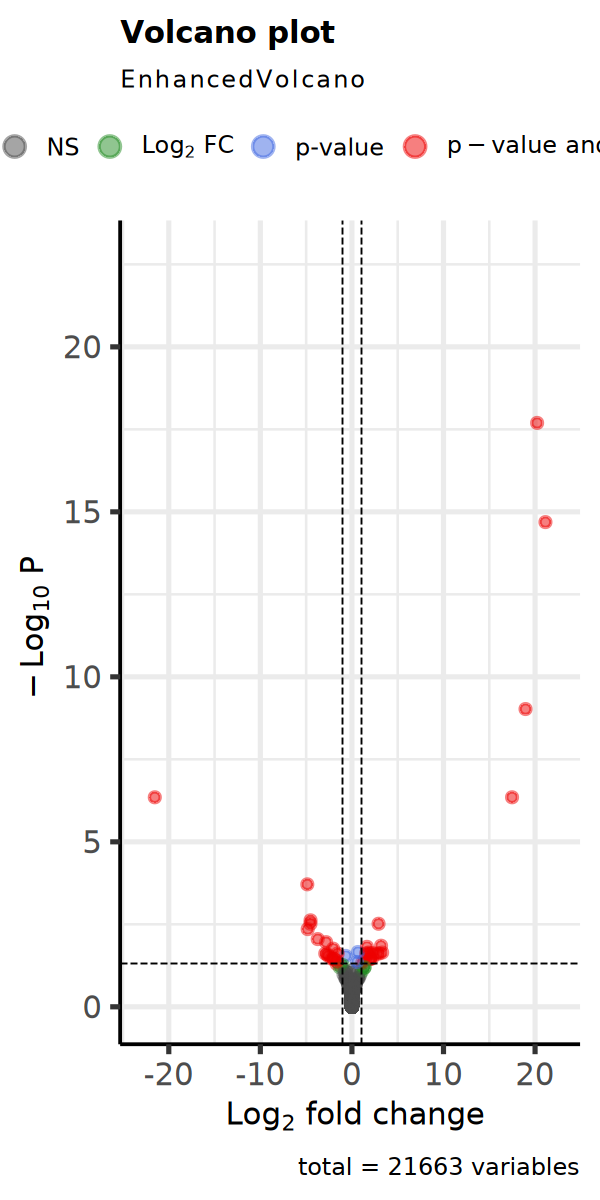

In [104]:
res.hb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_hypoxic.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.hb.bb)

EnhancedVolcano(res.hb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bb <- merge(res.hb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bb)[1] <- 'Gene'

head(res.hb.bb)

In [105]:
write.csv(res.hb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_bb.csv', row.names = FALSE)

**WB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 25, 0.12%
LFC < 0 (down)     : 19, 0.088%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,1.905467e-05,0.007132624,0.9271692,0.9999898,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-2.782394e-04,0.048885864,0.8484753,0.9999898,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,9.822700e-04,0.060397662,0.5726631,0.9999898,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-2.478328e-04,0.008354804,0.3046327,0.9999898,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,8.483791e-05,0.006805234,0.7200575,0.9999898,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,4.608550e-04,0.018663901,0.2264801,0.9999898,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


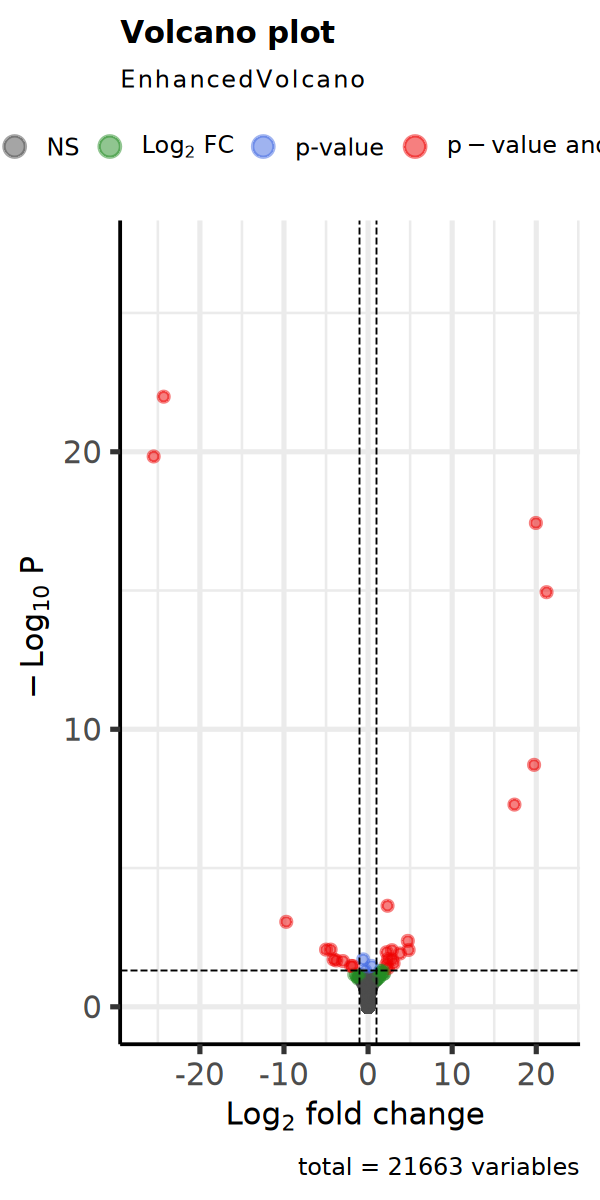

In [106]:
res.wb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_warm.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.wb.bb)

EnhancedVolcano(res.wb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bb <- merge(res.wb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bb)[1] <- 'Gene'

head(res.wb.bb)

In [107]:
write.csv(res.wb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_bb.csv', row.names = FALSE)

### 8. Shared/Unique responses among stressors with ...

#### 8A. ...different *early* stressors
>can compare these with the phase 1 vs. phase 1 DEGs to see if there are similarities
- WC vs. HC: single early stress
- BC vs. HC: mulitple vs. single
- BC vs. WC: multiple vs. single

**WC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 15, 0.069%
LFC < 0 (down)     : 11, 0.051%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,2.118437e-04,0.007781731,0.3266992,0.9999483,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,5.921031e-04,0.043648154,0.4950783,0.9999483,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.254925e-05,0.035989075,0.9870309,0.9999483,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.098033e-04,0.007080234,0.6131578,0.9999483,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,4.288855e-05,0.006853811,0.8602371,0.9999483,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.930646e-04,0.011347339,0.3459064,0.9999483,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


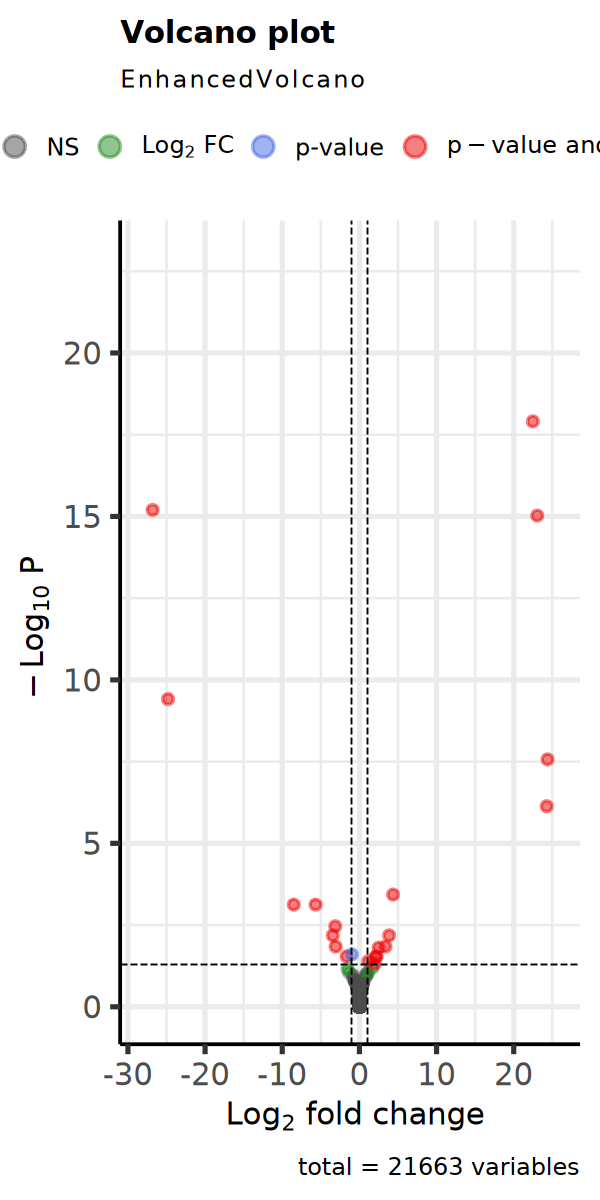

In [108]:
res.wc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.wc.hc)

EnhancedVolcano(res.wc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.hc <- merge(res.wc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.hc)[1] <- 'Gene'

head(res.wc.hc)

In [109]:
write.csv(res.wc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_hc.csv', row.names = FALSE)

**BC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 9, 0.042%
LFC < 0 (down)     : 16, 0.074%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,6.605955e-06,0.006705858,0.97005140,0.9998505,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,7.725233e-04,0.051260812,0.14642406,0.9998505,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.919376e-03,0.088068770,0.06740007,0.9998505,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.812408e-05,0.006688564,0.92372625,0.9998505,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,2.646291e-05,0.006662487,0.90417064,0.9998505,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-1.658248e-05,0.007111536,0.88020395,0.9998505,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


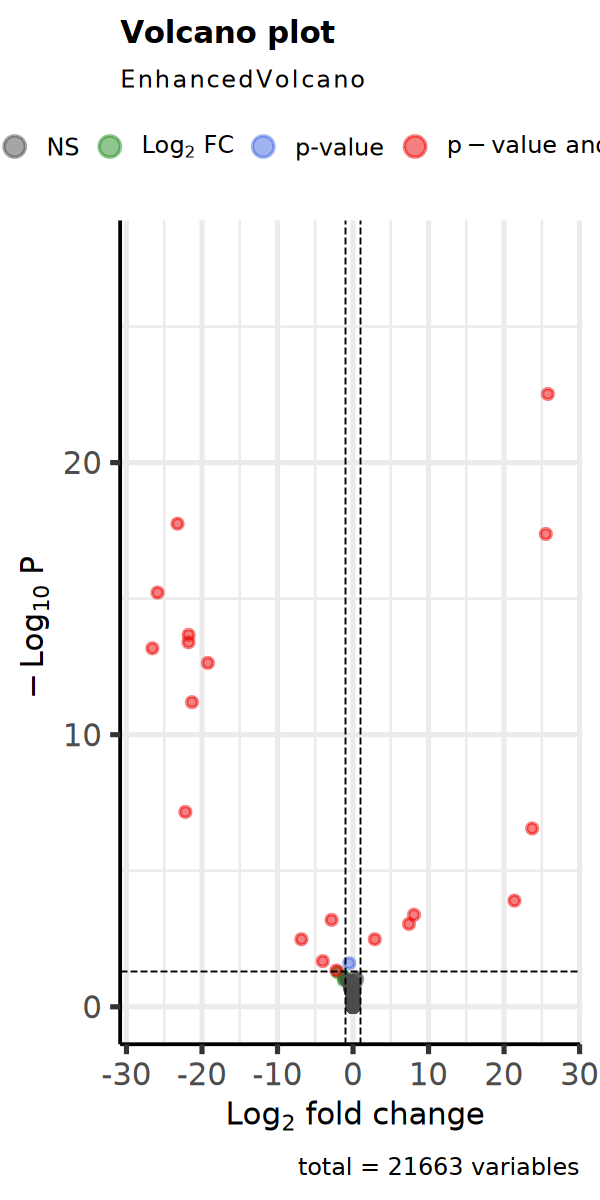

In [110]:
res.bc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.bc.hc)

EnhancedVolcano(res.bc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.hc <- merge(res.bc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.hc)[1] <- 'Gene'

head(res.bc.hc)

In [111]:
write.csv(res.bc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_hc.csv', row.names = FALSE)

**BC vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 21, 0.097%
LFC < 0 (down)     : 68, 0.31%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-2.159682e-04,0.008659702,0.36937961,0.9998784,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,1.753315e-03,0.075805240,0.42267653,0.9998784,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.395631e-02,0.230713879,0.06975161,0.9998784,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,8.868438e-05,0.007462158,0.69920909,0.9998784,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-1.180643e-05,0.007086065,0.96212450,0.9998784,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-3.564862e-04,0.016627070,0.29400268,0.9998784,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


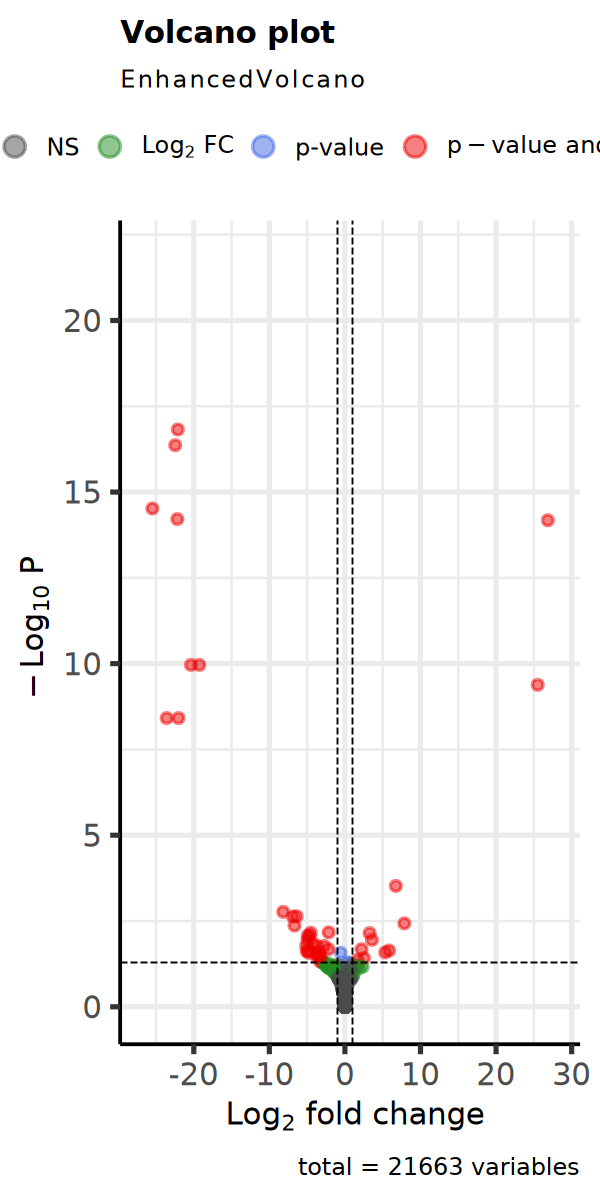

In [112]:
res.bc.wc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.bc.wc)

EnhancedVolcano(res.bc.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.wc <- merge(res.bc.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.wc)[1] <- 'Gene'

head(res.bc.wc)

In [113]:
write.csv(res.bc.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_wc.csv', row.names = FALSE)

#### 8B. ...different *late* stressors
- CW vs. CH: single early stress
- CB vs. CH: mulitple vs. single
- CB vs. CW: multiple vs. single

**CW vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 58, 0.27%
LFC < 0 (down)     : 34, 0.16%
outliers [1]       : 21, 0.097%
low counts [2]     : 420, 1.9%
(mean count < 14)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.0215418629,0.05877039,0.07559406,0.6788219,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.0165825628,0.20201524,0.13062485,0.7715031,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0071233495,0.13670308,0.34847377,0.9036851,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0038250377,0.05289367,0.75760360,0.9781086,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0162503171,0.05275673,0.25393038,0.8651842,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0008744154,0.05566891,0.90179852,0.9941217,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


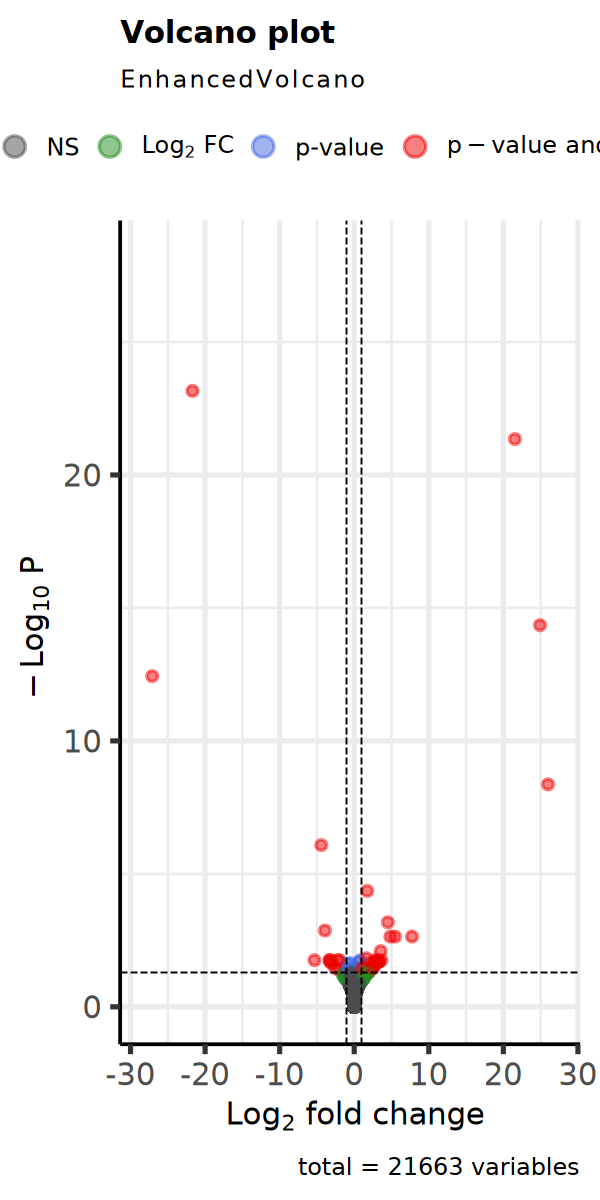

In [114]:
res.cw.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.warm', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cw.ch)

EnhancedVolcano(res.cw.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.ch <- merge(res.cw.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.ch)[1] <- 'Gene'

head(res.cw.ch)

In [115]:
write.csv(res.cw.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_ch.csv', row.names = FALSE)

**CB vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 45, 0.21%
LFC < 0 (down)     : 49, 0.23%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.032027131,0.08811473,0.295444901,0.8541211,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.005142792,0.12688458,0.576019792,0.9339026,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.126214838,0.67288380,0.010345404,0.3640573,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.024319968,0.08563489,0.445396325,0.9037299,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.114551889,0.11332106,0.006315112,0.2983820,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.001673244,0.09207345,0.931273120,0.9909821,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


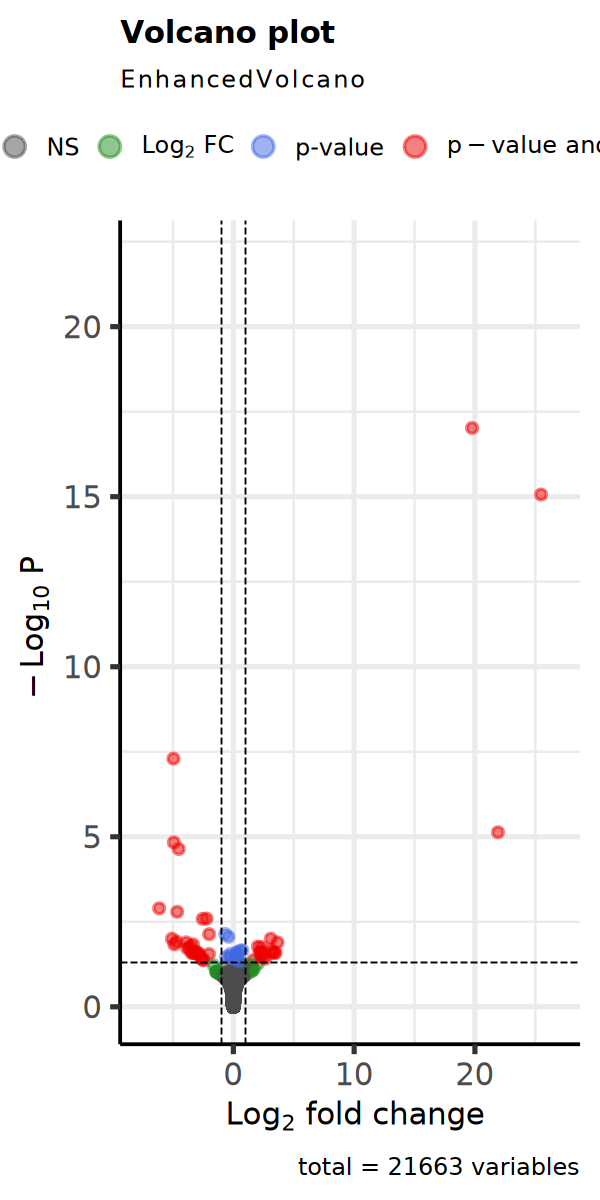

In [116]:
res.cb.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cb.ch)

EnhancedVolcano(res.cb.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.ch <- merge(res.cb.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.ch)[1] <- 'Gene'

head(res.cb.ch)

In [117]:
#write.csv(res.cb.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cb_ch.csv', row.names = FALSE)

**CB vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 63, 0.29%
LFC < 0 (down)     : 47, 0.22%
outliers [1]       : 21, 0.097%
low counts [2]     : 420, 1.9%
(mean count < 14)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0172679531,0.07649048,0.4650703,0.9070734,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0088630364,0.14065504,0.3408716,0.8764694,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0220977510,0.22759460,0.1032533,0.7248581,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0112971499,0.07506434,0.6496448,0.9486240,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0453754731,0.07740501,0.1118285,0.7374169,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0005620073,0.08133292,0.9703781,0.9955046,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


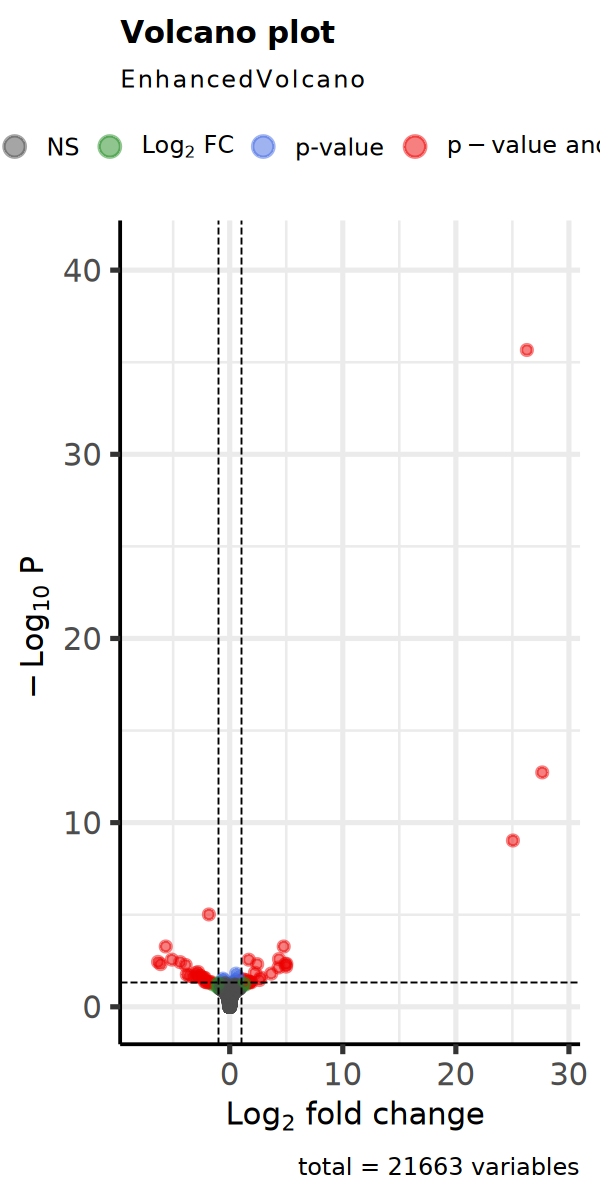

In [118]:
res.cb.cw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.cb.cw)

EnhancedVolcano(res.cb.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cw <- merge(res.cb.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cw)[1] <- 'Gene'

head(res.cb.cw)

In [119]:
#write.csv(res.cb.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cb_cw.csv', row.names = FALSE)

### 9. Effect of the order of stressors
Does the order of when stress is experienced matter? Maybe one stressor is an informative cue for a later environmnet?
- WH vs. HW
- WB vs. BW
- HB vs. BH

**WH vs. HW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 13, 0.06%
LFC < 0 (down)     : 19, 0.088%
outliers [1]       : 21, 0.097%
low counts [2]     : 840, 3.9%
(mean count < 18)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.0002161299,0.03491433,0.9655288,0.9968875,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0021714038,0.07701160,0.4774033,0.9796988,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0005046085,0.06897662,0.8569596,0.9917065,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0017079240,0.03464651,0.7438015,0.9865342,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0009919105,0.03269489,0.8572797,0.9917065,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0007303412,0.03971933,0.8395909,0.9917065,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


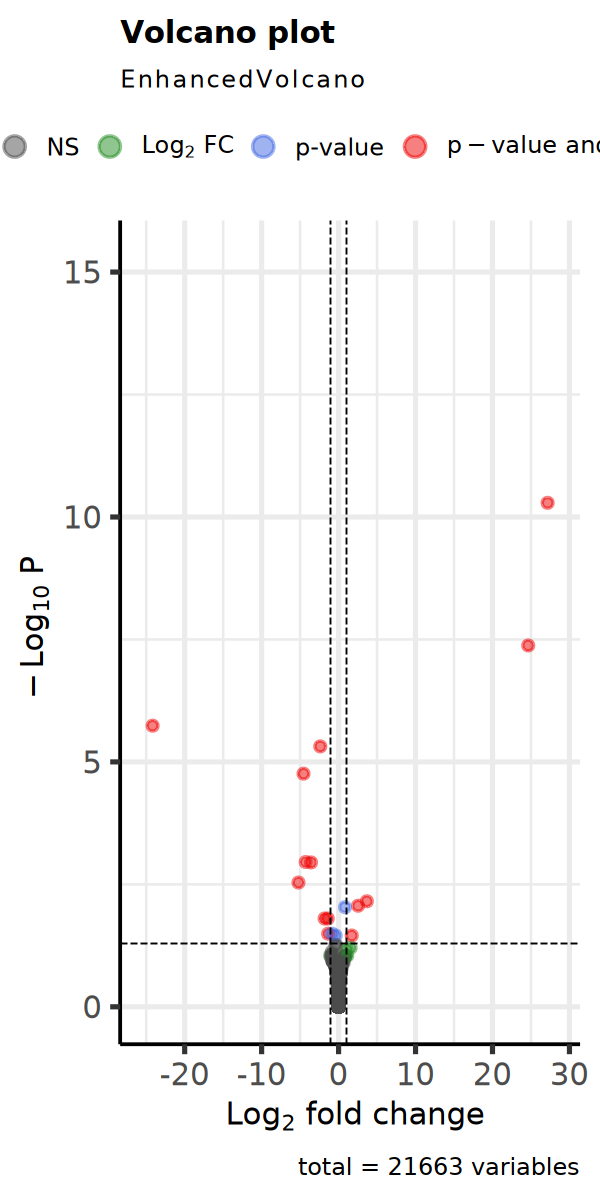

In [120]:
res.wh.hw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.hypoxic', 'hypoxic.warm'), # HW is the "control"
                     type = 'ashr')

summary(res.wh.hw)

EnhancedVolcano(res.wh.hw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wh.hw <- merge(res.wh.hw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wh.hw)[1] <- 'Gene'

head(res.wh.hw)

In [121]:
write.csv(res.wh.hw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wh_hw.csv', row.names = FALSE)

**WB vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 178, 0.82%
LFC < 0 (down)     : 67, 0.31%
outliers [1]       : 21, 0.097%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.007385231,0.09765136,0.8502892,0.9745328,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.008913562,0.16624268,0.5547910,0.8895893,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.016551956,0.20473791,0.3416965,0.8083273,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.003915671,0.09624186,0.9239485,0.9868279,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.064142892,0.09467302,0.1571113,0.6741085,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.018612343,0.10656601,0.4661471,0.8630432,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


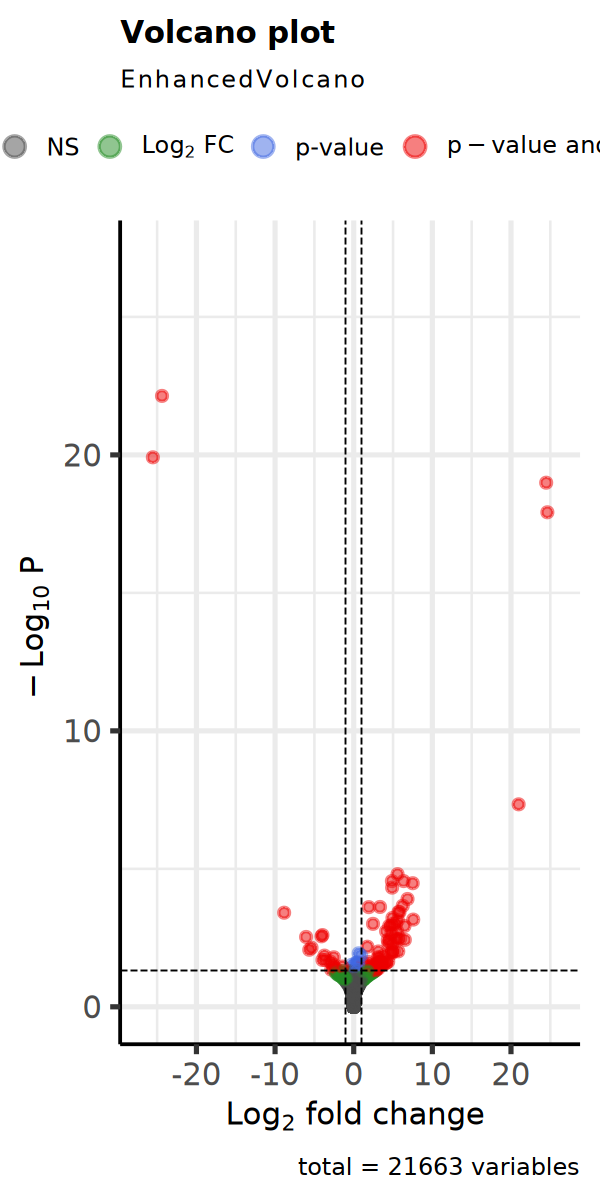

In [122]:
res.wb.bw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.both', 'both.warm'), # BW is the "control"
                     type = 'ashr')

summary(res.wb.bw)

EnhancedVolcano(res.wb.bw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bw <- merge(res.wb.bw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bw)[1] <- 'Gene'

head(res.wb.bw)

In [123]:
write.csv(res.wb.bw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_bw.csv', row.names = FALSE)

**HB vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 21663 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 335, 1.5%
LFC < 0 (down)     : 334, 1.5%
outliers [1]       : 21, 0.097%
low counts [2]     : 420, 1.9%
(mean count < 14)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.01428532,0.1508424,0.87816452,0.9759325,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.07776855,0.3789175,0.07234796,0.4063972,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.04646629,0.2885937,0.18271523,0.5895671,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.14261204,0.1559700,0.14780289,0.5443723,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.00921763,0.1331642,0.92022514,0.9834333,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.08329573,0.1885966,0.28778845,0.6918267,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


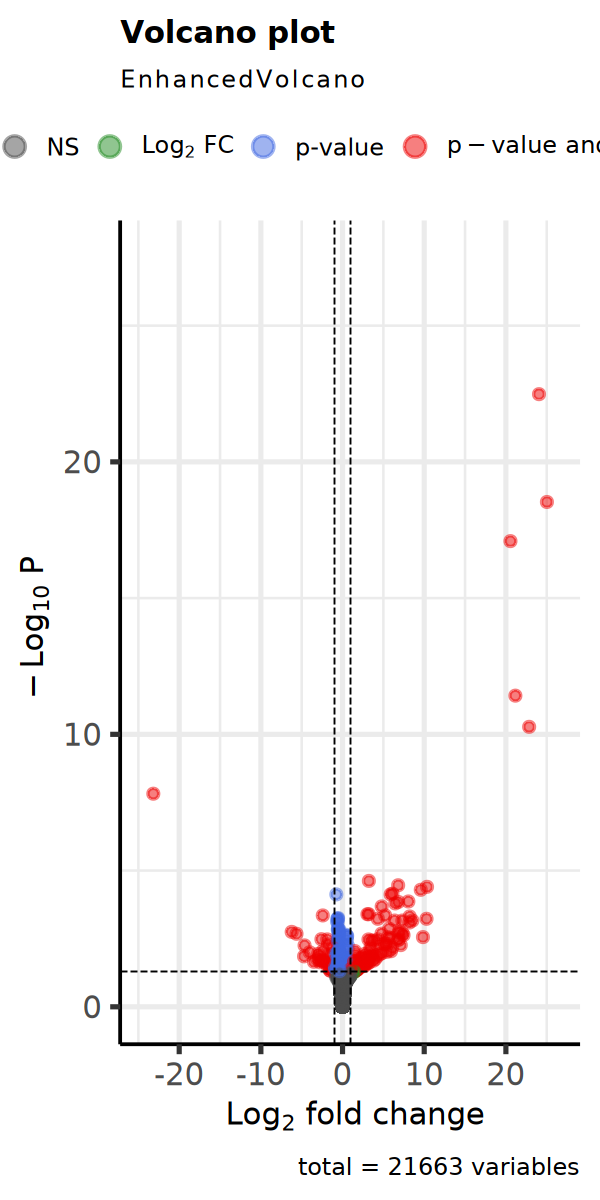

In [124]:
res.hb.bh <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'hypoxic.both', 'both.hypoxic'), # BH is the "control"
                     type = 'ashr')

summary(res.hb.bh)

EnhancedVolcano(res.hb.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bh <- merge(res.hb.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bh)[1] <- 'Gene'

head(res.hb.bh)

In [125]:
write.csv(res.hb.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_bh.csv', row.names = FALSE)

### temperature and DO treatments
looking at the effects of temperature and DO in an isolated manner

#### phase 1 temp
ambient vs. warm

regardless of phase 2 treatments or phase 1 DO

In [ ]:
design(dds_rm) <- ~ Phase1_temp
dds_p1temp <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



In [ ]:
p1_temp.res <- lfcShrink(dds_p1temp, contrast = c('Phase1_temp', 'warm', 'ambient'),
                     type = 'ashr')

summary(p1_temp.res)

EnhancedVolcano(p1_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_temp.res <- merge(p1_temp.res, counts(dds_p1temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_temp.res)[1] <- 'Gene'

head(p1_temp.res)

In [ ]:
as.data.frame(p1_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 14 DEGs

In [ ]:
write.csv(p1_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_temp.csv', row.names = FALSE)

#### phase 1 DO
normoxic vs. hypoxic

In [ ]:
design(dds_rm) <- ~ Phase1_DO
dds_p1DO <- DESeq(dds_rm)

In [ ]:
p1_DO.res <- lfcShrink(dds_p1DO, contrast = c('Phase1_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p1_DO.res)

EnhancedVolcano(p1_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_DO.res <- merge(p1_DO.res, counts(dds_p1DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_DO.res)[1] <- 'Gene'

head(p1_DO.res)

a couple more DEGs, but still not a ton - to be expected, since we think GE is more short term

In [ ]:
as.data.frame(p1_DO.res) %>%
filter(abs(log2FoldChange) >= 1 & padj <= 0.05) %>%
dim()

# 12 DEGs

In [ ]:
write.csv(p1_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_DO.csv', row.names = FALSE)

#### phase 2 temp
ambient vs. warm

regardless of phase 1 treatments or phase 2 DO

In [ ]:
design(dds_rm) <- ~ Phase2_temp
dds_p2temp <- DESeq(dds_rm)

In [ ]:
p2_temp.res <- lfcShrink(dds_p2temp, contrast = c('Phase2_temp', 'warm', 'ambient'), 
                     type = 'ashr')

summary(p2_temp.res)

EnhancedVolcano(p2_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_temp.res <- merge(p2_temp.res, counts(dds_p2temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_temp.res)[1] <- 'Gene'

head(p2_temp.res)

In [ ]:
as.data.frame(p2_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 80 DEGs!

In [ ]:
write.csv(p2_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_temp.csv', row.names = FALSE)

#### phase 2 DO
normoxic vs. hypoxic

regardless of phase 1 treatments or phase 2 temperatures

In [ ]:
design(dds_rm) <- ~ Phase2_DO
dds_p2DO <- DESeq(dds_rm)

In [ ]:
p2_DO.res <- lfcShrink(dds_p2DO, contrast = c('Phase2_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p2_DO.res)

EnhancedVolcano(p2_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_DO.res <- merge(p2_DO.res, counts(dds_p2DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_DO.res)[1] <- 'Gene'

head(p2_DO.res)

In [ ]:
as.data.frame(p2_DO.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 29 DEGs!

In [ ]:
write.csv(p2_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_DO.csv', row.names = FALSE)

# I STOPPED HERE

### nMDS of only significant DEGs from isolated treatments

shouldn't matter which DESeq function I run, since we only need vst which is the normalized expression - should return the same numbers/counts 

In [146]:
# variance stabilizing transformation
vsd <- vst(dds.noOutliers) # from full DESeq function, without the 2 outlier samples
head(assay(vsd))

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'nrow': object 'dds.noOutliers' not found


get list of DEGs identified in the 'isolated' treatments (otherwise, there's just a million DEGs)

In [42]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "p1_DO"   "p1_temp" "p2_DO"   "p2_temp"

In [43]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::filter(padj < 0.05 & abs(log2FoldChange) > 1) %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 290 total DEGs
head(all_degs)

[1] 265

[1] "LOC111104012" "LOC111102592" "LOC144624804" "LOC144625490" "LOC144625901"
[6] "LOC111101301"

In [44]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 290 total DEGs kept
head(degs_vsd) 

[1] 265  94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111102506,10.380840,9.560323,13.467640,9.095155,10.970108,8.935006,9.062335,10.197227,11.499914,9.047712,⋯,9.050487,9.415516,9.525608,10.696301,9.276084,9.537034,10.351851,9.426189,9.549025,9.346426
LOC111103173,8.347567,8.247518,8.279739,8.161861,8.161861,8.321493,8.161861,8.161861,8.161861,8.995706,⋯,8.161861,8.161861,8.161861,8.471088,8.304568,8.161861,8.291656,8.161861,8.339826,8.338495
LOC111103490,12.325820,13.319562,13.893435,11.230966,12.825426,12.065763,12.362042,11.998235,11.651213,10.530309,⋯,11.425075,10.593363,11.145859,11.228763,12.027792,11.018941,12.625862,11.607018,11.498946,13.141607
LOC144622059,8.327985,8.876399,8.245225,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,⋯,10.237259,8.161861,8.296431,8.283347,8.161861,8.161861,9.787217,8.161861,8.161861,10.179552
LOC111105131,8.396666,8.403887,8.867176,8.300329,8.694998,8.367875,8.454862,8.161861,8.531140,8.403151,⋯,9.441800,8.440138,8.161861,8.161861,8.161861,8.314577,9.782977,8.161861,8.161861,8.610659
LOC111104543,8.161861,8.445538,8.524332,8.321730,8.619704,8.572847,8.438158,8.161861,8.161861,8.161861,⋯,9.320533,8.161861,8.161861,8.404617,8.422161,8.314577,8.779810,8.161861,8.161861,10.026920


In [45]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,12.575673,16.82096,12.932864,18.58007,12.594205,14.322617,12.745796,11.877148,14.74850,⋯,27.36305,12.869791,12.07491,13.119530,12.501106,11.169574,25.15713,12.550227,13.346193,29.06447
B1_W5_O50,12.57567,0.000000,14.84429,8.567808,15.52108,8.574989,7.974597,8.088239,8.893891,12.04086,⋯,23.28776,9.808964,10.29981,8.776904,10.301848,9.748675,23.38100,9.719817,9.762422,24.77291
B2_B5_O51,16.82096,14.844288,0.00000,17.181774,16.99998,15.616050,14.885430,15.458491,16.149148,18.88176,⋯,22.43185,17.067327,17.58493,14.626084,16.882472,16.532962,21.64151,16.288461,16.925990,24.29982
B2_C4_O40,12.93286,8.567808,17.18177,0.000000,18.24160,8.873988,11.237758,9.261132,10.947797,10.92293,⋯,25.83020,9.409984,10.18547,9.371928,8.983627,9.903190,25.75128,8.394751,7.448790,27.16068
B3_B4_O41,18.58007,15.521084,16.99998,18.241597,0.00000,17.531613,16.313913,18.262602,17.093566,20.59936,⋯,17.40215,19.204303,19.46881,16.970775,19.212475,17.971481,15.06084,17.577956,18.698433,17.14160
B3_C3_O30,12.59420,8.574989,15.61605,8.873988,17.53161,0.000000,9.610107,10.058257,9.934005,12.57127,⋯,25.32502,10.679681,10.31777,9.091426,11.205199,9.598842,25.16273,9.570942,10.089753,26.92753


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>
B1_B1_O01,3.7145466,2.5912620,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0522133
B1_W5_O50,0.7497815,0.6554000,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9902207
B2_B5_O51,-4.1042118,5.1527838,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0454603
B2_C4_O40,3.6180568,-2.3523123,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1362472
B3_B4_O41,-9.8654563,-2.7231799,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8595069
B3_C3_O30,3.0588292,-0.1253456,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8547230


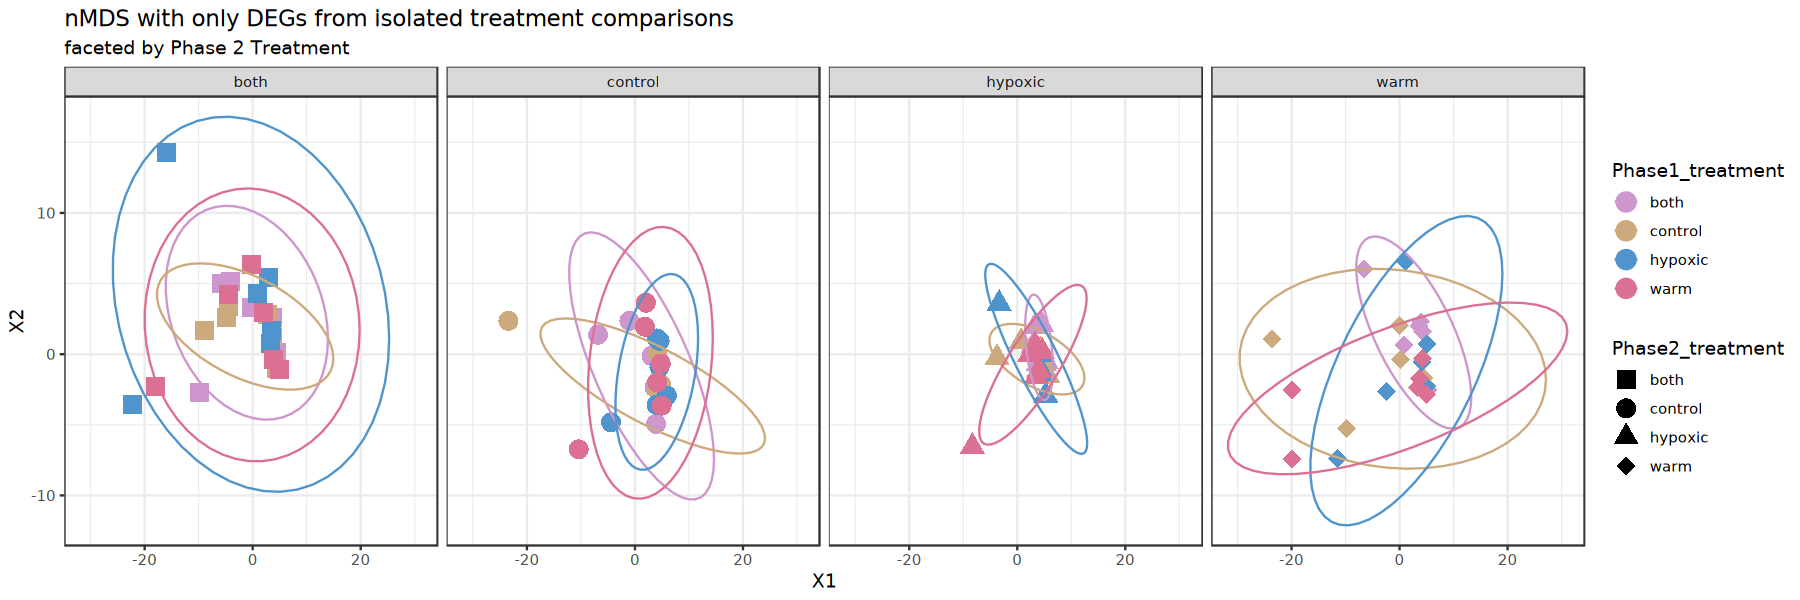

In [46]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 Treatment') + 
theme_bw()

nmds.plot

see less dispersion in phase 2 control and hypoxic (so ambient) samples compared to both and warm (so warm) samples 

this makes sense, as I've seen phase 2 temperature being a bigger driver for differential expression

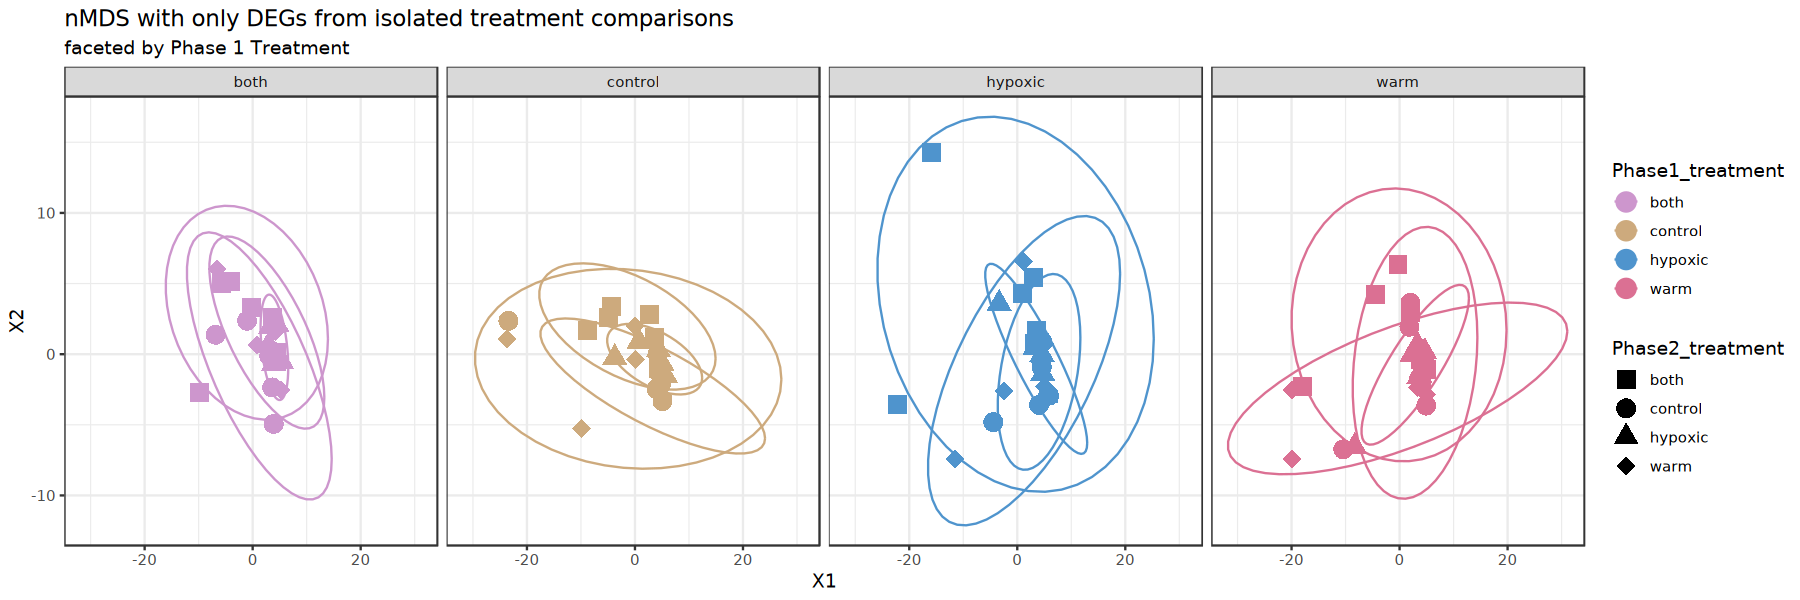

In [47]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 1 Treatment') + 
theme_bw()

nmds.plot

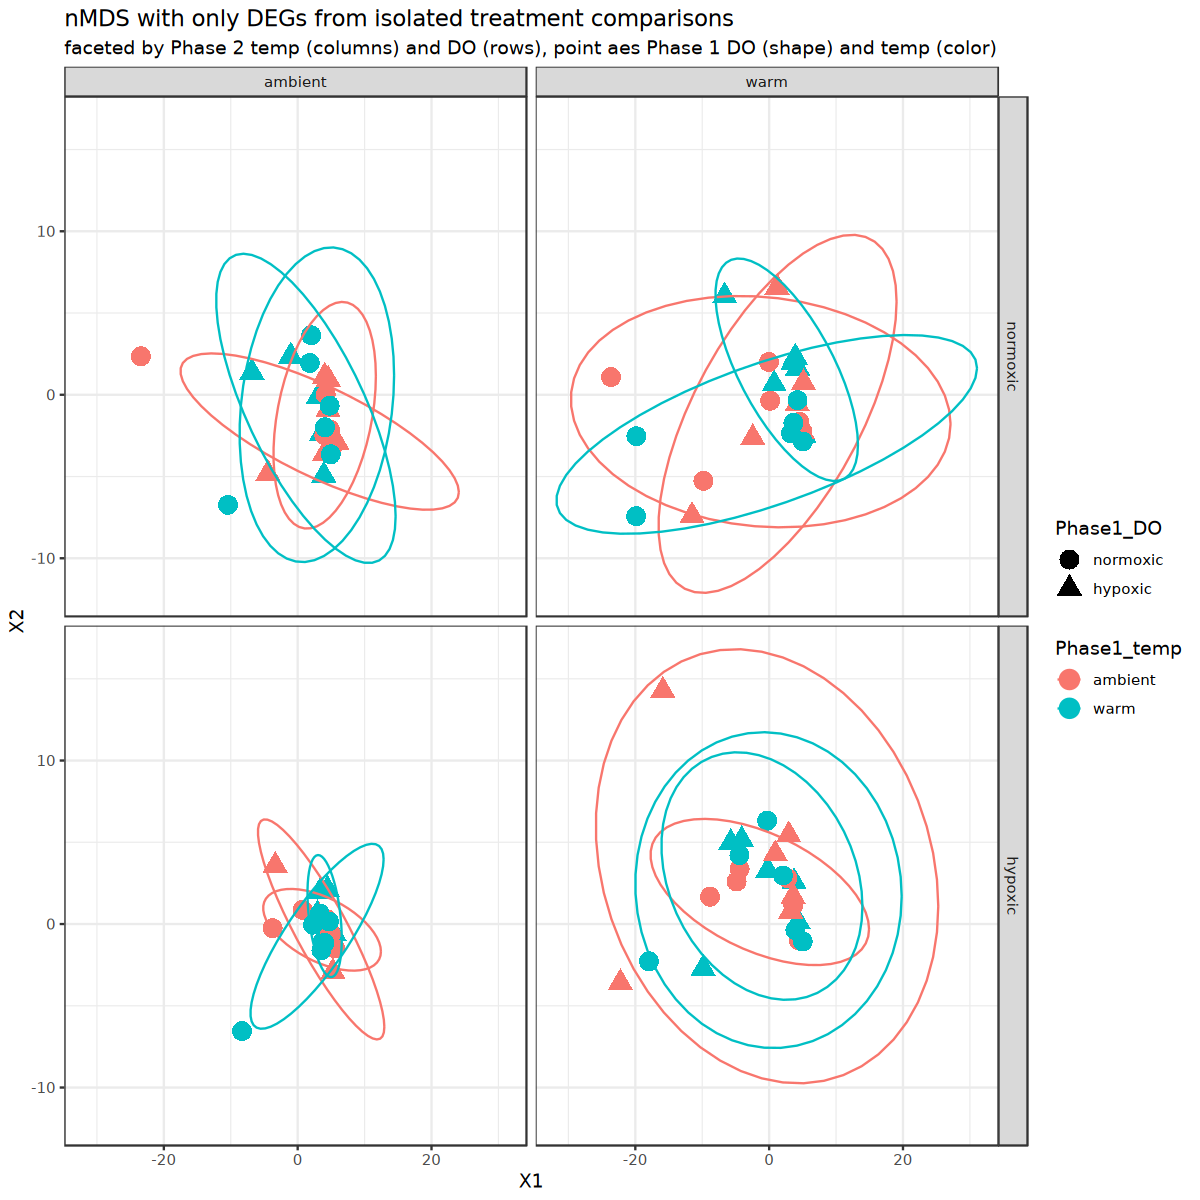

In [48]:
options(repr.plot.width = 10, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
facet_grid(Phase2_DO~Phase2_temp) + 
stat_ellipse() + 
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 temp (columns) and DO (rows), point aes Phase 1 DO (shape) and temp (color)') + 
theme_bw()

nmds.plot

#### permanova for DEGs

In [49]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,66.09649,0.005232892,0.4968288,0.965
Phase1_DO,1,158.03661,0.012511838,1.1879171,0.260
Phase2_temp,1,612.46338,0.048489033,4.6037161,0.001
Phase2_DO,1,370.63484,0.029343346,2.7859585,0.023
Phase1_temp:Phase1_DO,1,84.56534,0.006695080,0.6356540,0.771
Phase1_temp:Phase2_temp,1,73.88016,0.005849130,0.5553365,0.886
Phase1_DO:Phase2_temp,1,63.09464,0.004995235,0.4742648,0.970
Phase1_temp:Phase2_DO,1,69.30171,0.005486651,0.5209216,0.926
Phase1_DO:Phase2_DO,1,140.79844,0.011147083,1.0583425,0.321


only significant effects from Phase2_temp and Phase2_DO - so most recent stressors

### nMDS of any DEG identified in all pairwise comparisons

In [16]:
# variance stabilizing transformation
vsd <- vst(dds.noOutliers) # from full DESeq function, without the 2 outlier samples
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111116054,7.692872,7.805746,7.871959,7.843091,7.548551,7.909124,7.947895,7.869635,7.840134,7.758281,⋯,7.767900,7.713596,7.900466,7.697844,7.834121,7.790482,7.708399,8.030152,7.657898,7.548551
LOC111126949,10.197580,9.653169,9.900281,9.718856,9.612738,9.545333,9.334530,9.803992,9.906070,9.592360,⋯,9.078093,9.779869,9.712370,10.082883,9.950378,9.563392,9.665533,9.644851,9.276775,9.929224
LOC111110729,8.354765,8.542687,8.351593,8.513945,8.518601,8.653091,8.816678,8.937210,8.568640,8.590933,⋯,8.714150,8.368627,8.514299,8.798284,8.635108,8.680883,8.780214,8.673395,8.746416,9.064164
LOC111112434,7.886383,7.697174,7.548551,7.687586,7.940109,7.989592,7.818256,8.186828,7.658920,7.879728,⋯,7.817069,7.548551,7.937395,7.806904,7.750644,7.548551,7.708399,7.990820,7.857315,7.548551
LOC111120752,9.363550,9.355360,9.509373,9.284512,9.198871,9.337765,9.699834,9.473806,8.989457,9.167603,⋯,9.549481,9.234610,9.599548,9.383933,9.510347,9.253648,9.345876,9.627837,9.412129,9.619853
LOC111128944,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,⋯,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551


get list of DEGs identified in the 'isolated' treatments (otherwise, there's just a million DEGs)

In [45]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/DEGs/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "DEG_bb_cc" "DEG_bc_bb" "DEG_bc_cc" "DEG_bc_hc" "DEG_bc_wc" "DEG_bh_ch"
 [7] "DEG_bh_hh" "DEG_bw_cw" "DEG_bw_ww" "DEG_cb_bb" "DEG_cb_bc" "DEG_cb_cc"
[13] "DEG_cb_ch" "DEG_cb_cw" "DEG_ch_cc" "DEG_ch_hc" "DEG_cw_cc" "DEG_cw_ch"
[19] "DEG_cw_wc" "DEG_hb_bb" "DEG_hb_bh" "DEG_hb_cb" "DEG_hc_cc" "DEG_hc_hh"
[25] "DEG_hh_cc" "DEG_hh_ch" "DEG_wb_bb" "DEG_wb_bw" "DEG_wb_cb" "DEG_wc_cc"
[31] "DEG_wc_hc" "DEG_wc_ww" "DEG_wh_hw" "DEG_ww_cc" "DEG_ww_cw"

In [46]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 2263 total DEGs
head(all_degs)

[1] 2263

[1] "LOC111134671" "LOC111120923" "LOC111136853" "LOC111120760" "LOC111107221"
[6] "LOC111125595"

In [47]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 2263 total DEGs kept
head(degs_vsd) 

[1] 2263   94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111105691,7.692872,7.845404,8.595408,8.101515,8.014009,8.149132,7.757585,8.212449,7.704598,7.805305,⋯,7.703729,7.713596,7.859081,7.548551,8.010013,7.736037,7.905257,8.416445,7.997691,7.548551
LOC111109550,8.131067,7.805746,8.743886,7.928364,7.708812,7.803846,8.159885,8.674840,7.704598,7.653485,⋯,7.985994,8.626921,7.714765,8.881685,10.092835,8.251878,9.960122,8.017421,8.058891,8.520289
LOC111102585,7.798315,8.004935,8.306724,8.475852,8.355585,7.548551,8.803914,7.948558,7.704598,7.758281,⋯,8.794420,7.817824,7.666114,8.234621,7.898017,7.548551,10.227302,8.077917,7.875967,9.296881
LOC111129522,7.548551,8.120664,7.887674,8.066193,8.144263,7.926626,8.494087,7.548551,7.860191,7.782985,⋯,8.094194,7.548551,9.987741,7.697844,9.097456,7.872833,8.173305,7.898706,7.857315,8.129922
LOC111119645,11.013693,8.101502,11.484225,8.037954,7.548551,7.776953,7.774301,7.548551,7.704598,7.696918,⋯,9.367806,7.951734,7.811141,8.938418,8.740486,7.854358,7.825135,7.976880,8.123486,8.262219
LOC111129878,7.650623,7.548551,7.871959,7.952738,7.661902,7.776953,7.919830,7.548551,7.548551,7.653485,⋯,7.548551,7.548551,7.880431,7.806904,7.795962,7.656847,7.661610,7.931939,7.816075,7.548551


In [48]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,46.43361,45.73539,43.84645,49.73550,44.43556,47.39553,43.74362,46.22663,41.88886,⋯,57.89188,42.65465,39.22486,39.07451,38.70156,41.73571,59.67276,42.59358,41.49088,59.86365
B1_W5_O50,46.43361,0.00000,50.88725,35.16716,40.25746,37.80542,36.85094,39.82587,39.26073,38.94531,⋯,50.92336,40.06429,39.28590,44.69943,43.99756,41.04530,53.09433,40.34483,38.75099,50.03105
B2_B5_O51,45.73539,50.88725,0.00000,50.60368,50.77186,51.57691,49.44982,52.85483,54.79573,51.71212,⋯,52.67049,52.82034,51.48311,42.86659,48.04415,52.55684,58.24607,51.88533,48.80898,53.92939
B2_C4_O40,43.84645,35.16716,50.60368,0.00000,42.74597,33.38867,39.20402,38.13177,39.36770,37.22117,⋯,53.58619,37.38804,38.27075,43.05805,41.64574,40.47929,57.77789,37.40804,33.11933,53.52733
B3_B4_O41,49.73550,40.25746,50.77186,42.74597,0.00000,45.87647,43.81807,46.81046,39.69463,47.11637,⋯,42.79811,47.87468,46.67330,47.61091,49.46200,48.35379,45.50210,45.57722,46.29409,42.70204
B3_C3_O30,44.43556,37.80542,51.57691,33.38867,45.87647,0.00000,41.11701,40.36882,41.73098,37.71411,⋯,56.16122,38.34243,38.44486,44.86054,42.96716,39.30128,57.66326,39.16953,37.81118,54.84643


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>
B1_B1_O01,8.434536,12.217624,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0666333
B1_W5_O50,-3.341411,-8.427508,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,1.0057329
B2_B5_O51,-7.695686,20.238490,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0584922
B2_C4_O40,3.140779,-7.068260,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1493541
B3_B4_O41,-16.873005,-7.050391,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8648335
B3_C3_O30,5.335760,-7.838027,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8506698


Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


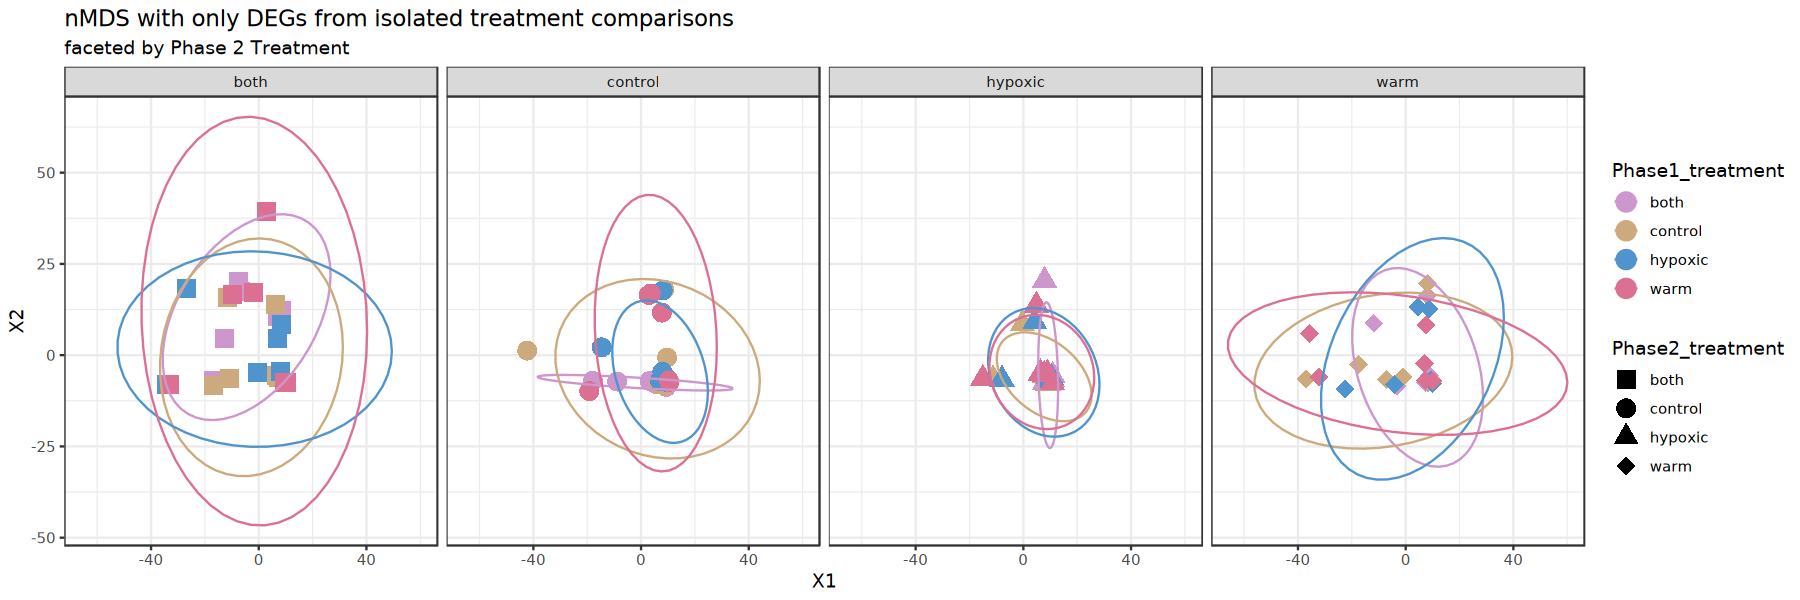

In [49]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 Treatment') + 
theme_bw()

nmds.plot

BC samples (purple circles) - super tight clustering; same with BH samples (purple triangles)

Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


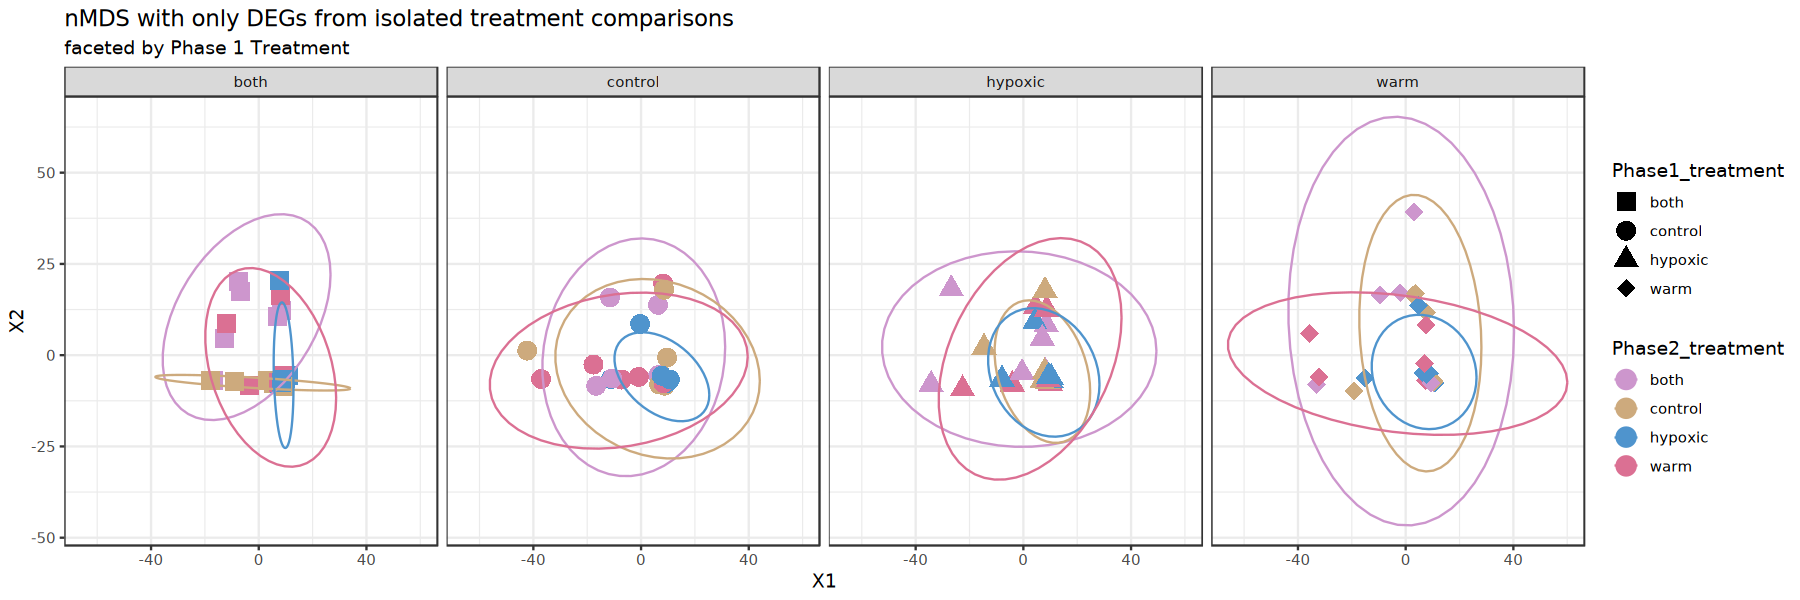

In [58]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, shape = Phase1_treatment, col = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 1 Treatment') + 
theme_bw()

nmds.plot

*coloring and shapes are reversed from above*

- phase 2 hypoxic (blue) seems to have a less dispersed GE profile - tighter circling in all grids
- phase 2 both has more dispersed profile in all grids, less specific response/depends on the early stressor?